# Preamble

In [1]:
import dask
import distributed

print(dask.__version__)
print(distributed.__version__)

2025.5.1
2025.5.1


In [2]:
# Standard library
import logging
import os
import re
import sys
from collections import defaultdict
from collections.abc import Callable
from functools import partial
from glob import glob
from importlib import reload
from itertools import groupby
from pathlib import Path
from pprint import pprint
from collections import defaultdict
from itertools import groupby
import time

# Third-party
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import nc_time_axis  # noqa: F401 - registers cftime units with matplotlib
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from dask.distributed import wait
from dask.utils import format_bytes
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [3]:
# import dask_gateway
# import frisky

In [4]:
# from scipy.stats import gaussian_kde

In [5]:
import sys
sys.path.insert(0, '../extant-functions')

from plotting_modules import core, distributions, figures, constants, timeseries, utils, maps, formatting

In [6]:
import xarray_stats

In [7]:
# sys.path.append('../extant-functions')

# import plotting_modules

# from plotting_modules import core, distributions, figures, constants, timeseries, utils, maps, formatting

In [8]:
# plotting_modules.__path__

In [9]:
# Local
import open_xarray

# import formatting
from xarray_calc import split_time
from draft_current_plotting_functions import (
plot_difference, style_axis, plume_legend, plot_boxes, plot_panel_grid, plot_panel, plot_quantile_seasons, plot_season_stack, draw_panel)
import draft_current_plotting_functions as plotting_functions

from logger import setup_logging

logger = setup_logging(__name__, logging.DEBUG)

In [10]:
import warnings

# Mute the Dask large graph warning
warnings.filterwarnings(
    "ignore", 
    message=".*Sending large graph of size.*", 
    category=UserWarning
)


In [11]:
xr.set_options(display_expand_attrs=False, display_expand_data=False)

In [12]:
import dask_gateway
gw = dask_gateway.Gateway("https://dask-gateway.jasmin.ac.uk", auth="jupyterhub")

16:18:22 ERROR   asyncio | Exception in callback None()
handle: <Handle cancelled>
Traceback (most recent call last):
  File "/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/tornado/iostream.py", line 1363, in _do_ssl_handshake
    self.socket.do_handshake()
  File "/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/ssl.py", line 1319, in do_handshake
    self._sslobj.do_handshake()
ssl.SSLEOFError: [SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1010)

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-

In [13]:
for i,c in enumerate(gw.list_clusters()):
    print(f'{i}, ', end='')
    gw.stop_cluster(c.name)

0, 

In [14]:
for c in gw.list_clusters():
    gw.connect(c.name).shutdown()

In [15]:
options = gw.cluster_options()
options.account = "extant"
options.worker_cores = 1
options.worker_threads = 1
options.scheduler_cores = 1
options.worker_memory = 16
options.qos = 'standard'

In [16]:
options

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/jupyter_client/session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: inf
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


In [17]:
dict(options)

{'account': 'extant',
 'scheduler_cores': 1,
 'scheduler_memory': 16.0,
 'worker_cores': 1,
 'worker_threads': 1,
 'worker_memory': 16.0,
 'worker_setup': 'source /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/bin/activate jaspy3.12-mf3-25.3.0-3-v20250704',
 'qos': 'standard',
 'partition': 'standard'}

In [18]:
# options.worker_setup = "source /home/users/aborow/venvs/hpc/bin/activate"
# options.worker_memory = None

clusters = gw.list_clusters()
if not clusters:
    cluster = gw.new_cluster(options, shutdown_on_close=True)
else:
    cluster = gw.connect(clusters[0].name)

cluster.scale(20)
client = cluster.get_client()
client.wait_for_workers(6)

2026-09-29 16:18:22,167 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [19]:
gw

Gateway<https://dask-gateway.jasmin.ac.uk>

In [20]:
client

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /_jasmin/proxy/dask-gateway/clusters/e05d086bb3664e93b0490ac2a2ce5997/status,


In [21]:
# client.close()

In [22]:
len(cluster.scheduler_info['workers'])

16

In [23]:
# client.close()

In [24]:
ncpus = 40

In [25]:
cluster.scale(ncpus)

In [26]:
len(cluster.scheduler_info['workers'])

16

In [27]:
# from time import sleep, time
# current_length = len(cluster.scheduler_info['workers'])
# current_length

# itial_time = time()
# time_taken_dict = {}
# while current_length < (ncpus-1):
#     checked_length = len(cluster.scheduler_info['workers'])
#     if checked_length != current_length:
#         current_length = checked_length
#         time_now = time()
#         time_taken = time_now - itial_time
#         initial_time = time_now
#         print(f"{current_length=}, {time_taken}")
#         time_taken_dict[current_length] = time_taken
#     sleep(5)

# Constants

In [28]:
client.upload_file('/home/users/aborow/ExtAnt-initial/open_xarray.py')

{'tls://172.26.129.196:34277': {'status': 'OK'},
 'tls://172.26.129.196:36023': {'status': 'OK'},
 'tls://172.26.129.196:37567': {'status': 'OK'},
 'tls://172.26.129.196:38475': {'status': 'OK'},
 'tls://172.26.129.196:38545': {'status': 'OK'},
 'tls://172.26.129.196:38847': {'status': 'OK'},
 'tls://172.26.129.196:39379': {'status': 'OK'},
 'tls://172.26.129.196:39957': {'status': 'OK'},
 'tls://172.26.129.196:41385': {'status': 'OK'},
 'tls://172.26.129.196:41843': {'status': 'OK'},
 'tls://172.26.129.196:42101': {'status': 'OK'},
 'tls://172.26.129.196:42521': {'status': 'OK'},
 'tls://172.26.129.196:42559': {'status': 'OK'},
 'tls://172.26.129.196:44749': {'status': 'OK'},
 'tls://172.26.129.196:45355': {'status': 'OK'},
 'tls://172.26.129.196:46013': {'status': 'OK'}}

In [29]:
main_experiments = ["hist-nat", "hist-aer", "hist-totalO3", "hist-GHG", "historical"]


In [30]:
latlon = dict(lat=-81.88, lon=120.9, method='nearest')

In [31]:
MODEL = 'HadGEM3-GC31-LL'

In [32]:
HISTORICAL = 'historical'
HISTNAT = 'hist-nat'
HIST_AER = 'hist-aer'
HIST_TOTAL03 = 'hist-totalO3'

In [33]:
LEADER_ESPC_PATH = Path("/gws/ssde/j25b/leader_epesc")

In [34]:
AMON_TAS_PATH = (LEADER_ESPC_PATH/ 'CMIP6_SinglForcHistSimul' / 'InterpolatedFlds' / 'Amon' /'tas')
AMON_TAS_PATH

PosixPath('/gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/Amon/tas')

In [35]:
BASE_PATH = Path('/work/scratch-pw4/aborow/LESFMIP/monthly_v2')#

In [36]:
import pandas as pd

In [37]:
pd.read_csv('/gws/ssde/j25b/leader_epesc/catalogs/all-catalog_v1.csv')

,activity_id,branch_method,branch_time_in_child,branch_time_in_parent,experiment,experiment_id,frequency,grid,grid_label,institution_id,...,standard_name,long_name,units,vertical_levels,init_year,start_time,end_time,time_range,path,version
0,DAMIP,standard,0.0,36524.0,historical well-mixed GHG-only run,hist-GHG,mon,native atmosphere N96 grid (145x192 latxlon),gn,CSIRO,...,precipitation_flux,Precipitation,kg m-2 s-1,1,NaN,1850-01-16 12:00:00,2020-12-16 12:00:00,1850-01-16 12:00:00-2020-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0
1,DAMIP,standard,0.0,21915.0,historical well-mixed GHG-only run,hist-GHG,mon,native atmosphere N96 grid (145x192 latxlon),gn,CSIRO,...,precipitation_flux,Precipitation,kg m-2 s-1,1,NaN,1850-01-16 12:00:00,2020-12-16 12:00:00,1850-01-16 12:00:00-2020-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0
2,DAMIP,standard,0.0,29220.0,historical well-mixed GHG-only run,hist-GHG,mon,native atmosphere N96 grid (145x192 latxlon),gn,CSIRO,...,precipitation_flux,Precipitation,kg m-2 s-1,1,NaN,1850-01-16 12:00:00,2020-12-16 12:00:00,1850-01-16 12:00:00-2020-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0
3,DAMIP,standard,0.0,36524.0,historical well-mixed GHG-only run,hist-GHG,mon,native atmosphere N96 grid (145x192 latxlon),gn,CSIRO,...,precipitation_flux,Precipitation,kg m-2 s-1,1,NaN,1850-01-16 12:00:00,2020-12-16 12:00:00,1850-01-16 12:00:00-2020-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0
4,DAMIP,standard,0.0,36524.0,historical well-mixed GHG-only run,hist-GHG,mon,native atmosphere N96 grid (145x192 latxlon),gn,CSIRO,...,precipitation_flux,Precipitation,kg m-2 s-1,1,NaN,1850-01-16 12:00:00,2020-12-16 12:00:00,1850-01-16 12:00:00-2020-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17478,CMIP,standard,0.0,65744.0,all-forcing simulation of the recent past,historical,mon,native atmosphere T85 Gaussian grid,gn,MIROC,...,geopotential_height,Geopotential Height,m,19,NaN,1850-01-16 12:00:00,2014-12-16 12:00:00,1850-01-16 12:00:00-2014-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0
17479,CMIP,Hybrid-restart from year 1600-01-01 of piControl,0.0,430335.0,all-forcing simulation of the recent past,historical,mon,finite-volume grid with 1.9x2.5 degree lat/lon...,gn,NCC,...,geopotential_height,Geopotential Height,m,19,NaN,1850-01-16 12:00:00,2014-12-16 12:00:00,1850-01-16 12:00:00-2014-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0
17480,CMIP,Hybrid-restart from year 1600-01-01 of piControl,0.0,430335.0,all-forcing simulation of the recent past,historical,mon,finite-volume grid with 1.9x2.5 degree lat/lon...,gn,NCC,...,geopotential_height,Geopotential Height,m,19,NaN,1850-01-16 12:00:00,2014-12-16 12:00:00,1850-01-16 12:00:00-2014-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0
17481,CMIP,Hybrid-restart from year 1631-01-01 of piControl,0.0,441650.0,all-forcing simulation of the recent past,historical,mon,finite-volume grid with 1.9x2.5 degree lat/lon...,gn,NCC,...,geopotential_height,Geopotential Height,m,19,NaN,1850-01-16 12:00:00,2014-12-16 12:00:00,1850-01-16 12:00:00-2014-12-16 12:00:00,/gws/nopw/j04/leader_epesc/CMIP6_SinglForcHist...,v0


# Processing Data

## ERA5 - Seasonal

In [35]:
OUT_PATH =  Path("/work/scratch-pw4/aborow")

In [36]:
ERA5_ROOT = "/badc/ecmwf-era5/data/oper/an_sfc"
ZARR_OUT = OUT_PATH / "era5_t2m_seasonal.zarr"

In [37]:
YEARS = range(1979, 2025)

In [49]:
TMP_DIR = OUT_PATH / "monthly_tmp_v2"
os.makedirs(TMP_DIR, exist_ok=True)

In [46]:
done = {int(p.split("_")[-1].removesuffix(".zarr")) for p in glob(f"{TMP_DIR}/tas_*.zarr")}

if os.path.exists(ZARR_OUT):
    done |= set(xr.open_zarr(ZARR_OUT).time.dt.year.values.tolist())

YEARS = np.array([y for y in YEARS if y not in done])
YEARS

array([1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [47]:
# if os.path.exists(ZARR_OUT):
#     YEARS = range(int(xr.open_zarr(ZARR_OUT).time.dt.year.max()) + 1, YEARS.stop)

# YEARS

In [48]:
import calendar
import os
import shutil
from glob import glob

In [41]:
len(cluster.scheduler_info['workers'])

20

In [42]:
lesfmip_sample_ds = (
    xr.open_zarr("/work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-lu_interp_monthly.zarr")
    .isel(time=0, member=0)
)

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [43]:
lesfmip_sample_ds

<xarray.Dataset> Size: 13kB
Dimensions:  (lon: 144, lat: 20)
Coordinates:
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
    time     object 8B 1850-01-16 00:00:00
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    member   <U9 36B 'r10i1p1f3'
    height   float64 8B ...
Data variables:
    tas      (lat, lon) float32 12kB dask.array<chunksize=(10, 144), meta=np.ndarray>

In [44]:
import cf_xarray  # noqa: F401
import xesmf as xe


def preprocess(d):
    return d.sortby("latitude").sel(latitude=slice(-90.0, -38.0))


# Build the regridder once from a single ERA5 file
first = preprocess(xr.open_dataset(sorted(glob(f"{ERA5_ROOT}/{YEARS[0]}/*/*/*.2t.nc"))[0]))
src_grid = first[["latitude", "longitude"]].rename({"latitude": "lat", "longitude": "lon"})
src_grid = src_grid.cf.add_bounds(["lat", "lon"])
src_grid["lat_bounds"] = src_grid["lat_bounds"].clip(-90.0, 90.0)

dst_grid = lesfmip_sample_ds[["lat", "lon"]].cf.add_bounds(["lat", "lon"])

regridder = xe.Regridder(src_grid, dst_grid, "conservative", periodic=True)


In [50]:
def month_mean(paths):
    total, n = None, 0
    for p in paths:
        with xr.open_dataset(p) as d:
            arr = preprocess(d)["t2m"].values
        s = arr.sum(axis=0, dtype="float64")
        total = s if total is None else total + s
        n += arr.shape[0]
    return (total / n).astype("float32")


lat = first["latitude"].values
lon = first["longitude"].values

# Submit every remaining month to the cluster
futures = {}
for year in YEARS:
    if os.path.exists(f"{TMP_DIR}/tas_{year}.zarr"):
        continue
    for month in range(1, 13):
        paths = sorted(glob(f"{ERA5_ROOT}/{year}/{month:02d}/*/*.2t.nc"))
        futures[(year, month)] = client.submit(month_mean, paths, pure=False)

# 1. One Zarr store per year, as results arrive
for year in sorted({y for y, _ in futures}):
    print(year, flush=True)
    out = f"{TMP_DIR}/tas_{year}.zarr"

    arrays = client.gather([futures[(year, m)] for m in range(1, 13)])
    tas = xr.DataArray(
        np.stack(arrays),
        dims=("time", "lat", "lon"),
        coords={
            "time": pd.date_range(f"{year}-01-01", periods=12, freq="MS"),
            "lat": lat,
            "lon": lon,
        },
    )
    tas = regridder(tas).astype("float32").rename("tas")
    tas.encoding = {}

    tmp = out + ".part"
    shutil.rmtree(tmp, ignore_errors=True)  # clear any half-written attempt
    tas.to_dataset().to_zarr(tmp, mode="w")
    os.replace(tmp, out)  # atomic: a store only gets its final name when complete

1985


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1986


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1987


...

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


2023


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


2024


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [52]:
year_stores = sorted(glob(f"{TMP_DIR}/tas_*.zarr"))

new = xr.concat([xr.open_zarr(p)["tas"] for p in year_stores], dim="time")

if os.path.exists(ZARR_OUT):
    existing = xr.open_zarr(ZARR_OUT)["tas"]
    new = xr.concat([existing, new], dim="time")

monthly = new.sortby("time").load()
monthly.encoding = {}

chunks = {"time": -1, "lat": -1, "lon": -1}
tmp = ZARR_OUT.with_name(ZARR_OUT.name + ".part")
shutil.rmtree(tmp, ignore_errors=True)
monthly.to_dataset().chunk(chunks).to_zarr(tmp, mode="w")

# Verify, then swap in and delete the per-year stores
check = xr.open_zarr(tmp)["tas"]
assert check.indexes["time"].is_unique, "duplicate months"
assert check.indexes["time"].is_monotonic_increasing, "time not sorted"
assert np.allclose(check.values, monthly.values, equal_nan=True), "data mismatch"

shutil.rmtree(ZARR_OUT, ignore_errors=True)
os.replace(tmp, ZARR_OUT)

for p in year_stores:
    shutil.rmtree(p)
print(f"wrote {ZARR_OUT}: {monthly.sizes}, removed {len(year_stores)} yearly stores", flush=True)

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


wrote /work/scratch-pw4/aborow/era5_t2m_seasonal.zarr: Frozen({'time': 552, 'lat': 20, 'lon': 144}), removed 46 yearly stores


In [ ]:

# # 1. One Zarr store per year
# for year in YEARS:
#     print(year)
#     out = f"{TMP_DIR}/tas_{year}.zarr"
#     if os.path.exists(out):
#         continue  # restartable

#     paths = sorted(glob(f"{ERA5_ROOT}/{year}/*/*/*.2t.nc"))

#     print(f"{year=}, total files {len(paths)}", flush=True)

#     tas = (
#         xr.open_mfdataset(
#             paths,
#             combine="nested",
#             concat_dim="time",
#             parallel=True,
#             data_vars="minimal",
#             coords="minimal",
#             compat="override",
#             preprocess=preprocess,
#         )["t2m"]
#         .resample(time="1MS")
#         .mean()
#         .load()
#         .rename({"latitude": "lat", "longitude": "lon"})
#     )
#     tas = regridder(tas, keep_attrs=True).astype("float32").rename("tas")
#     tas.encoding = {}

#     tmp = out + ".part"
#     shutil.rmtree(tmp, ignore_errors=True)  # clear any half-written attempt
#     tas.to_dataset().to_zarr(tmp, mode="w")
#     os.replace(tmp, out)  # atomic: a store only gets its final name when complete

1979
year=1979, total files 8760


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1980
year=1980, total files 8784


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1981
year=1981, total files 8760


In [55]:
tas

<xarray.DataArray 'tas' (time: 12, latitude: 121, longitude: 1440)> Size: 8MB
242.7 242.7 242.7 242.7 242.7 242.7 ... 272.1 272.1 272.1 272.1 272.1 272.1
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 484B -90.0 -89.75 -89.5 ... -60.5 -60.25 -60.0
  * time       (time) datetime64[ns] 96B 1979-01-01 1979-02-01 ... 1979-12-01
Attributes: (2)

In [59]:
    tas = (
        xr.open_mfdataset(
            paths,
            combine="nested",
            concat_dim="time",
            parallel=True,
            data_vars="minimal",
            coords="minimal",
            compat="override",
            preprocess=preprocess,
        )["t2m"]
        .resample(time="1MS")
        .mean()
        .astype("float32")
        .rename("tas")
        # .load()
    )

In [60]:
tas

<xarray.DataArray 'tas' (time: 12, latitude: 121, longitude: 1440)> Size: 8MB
dask.array<chunksize=(1, 121, 1440), meta=np.ndarray>
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 484B -90.0 -89.75 -89.5 ... -60.5 -60.25 -60.0
  * time       (time) datetime64[ns] 96B 1979-01-01 1979-02-01 ... 1979-12-01
Attributes: (2)

In [ ]:
# for year in YEARS:
#     paths = sorted(glob(f"{ERA5_ROOT}/{year}/*/*/*.2t.nc"))
#     print(f"{year=}, total files {len(paths)}")

#     ds = (
#         xr.open_mfdataset(
#             paths,
#             combine="nested",
#             concat_dim="time",
#             parallel=True,
#             data_vars="minimal",
#             coords="minimal",
#             compat="override",
#             preprocess=lambda d: d.sortby("latitude").sel(latitude=slice(-90.0, -60.0)),
#         )["t2m"]
#         .resample(time="1MS")
#         .mean()
#         .rename("tas")
#         .to_dataset()
#     )
#     ds["tas"] = ds["tas"].astype("float32")
#     ds["tas"].encoding = {}
#     ds = ds.load()

#     if os.path.exists(MONTHLY_OUT):
#         ds.to_zarr(MONTHLY_OUT, append_dim="time", align_chunks=True)
#     else:
#         chunks = (12, ds.sizes["latitude"], ds.sizes["longitude"])
#         ds.to_zarr(MONTHLY_OUT, mode="w", encoding={"tas": {"chunks": chunks}})
#     print(year, flush=True)

## LESFMIP

In [71]:
from dask.utils import format_bytes

In [72]:
list(map(lambda x: x.name, list(AMON_TAS_PATH.iterdir())))

['hist-GHG',
 'hist-aer',
 'hist-lu',
 'hist-nat',
 'hist-sol',
 'hist-totalO3',
 'hist-volc',
 'historical',
 'reanalysis',
 'compress.bash',
 'nhsum',
 'process.bash']

In [73]:
models = np.array(list(map(lambda x: x.name, list((AMON_TAS_PATH / HISTORICAL).iterdir()))))
models

array(['ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CESM2', 'CMCC-CM2-SR5',
       'CNRM-CM6-1', 'CanESM5', 'E3SM-2-0', 'FGOALS-g3', 'GISS-E2-1-G',
       'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-LR',
       'MRI-ESM2-0', 'NorESM2-LM', 'CESM2-LENS', 'E3SM-2-1'], dtype='<U15')

In [74]:
MEMBER_RES = (
    re.compile(r'(?:^|[_/])(r\d+i\d+p\d+(?:f\d+)?)(?=[_./]|$)'),  # DRS:    r1i1p1f1
    re.compile(r'(?:^|[_/])(\d{4}\.\d{3})(?=[_.]|$)'),            # LENS2:  1001.001
    re.compile(r'(?:^|[_/])(\d{2,3})(?=[_.]|$)'),                 # SFLE:   009
)


def _member_from_path(source):
    """Extract the variant label from a CMIP filename, falling back to the DRS path."""
    path = Path(source)
    for pattern in MEMBER_RES:
        for part in (path.name, *reversed(path.parts[:-1])):
            match = pattern.search(part)
            if match:
                return match.group(1)
    raise ValueError(f'no variant label found in {source}')
    

def _preprocess_tas(da, variable='tas'):
    source = da.encoding.get('source')
    if source is None:
        raise ValueError('dataset has no source encoding; cannot infer member')
    da = da.squeeze().assign_coords(member=_member_from_path(source))
    da = da[variable]
    if 'lon_2' in da.coords:
        da = da.rename({'lon_2': 'lon'})
    return da.sel(lat=slice(-90, -40))

In [75]:
def open_and_save(group_paths, out_name):
    month_ds = open_xarray.open_members(group_paths, preprocess=_preprocess_tas, **open_kwargs)

    
    month_ds = month_ds.chunk({'time': -1, 'lat': month_ds.sizes['lat'] // 2, 'lon': -1, 'member': 5})

    print(f'{dict(month_ds.sizes)}  '
          f'{format_bytes(month_ds.nbytes)}', flush=True)

    
    t0 = time.time()
    print(f'Saving to {out_name}')
    month_ds.to_zarr(out_name, mode='w', consolidated=True)
    print('\n')

In [76]:
def retrive_monthly_zarrs(model_dir, model, experiment, variable='tas', OVERWRITE:bool=False, open_kwargs=None):

    if not open_kwargs: open_kwargs = {}
    
    failed = {}
    
    paths = list(model_dir.rglob('*.nc'))
    # key = lambda p: p.name.split('.')[0].split('_')[-1]
    key = lambda p: p.name.removesuffix('.nc').split('_')[-1]
    grouped = {g: list(v) for g, v in groupby(sorted(paths, key=key), key=key)}
    logger.debug(grouped)

    print(f'  {model}: {len(paths)} files  '
          + '  '.join(f'{g}={len(v)}' for g, v in grouped.items()), flush=True)
    
    for group, group_paths in grouped.items():
        
        print(f'  [{experiment}/{group}] opening {len(group_paths)} files...', flush=True)
        
        out_name = BASE_PATH / f'{model}_{variable}_{experiment}_{group}_monthly.zarr'

        if not OVERWRITE and out_name.exists():
            print(f'File {out_name} already exists and {OVERWRITE=}', flush=True)
            print('\n')
            continue

        try: open_and_save(group_paths, out_name)
            
        except (ValueError, KeyError) as e:
            failed[group] = {'error': e, 'paths': group_paths, 'out_name': out_name}
    return failed

In [77]:
simulation_protocals = np.array([p.name for p in list(AMON_TAS_PATH.iterdir()) if p.is_dir()])

# Filter out 'nhsum' and 'reanlysis'
simulation_protocals = simulation_protocals[~np.isin(simulation_protocals, ['nhsum', 'reanalysis'])]
simulation_protocals

array(['hist-GHG', 'hist-aer', 'hist-lu', 'hist-nat', 'hist-sol',
       'hist-totalO3', 'hist-volc', 'historical'], dtype='<U12')

In [78]:
simulation_protocals = main_experiments

In [79]:
availble_per_simulation = {str(protocal): [sim.name for sim in list((AMON_TAS_PATH/ protocal).iterdir())] for protocal in simulation_protocals}
pprint(availble_per_simulation)

{'hist-GHG': ['ACCESS-ESM1-5',
              'BCC-CSM2-MR',
              'CESM2',
              'CESM2_SFLE',
              'CMCC-CM2-SR5',
              'CNRM-CM6-1',
              'CanESM5',
              'E3SM-2-0',
              'FGOALS-g3',
              'GISS-E2-1-G',
              'HadGEM3-GC31-LL',
              'IPSL-CM6A-LR',
              'MIROC6',
              'MPI-ESM1-2-LR',
              'MRI-ESM2-0',
              'NorESM2-LM',
              'E3SM-2-1'],
 'hist-aer': ['ACCESS-ESM1-5',
              'BCC-CSM2-MR',
              'CESM2',
              'CMCC-CM2-SR5',
              'CNRM-CM6-1',
              'CanESM5',
              'E3SM-2-0',
              'FGOALS-g3',
              'GISS-E2-1-G',
              'HadGEM3-GC31-LL',
              'IPSL-CM6A-LR',
              'MIROC6',
              'MPI-ESM1-2-LR',
              'MRI-ESM2-0',
              'NorESM2-LM',
              'E3SM-2-1'],
 'hist-nat': ['ACCESS-ESM1-5',
              'BCC-CSM2-MR',
              

In [80]:
# Melt dictionary into long format and pivot into a Boolean matrix
df_models = (
    pd.Series(availble_per_simulation)
    .explode()
    .rename_axis('protocol')
    .reset_index(name='model')
    .pipe(lambda d: pd.crosstab(d['model'], d['protocol']))
    .astype(bool)
)

df_models['total_per_model'] = df_models.sum(axis=1)
df_models.loc['total_per_protocal'] = df_models.sum(axis=0)

df_models = df_models.sort_values('total_per_model', ascending=False)

df_models

protocol,hist-GHG,hist-aer,hist-nat,hist-totalO3,historical,total_per_model
model,,,,,,
total_per_protocal,17,16,14,7,17,71
CanESM5,1,1,1,1,1,5
MPI-ESM1-2-LR,1,1,1,1,1,5
HadGEM3-GC31-LL,1,1,1,1,1,5
NorESM2-LM,1,1,1,1,1,5
GISS-E2-1-G,1,1,1,1,1,5
MIROC6,1,1,1,1,1,5
CESM2,1,1,1,0,1,4
BCC-CSM2-MR,1,1,1,0,1,4


In [81]:
good_models = df_models.loc[df_models.total_per_model >= 4].index.values
good_models = good_models[~np.isin(good_models, ['total_per_protocal'])]

protocals = df_models.columns
protocals = protocals[protocals != 'total_per_model']

good_models, protocals

(array(['CanESM5', 'MPI-ESM1-2-LR', 'HadGEM3-GC31-LL', 'NorESM2-LM',
        'GISS-E2-1-G', 'MIROC6', 'CESM2', 'BCC-CSM2-MR', 'ACCESS-ESM1-5',
        'CNRM-CM6-1', 'E3SM-2-1', 'E3SM-2-0', 'IPSL-CM6A-LR', 'FGOALS-g3',
        'MRI-ESM2-0'], dtype=object),
 Index(['hist-GHG', 'hist-aer', 'hist-nat', 'hist-totalO3', 'historical'], dtype='object', name='protocol'))

In [82]:
BASE_PATH.mkdir(parents=True, exist_ok=True)
list(BASE_PATH.iterdir())[:3]

[PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-lu_interp_monthly.zarr')]

In [83]:
open_kwargs = open_xarray.OPEN_KWARGS_LESFMIP_DERIVED
# open_kwargs['join'] = 'inner'

In [84]:
protocals = ['historical']
good_models = ['GISS-E2-1-G']

In [85]:
logger.setLevel('INFO')

In [86]:

list(BASE_PATH.iterdir())

[PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MIROC6_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/ACCESS-ESM1-5_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MRI-ESM2-0_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/BCC-CSM2-MR_tas_hist-lu_interp_monthly.zarr'),
 PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CMCC-CM2-SR5_tas_his

In [87]:
#(t): Opening and saving monthly models (tas)
#(c): Opening all the models, saving and recording errors
errors = {}
for experiment in protocals:
    print(f'{experiment}\n\n', flush=True)
    for model in good_models:
        errors[f'{experiment}_{model}'] = retrive_monthly_zarrs(
            Path(AMON_TAS_PATH, experiment, model),
            model=model, experiment=experiment, open_kwargs=open_kwargs,
        OVERWRITE=True)

errors = {k: v for k, v in errors.items() if v}

historical


  GISS-E2-1-G: 80 files  extend=15  interp=65
  [historical/extend] opening 15 files...
{'member': 15, 'time': 72, 'lat': 20, 'lon': 144}  11.87 MiB
Saving to /work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_historical_extend_monthly.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `<U9` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by



  [historical/interp] opening 65 files...


In [88]:
# Pop values at position 55 - skips time
len(errors['historical_GISS-E2-1-G']['interp']['paths']), errors['historical_GISS-E2-1-G']['interp']['paths'].pop(55), len(errors['historical_GISS-E2-1-G']['interp']['paths'])

(65,
 PosixPath('/gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/Amon/tas/historical/GISS-E2-1-G/tas_mon_historical_GISS-E2-1-G_r7i1p3f1_interp.nc'),
 64)

In [89]:
# Pop values at position 55 - shoter

len(errors['historical_GISS-E2-1-G']['interp']['paths']), errors['historical_GISS-E2-1-G']['interp']['paths'].pop(25), len(errors['historical_GISS-E2-1-G']['interp']['paths'])

(64,
 PosixPath('/gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/Amon/tas/historical/GISS-E2-1-G/tas_mon_historical_GISS-E2-1-G_r1i1p1f5_interp.nc'),
 63)

In [90]:
# (t) Special case: 'historical_GISS-E2-1-G' - ensemble member 55 is broken (time is missing)
open_and_save(errors['historical_GISS-E2-1-G']['interp']['paths'],  errors['historical_GISS-E2-1-G']['interp']['out_name'])

{'member': 63, 'time': 1980, 'lat': 20, 'lon': 144}  1.34 GiB
Saving to /work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_historical_interp_monthly.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `<U9` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by

In [ ]:
# ds_stor = []
# for path in errors['historical_GISS-E2-1-G']['interp']['paths']: ds_stor.append(xr.open_dataset(path))
# plt.plot(ds_stor[55].time.values)

In [ ]:
# np.array(list(map(lambda x: (x[0], x[1].sizes['time']), enumerate(ds_stor))))

In [ ]:
# fig = plt.figure(figsize=(12, 20))
# for i, ds in enumerate(ds_stor):
#     ax = fig.add_subplot(int(np.ceil(len(ds_stor)//4))+1, 4, i+1)
#     ax.plot(ds.time.values, label='i')
#     ax.set_title(f'{i}')

In [ ]:
errors

In [ ]:
test_path = '/work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_historical_interp_monthly.zarr'
# test_path = '/gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/Amon/tas/historical/GISS-E2-1-G/tas_mon_historical_GISS-E2-1-G_r9i1p5f1_interp.nc'
ds = xr.open_dataset(test_path)

In [ ]:
ds

In [ ]:
pprint(errors.values())

In [ ]:
unique_errors = []
for key, val in errors.items():
    for group in val.values():
        unique_errors.append({key:group['error']})

# Opening Data

## ERA5

In [56]:
era5_ds = xr.open_dataarray('/work/scratch-pw4/aborow/era5_t2m_seasonal.zarr')

In [63]:
era5_ds = era5_ds -273.15

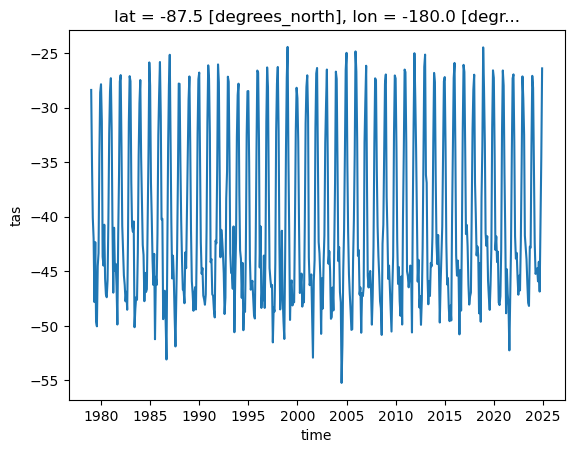

In [70]:
era5_ds.isel(lat=0, lon=0).plot()

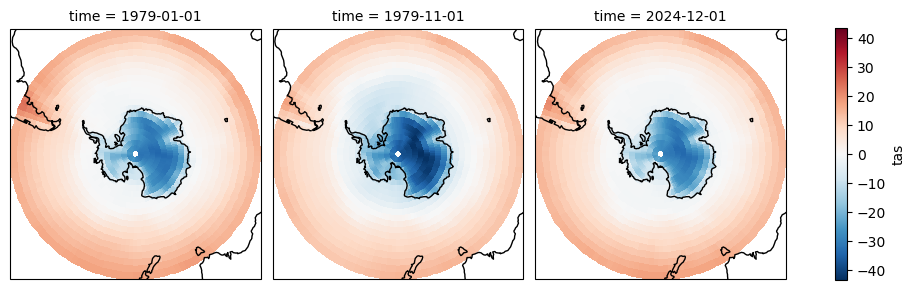

In [68]:
g = era5_ds.isel(time=[0, 10, -1]).plot(
    col='time',
    subplot_kws=dict(projection=ccrs.SouthPolarStereo()), transform=ccrs.PlateCarree())

for ax in g.axs.flat:
    ax.coastlines()

## LESFMIP

In [38]:
import xarray_datatree_utils
import functools
from xarray import DataTree

In [39]:
def parse_store(store):
    model, variable, experiment, group = store.stem.rsplit('_', 4)[:4]
    return {'model': model, 'variable': variable, 'experiment': experiment,
            'group': group, 'path': store}

    
def summary_df(base_path=BASE_PATH):
    rows = [parse_store(s) for s in sorted(base_path.glob('*_monthly.zarr'))]
    df = pd.DataFrame(rows).drop(columns='path')
    df = df.pivot_table(index='model', columns='experiment',
                          values='group', aggfunc='size', fill_value=0).astype(bool).astype(int)

    # df['total_per_model'] = df.sum(axis=1)
    # df.loc['total_per_protocal'] = df.sum(axis=0)
    
    # df = df.sort_values('total_per_model', ascending=False)

    return df

In [40]:
def build_tree(models=None, experiments=None, groups=None,
               levels=('experiment', 'model'), base_path=BASE_PATH):
    """Open matching zarr stores as a DataTree. None means 'all'.

    Args:
        levels (tuple[str, ...]): Entry keys giving tree depth, outermost first.
    """
    entries = [parse_store(s) for s in sorted(base_path.glob('*_monthly.zarr'))]
    if models is not None:
        entries = [e for e in entries if e['model'] in models]
    if experiments is not None:
        entries = [e for e in entries if e['experiment'] in experiments]
    if groups is not None:
        entries = [e for e in entries if e['group'] in groups]
    if not entries:
        raise ValueError(f'no stores matched {models=} {experiments=} {groups=}')

    nodes = {}
    for e in entries:
        path = '/'.join(e[k] for k in levels)
        if path in nodes:
            raise ValueError(f'duplicate tree path {path!r} from {e["path"].name}')
        logger.debug(f' - {e}: {e['path']}')
        nodes[path] = xr.open_zarr(e['path'], consolidated=True)
    return xr.DataTree.from_dict(nodes)

In [41]:
def map_to_dict(tree, func, multi_index=False):
    """Apply a function to each populated node, collecting non-tree output.

    Args:
        tree (DataTree): Tree to traverse.
        func (callable): Function taking a Dataset.
        multi_index (bool): Return tuple keys (path split on "/") instead
            of the raw path string, for direct use as a pandas MultiIndex.

    Returns:
        dict: Node path (str or tuple) mapped to the function's return value.
    """
    if multi_index:
        return {
            tuple(path.strip("/").split("/")): func(node.dataset)
            for path, node in tree.subtree_with_keys
            if node.has_data
        }
    return {path: func(node.dataset) for path, node in tree.subtree_with_keys if node.has_data}

In [42]:
df_models_returned = summary_df()

In [43]:
df_models_returned.sum(axis=0)

experiment
hist-GHG        15
hist-aer        15
hist-lu         15
hist-nat        14
hist-sol         8
hist-totalO3     6
hist-volc        9
historical      15
dtype: int64

In [44]:
df_models_returned.sum(axis=1).T

model
ACCESS-ESM1-5      7
BCC-CSM2-MR        5
CESM2              5
CMCC-CM2-SR5       5
CNRM-CM6-1         5
CanESM5            8
E3SM-2-0           5
FGOALS-g3          5
GISS-E2-1-G        8
HadGEM3-GC31-LL    8
IPSL-CM6A-LR       5
MIROC6             8
MPI-ESM1-2-LR      8
MRI-ESM2-0         7
NorESM2-LM         8
dtype: int64

In [45]:
df_models_returned

experiment,hist-GHG,hist-aer,hist-lu,hist-nat,hist-sol,hist-totalO3,hist-volc,historical
model,,,,,,,,
ACCESS-ESM1-5,1,1,1,1,1,0,1,1
BCC-CSM2-MR,1,1,1,1,0,0,0,1
CESM2,1,1,1,1,0,0,0,1
CMCC-CM2-SR5,1,1,1,0,0,0,1,1
CNRM-CM6-1,1,1,1,1,0,0,0,1
CanESM5,1,1,1,1,1,1,1,1
E3SM-2-0,1,1,1,1,0,0,0,1
FGOALS-g3,1,1,1,1,0,0,0,1
GISS-E2-1-G,1,1,1,1,1,1,1,1


In [46]:
df_models_returned.sort_values(by='hist-totalO3', ascending=False)

experiment,hist-GHG,hist-aer,hist-lu,hist-nat,hist-sol,hist-totalO3,hist-volc,historical
model,,,,,,,,
CanESM5,1,1,1,1,1,1,1,1
HadGEM3-GC31-LL,1,1,1,1,1,1,1,1
NorESM2-LM,1,1,1,1,1,1,1,1
MIROC6,1,1,1,1,1,1,1,1
MPI-ESM1-2-LR,1,1,1,1,1,1,1,1
GISS-E2-1-G,1,1,1,1,1,1,1,1
BCC-CSM2-MR,1,1,1,1,0,0,0,1
E3SM-2-0,1,1,1,1,0,0,0,1
CNRM-CM6-1,1,1,1,1,0,0,0,1


In [47]:
model_scenario_counts = df_models_returned.sum(axis=1).sort_values(ascending=False)
most_scenarios = model_scenario_counts[:6].index.values
most_scenarios

array(['CanESM5', 'HadGEM3-GC31-LL', 'NorESM2-LM', 'MIROC6',
       'MPI-ESM1-2-LR', 'GISS-E2-1-G'], dtype=object)

In [48]:
logger.setLevel('DEBUG')

In [49]:
main_experiments = ["hist-nat", "hist-aer", "hist-totalO3", "hist-GHG", "historical"]

In [50]:
# lesfmip_tree = build_tree(models=most_scenarios, groups=['interp'], levels=('experiment', 'model'))#
lesfmip_tree = build_tree(models=most_scenarios, experiments=main_experiments, groups=['interp'], levels=('model', 'experiment'))

# dt = build_tree(experiments=['hist-GHG'])
# lesfmip_tree = build_tree(models=most_scenarios)#, experiments=['hist-GHG', 'hist-lu'])

16:15:15 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'experiment': 'hist-GHG', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-GHG_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-GHG_interp_monthly.zarr
16:15:20 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'experiment': 'hist-aer', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-aer_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-aer_interp_monthly.zarr
16:15:20 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'experiment': 'hist-nat', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-nat_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-nat_interp_monthly.zarr
16:15:20 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'e

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

16:15:21 DEBUG   __main__ |  - {'model': 'GISS-E2-1-G', 'variable': 'tas', 'experiment': 'historical', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_historical_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_historical_interp_monthly.zarr
16:15:21 DEBUG   __main__ |  - {'model': 'HadGEM3-GC31-LL', 'variable': 'tas', 'experiment': 'hist-GHG', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-GHG_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-GHG_interp_monthly.zarr
16:15:21 DEBUG   __main__ |  - {'model': 'HadGEM3-GC31-LL', 'variable': 'tas', 'experiment': 'hist-aer', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-aer_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-aer_interp_monthly.zarr
16:15:2

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

16:15:21 DEBUG   __main__ |  - {'model': 'MIROC6', 'variable': 'tas', 'experiment': 'historical', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MIROC6_tas_historical_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MIROC6_tas_historical_interp_monthly.zarr
16:15:21 DEBUG   __main__ |  - {'model': 'MPI-ESM1-2-LR', 'variable': 'tas', 'experiment': 'hist-GHG', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-GHG_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-GHG_interp_monthly.zarr
16:15:21 DEBUG   __main__ |  - {'model': 'MPI-ESM1-2-LR', 'variable': 'tas', 'experiment': 'hist-aer', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-aer_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-aer_interp_monthly.zarr
16:15:21 DEBUG   __main__ |  - {'m

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

16:15:21 DEBUG   __main__ |  - {'model': 'NorESM2-LM', 'variable': 'tas', 'experiment': 'historical', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_historical_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_historical_interp_monthly.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


<Axes: >

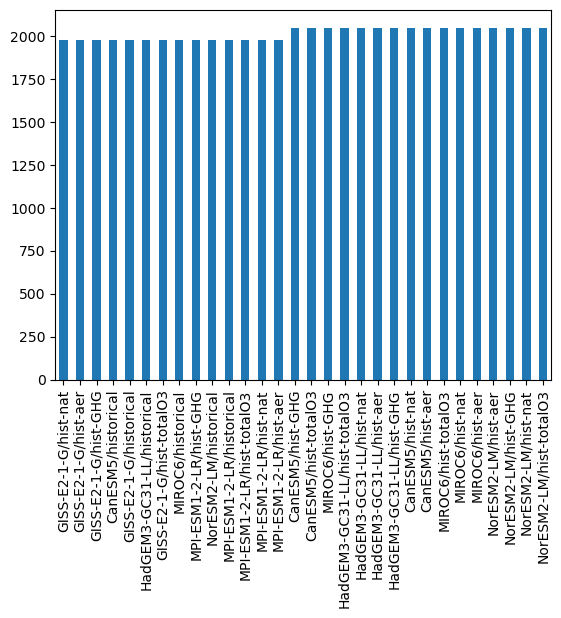

In [51]:
pd.Series(map_to_dict(lesfmip_tree, lambda ds: ds.tas.sizes['time'])).sort_values().plot.bar()

In [52]:
lesfmip_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (lon: 144, member: 50, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (lon: 144, member: 30, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 709MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (lon: 144, member: 50, lat: 20, time: 2052)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (time: 2052, lat: 20, member: 10, lon: 144)
│   │       Coordinates:
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B ...
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 236MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (member: 65, time: 1980, lat: 20, lon: 144)
│           Coordinates:
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B ...
│           Data variables:
│               tas      (member, time, lat, lon) float64 3GB dask.array<chunksize=(5, 1980, 10, 144), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (member: 45, time: 1980, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * member   (member) object 360B 'r10i1p1f2' 'r10i1p3f1' ... 'r9i1p3f1'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │      

In [53]:
# xr.DataTree.from_dict(dict(zip(list(lesfmip_tree), list(map(lambda leaf: leaf['historical'], lesfmip_tree.values())))))

In [54]:
opened_models = (pd.Series({a: [b for b in lesfmip_tree[a]] for a in lesfmip_tree})
    .explode()
    .rename_axis('protocal')
    .reset_index(name='model')
    .pipe(lambda d: pd.crosstab(d['model'], d['protocal']))).T

opened_models

model,hist-GHG,hist-aer,hist-nat,hist-totalO3,historical
protocal,,,,,
CanESM5,1,1,1,1,1
GISS-E2-1-G,1,1,1,1,1
HadGEM3-GC31-LL,1,1,1,1,1
MIROC6,1,1,1,1,1
MPI-ESM1-2-LR,1,1,1,1,1
NorESM2-LM,1,1,1,1,1


## Comparing

<xarray.DataTree 'historical'>
Group: /
    Dimensions:  (member: 65, time: 1980)
    Coordinates:
        lon      float64 8B -180.0
      * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
      * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
        lat      float64 8B -87.5
        height   float64 8B ...
    Data variables:
        tas      (member, time) float64 1MB dask.array<chunksize=(5, 1980), meta=np.ndarray>

In [120]:
era5_ds

<xarray.DataArray 'tas' (time: 552, lat: 20, lon: 144)> Size: 6MB
-28.38 -28.22 -27.94 -27.49 -26.93 -26.36 ... 17.34 17.34 16.86 16.19 18.07
Coordinates:
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2024-12-01
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5

In [125]:
lesfmip_tree['CanESM5']['historical'].tas.isel(lat=0, lon=0, member=0).sel(time=slice('1979', '2014'))

<xarray.DataArray 'tas' (time: 432)> Size: 3kB
dask.array<chunksize=(432,), meta=np.ndarray>
Coordinates:
    lon      float64 8B -180.0
  * time     (time) object 3kB 1979-01-16 12:00:00 ... 2014-12-16 12:00:00
    member   <U9 36B 'r10i1p1f1'
    lat      float64 8B -87.5
    height   float64 8B ...
Attributes: (8)

In [137]:
era5_ds.isel(lat=0, lon=0).sel(time=slice('1979', '2014'))

<xarray.DataArray 'tas' (time: 432)> Size: 2kB
-28.38 -35.36 -40.07 -42.01 -47.82 -42.33 ... -46.14 -43.51 -40.9 -34.21 -27.59
Coordinates:
    lat      float64 8B -87.5
  * time     (time) datetime64[ns] 3kB 1979-01-01 1979-02-01 ... 2014-12-01
    lon      float64 8B -180.0

<xarray.DataArray 'tas' (time: 432)> Size: 3kB
dask.array<chunksize=(432,), meta=np.ndarray>
Coordinates:
    lon      float64 8B -180.0
  * time     (time) object 3kB 1979-01-16 12:00:00 ... 2014-12-16 12:00:00
    member   <U9 36B 'r10i1p1f1'
    lat      float64 8B -87.5
    height   float64 8B ...
Attributes: (8)

In [142]:
mlength = lesfmip_tree['CanESM5']['historical'].tas.sizes['member']

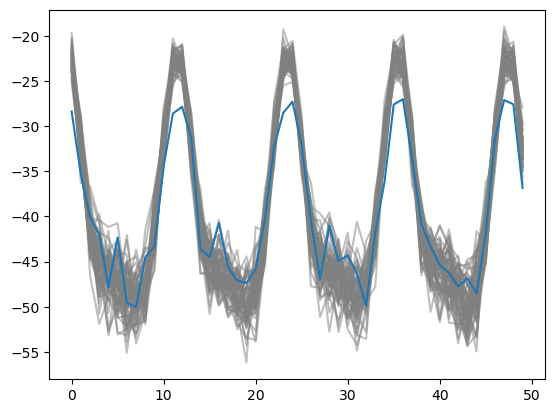

In [144]:
for i in range(mlength):
    vals = (
        lesfmip_tree['CanESM5']['historical'].tas
            .isel(--------------lat=0, lon=0, member=i).sel(time=slice('1979', '2014'))).values[:50]
    plt.plot(vals-273.15, color='grey', alpha=0.5)

plt.plot(era5_ds.isel(lat=0, lon=0).sel(time=slice('1979', '2014')).values[:50])


# plt.xilm(0, 50)

TypeError: tz must be string or tzinfo subclass, not (np.str_('noleap'), 'days since 2000-01-01', <class 'cftime._cftime.DatetimeNoLeap'>).

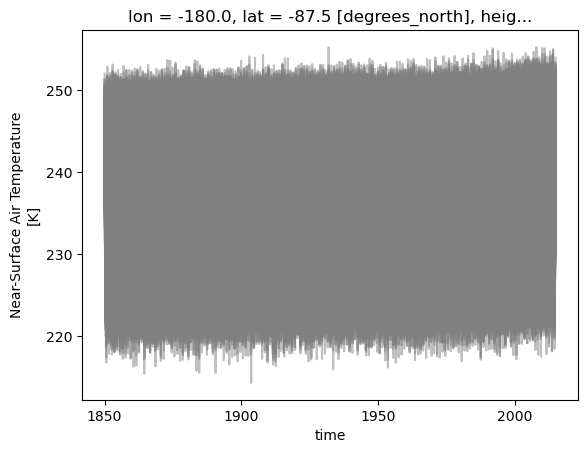

In [119]:
lesfmip_tree['CanESM5']['historical'].tas.isel(lat=0, lon=0).plot(
    hue='member', add_legend=False, color='grey', alpha=0.5);
era5_ds.isel(lat=0, lon=0).plot()

In [115]:
era5_ds.isel(lat=0, lon=0).plot()
lesfmip_tree['CanESM5']['historical'].tas.isel(lat=0, lon=0).plot(hue='member', add_legend=False);

Error in callback <function _draw_all_if_interactive at 0x7f6d9338e520> (for post_execute), with arguments args (),kwargs {}:


OverflowError: int too big to convert

OverflowError: int too big to convert

<Figure size 640x480 with 1 Axes>

# Quantile Warming

## Functions

In [55]:
import xarray_datatree_utils
import xarray_calc
from xarray_datatree_utils import skip_empty

In [56]:
"""LOWESS smoothing over an xarray grid, backed by statsmodels."""


from statsmodels.nonparametric.smoothers_lowess import lowess


def _lowess_1d(y, x, frac, it, delta):
    """Smooth one series, passing all-NaN input straight through.

    Parameters
    ----------
    y : (n,) array of values to smooth
    x : (n,) array of coordinate positions
    frac : float, fraction of points in each local window
    it : int, number of bisquare reweighting passes
    delta : float, distance within which fits are interpolated rather than computed

    Returns
    -------
    (n,) array of smoothed values, NaN where y is NaN
    """
    if not np.isfinite(y).any():
        return np.full_like(y, np.nan, dtype=float)
    return lowess(y, x, frac=frac, it=it, delta=delta, return_sorted=False)


def lowess_xarray(da, core_dims="year", window=81, it=3, delta=0.0):
    """Apply statsmodels LOWESS along one dimension of a DataArray.

    Parameters
    ----------
    da : DataArray to smooth
    core_dims : str, dimension to smooth along
    window : int, number of points in each local window
    it : int, number of bisquare reweighting passes; 0 disables robustness
    delta : float, interpolation distance in coordinate units; 0 fits every point

    Returns
    -------
    DataArray of smoothed values matching da
    """
    x = np.arange(da.sizes[core_dims])#da[core_dims].values.astype(float)
    frac = np.clip(window / da.sizes[core_dims], 0.0, 1.0)
    dims = da.dims
    if da.chunks is not None:
        da = da.chunk({core_dims: -1})
    return xr.apply_ufunc(
        _lowess_1d,
        da,
        input_core_dims=[[core_dims]],
        output_core_dims=[[core_dims]],
        kwargs={"x": x, "frac": frac, "it": it, "delta": delta},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    ).transpose(*dims)

In [57]:
# from scipy import sparse

# def lowess_matrix(n, frac):
#     """Sparse hat matrix for local linear regression with tricube weights."""
#     r = max(int(np.ceil(frac * n)), 2)
#     x = np.arange(n, dtype=float)
#     rows, cols, vals = [], [], []

#     for i in range(n):
#         lo = min(max(i - r // 2, 0), n - r)
#         idx = np.arange(lo, lo + r)
#         u = x[idx] - x[i]
#         w = (1 - np.abs(u / np.abs(u).max()) ** 3) ** 3

#         s0, s1, s2 = w.sum(), (w * u).sum(), (w * u**2).sum()
#         l = w * (s2 - s1 * u) / (s0 * s2 - s1**2)

#         rows.append(np.full(r, i))
#         cols.append(idx)
#         vals.append(l)

#     return sparse.csr_matrix(
#         (np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))),
#         shape=(n, n),
#     )

# @skip_empty
# def lowess_matrix_xarray(da, core_dims='year', window:int=81):

#     frac = window/da.sizes[core_dims]

#     S = lowess_matrix(da.sizes[core_dims], frac=frac)
    
#     smooth = xr.apply_ufunc(
#         lambda y: (S @ y.reshape(-1, y.shape[-1]).T).T.reshape(y.shape),
#         da,
#         input_core_dims=[[core_dims]],
#         output_core_dims=[[core_dims]],
#         dask="parallelized",
#         output_dtypes=[float],
#     )

#     return smooth

In [58]:
def _ring_index(levels, median):
    """Assign each consecutive quantile-level pair a ring index, 0 = adjacent to median.

    Args:
        levels (list[float]): Sorted quantile levels, including median.
        median (float): Quantile level treated as the band centre.

    Returns:
        list[int]: Ring index per consecutive pair, length len(levels) - 1.
    """
    median_idx = levels.index(median)
    rings = []
    for i in range(len(levels) - 1):
        rings.append(median_idx - (i + 1) if i + 1 <= median_idx else i - median_idx)
    return rings

def plot_fan(ax, da, quantiles, median=0.5, color="C0", alpha_min=0.15, alpha_max=0.6,
             lw=1.8, linestyle="-", label=None, band_labels=False,
             x_dim="year", quantile_dim="quantile"):
    """Draw adjacent, non-overlapping quantile bands and a median line on ax.

    Args:
        ax (plt.Axes): Axis to draw on.
        da (xr.DataArray): Dims (x_dim, quantile_dim).
        quantiles (Sequence[float]): Quantile levels excluding median, e.g. [0.1, 0.25, 0.75, 0.9].
        median (float): Quantile level drawn as a line and treated as the band centre.
        color (str): Band and line colour.
        alpha_min (float): Alpha of the outermost ring.
        alpha_max (float): Alpha of the ring(s) adjacent to the median.
        lw (float): Median line width.
        linestyle (str): Median line style.
        label (str | None): Legend entry for the median line.
        band_labels (bool): If True, label each band with its quantile range for the legend.
        x_dim (str): Name of the x coordinate.
        quantile_dim (str): Name of the quantile coordinate.

    Returns:
        plt.Line2D: The median line.
    """
    x = da[x_dim].values
    levels = sorted(set(quantiles) | {median})
    rings = _ring_index(levels, median)
    ring_alphas = np.linspace(alpha_max, alpha_min, max(rings) + 1)

    for i, ring in enumerate(rings):
        lo = da.sel({quantile_dim: levels[i]}, method="nearest").values
        hi = da.sel({quantile_dim: levels[i + 1]}, method="nearest").values
        band_label = f"{levels[i]:.0%}\u2013{levels[i + 1]:.0%}" if band_labels else None
        ax.fill_between(x, lo, hi, color=color, alpha=ring_alphas[ring], linewidth=0,
                         zorder=1, label=band_label)

    line, = ax.plot(x, da.sel({quantile_dim: median}).values, color=color,
                     linewidth=lw, linestyle=linestyle, zorder=3, label=label)
    return line

In [59]:
def plot_experiment_timeseries(point, colors, hue='member', variable='tas', ylim=None, figsize=None, row_height=1.2):
    experiments = list(point)

    if figsize is None:
        figsize = (10, row_height * len(experiments))

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(len(experiments), 1, hspace=0.05)
    axes = []

    for i, exp in enumerate(experiments):
        ax = fig.add_subplot(gs[i, 0], sharex=axes[0] if axes else None)
        axes.append(ax)

        da = point[exp][variable]
        color = colors.get(exp, f'C{i}') if isinstance(colors, dict) else colors[i]

        da.plot(ax=ax, hue=hue, color=color, add_legend=False, alpha=0.5)

        ax.set_ylabel(exp)
        ax.set_xlabel('')
        ax.set_title(None)
        ax.tick_params(axis='x', labelbottom=False, bottom=False)

        if ylim is not None:
            ax.set_ylim(ylim)

        formatting.style_ax(ax)

    axes[0].xaxis.tick_top()
    axes[0].xaxis.set_label_position('top')
    axes[0].tick_params(axis='x', labeltop=True, top=True)
    axes[0].set_xlabel('Year')

    axes[-1].tick_params(axis='x', labelbottom=True, bottom=True)
    axes[-1].set_xlabel('Year')

    return fig, axes

In [60]:
@skip_empty
def rolling_quantile(da, rolling_dim, window, quantiles, extra_dims=None):
    dims = ["window", *(extra_dims or [])]
    return da.rolling({rolling_dim: window}, center=True).construct("window").quantile(quantiles, dim=dims)

@skip_empty
def rolling_std(da, window=11, dim=['window', 'member']):
    return da.rolling(year=window, center=True).construct('window').std(dim=dim)

@skip_empty
def space_mean(ds): return ds.mean(dim=['lat', 'lon'])

@skip_empty
def seasonal_mean(ds): return ds.resample(time='QS-DEC').mean()

In [61]:
PLOT_QUANTILES = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]

## LESFMIP Info

In [62]:
lesfmip_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (lon: 144, member: 50, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (lon: 144, member: 30, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 709MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (lon: 144, member: 50, lat: 20, time: 2052)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (time: 2052, lat: 20, member: 10, lon: 144)
│   │       Coordinates:
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B ...
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 236MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (member: 65, time: 1980, lat: 20, lon: 144)
│           Coordinates:
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B ...
│           Data variables:
│               tas      (member, time, lat, lon) float64 3GB dask.array<chunksize=(5, 1980, 10, 144), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (member: 45, time: 1980, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * member   (member) object 360B 'r10i1p1f2' 'r10i1p3f1' ... 'r9i1p3f1'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │      

<Axes: >

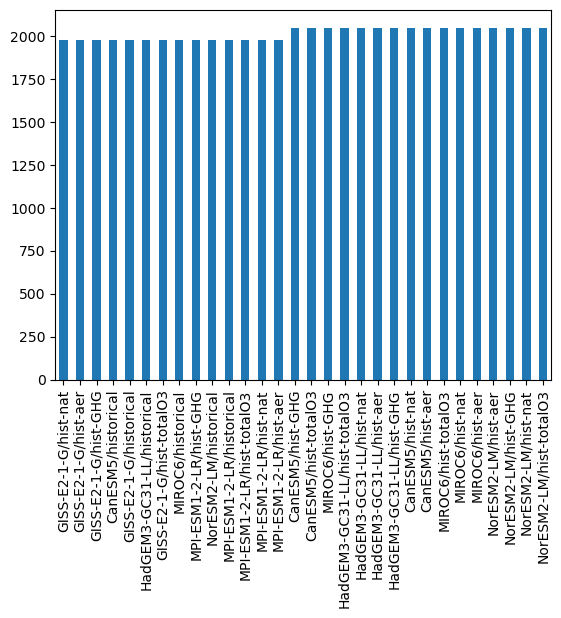

In [63]:
pd.Series(map_to_dict(lesfmip_tree, lambda ds: ds.sizes['time'])).sort_values().plot.bar()

In [64]:
# ensemble_members_numbers = pd.Series(map_to_dict(lesfmip_tree, lambda ds: ds.sizes['member'], multi_index=True)).sort_values()

member_counts = pd.Series(
    map_to_dict(lesfmip_tree, lambda ds: ds.sizes["member"], multi_index=True)
)
member_counts.index.names = ["model", "experiment"]
member_counts_grid = member_counts.unstack("experiment")

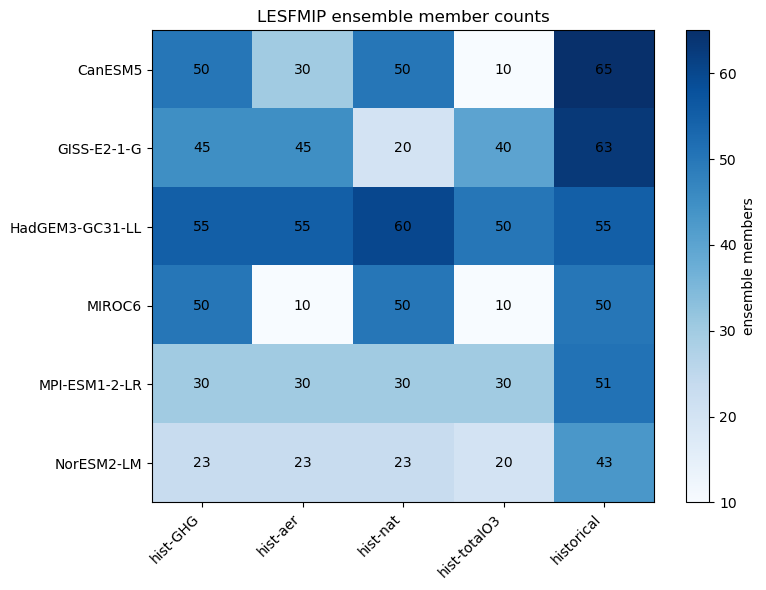

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("lightgrey")

im = ax.imshow(member_counts_grid.values.astype(float), cmap=cmap, aspect="auto")

ax.set_xticks(range(len(member_counts_grid.columns)))
ax.set_xticklabels(member_counts_grid.columns, rotation=45, ha="right")
ax.set_yticks(range(len(member_counts_grid.index)))
ax.set_yticklabels(member_counts_grid.index)

for i in range(member_counts_grid.shape[0]):
    for j in range(member_counts_grid.shape[1]):
        val = member_counts_grid.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, int(val), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="ensemble members")
ax.set_title("LESFMIP ensemble member counts")
fig.tight_layout()

Text(0.5, 1.0, 'NUmber of Ensemble Members')

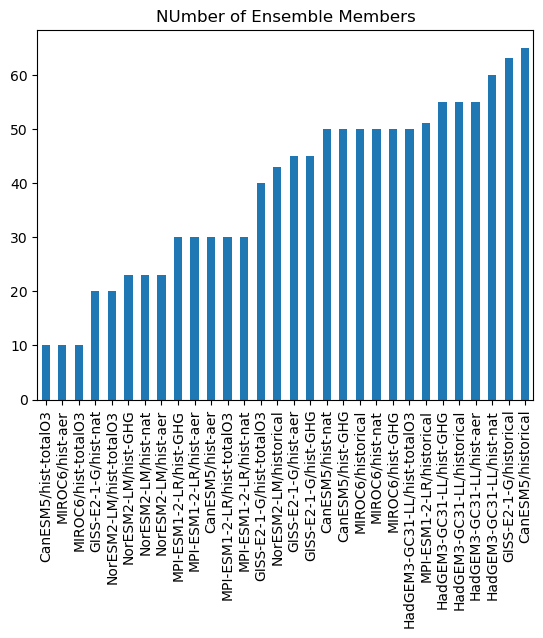

In [66]:
pd.Series(map_to_dict(lesfmip_tree, lambda ds: ds.sizes['member'])).sort_values().plot.bar()
plt.title('NUmber of Ensemble Members')

In [67]:
data_info = pd.DataFrame.from_dict(
    map_to_dict(
        lesfmip_tree, 
        xarray_datatree_utils.coord_info),
    orient='index')
data_info.head()

size                 chunk                memory  \
                     member  time lat  lon member  time lat  lon mbytes   
CanESM5/hist-GHG         50  2052  20  144      5  2052  10  144   1127   
CanESM5/hist-aer         30  2052  20  144      5  2052  10  144    676   
CanESM5/hist-nat         50  2052  20  144      5  2052  10  144   1127   
CanESM5/hist-totalO3     10  2052  20  144      5  2052  10  144    225   
CanESM5/historical       65  1980  20  144      5  1980  10  144   2827   

                                           
                     chunk_mbytes nchunks  
CanESM5/hist-GHG             56.4      20  
CanESM5/hist-aer             56.4      12  
CanESM5/hist-nat             56.4      20  
CanESM5/hist-totalO3         56.4       4  
CanESM5/historical          108.8      26

In [68]:
# (t): Sort by the sizes
data_info_sorted = data_info.sort_values(by=('memory', 'mbytes'), ascending=False)
sorted_model_experiments = data_info_sorted.index.values
sorted_model_experiments[:5]

array(['CanESM5/historical', 'MPI-ESM1-2-LR/historical',
       'GISS-E2-1-G/historical', 'HadGEM3-GC31-LL/hist-nat',
       'HadGEM3-GC31-LL/hist-aer'], dtype=object)

In [69]:
#(t): Converting from K to C
lesfmip_tree = lesfmip_tree - 273.15

In [70]:
#(t): This is the time step that matches between them all
#(c): TODO: For those that have an extend, this might make them all the same legnth
lesfmip_tree = lesfmip_tree.sel(time=slice(None, '2014-09-01'))

In [71]:
# chunks = {'time':-1, 'member': -1, 'lat':4, 'lon':-1}
chunks = {'time': -1, 'member': -1, 'lat': 4, 'lon': -1}
lesfmip_tree = lesfmip_tree.chunk(chunks)

In [72]:
#(t): Seaosonal average
lesfmip_tree = lesfmip_tree.map_over_datasets(seasonal_mean).isel(time=slice(1, -1))

In [73]:
#(t): Split the seasonal mean into dimension: e.g. instead of time, year and season
lesfmip_season_tree = lesfmip_tree.map_over_datasets(skip_empty(xarray_calc.split_time), kwargs=dict(parts=('year', 'season'), dim='time')).persist()
wait(lesfmip_season_tree);

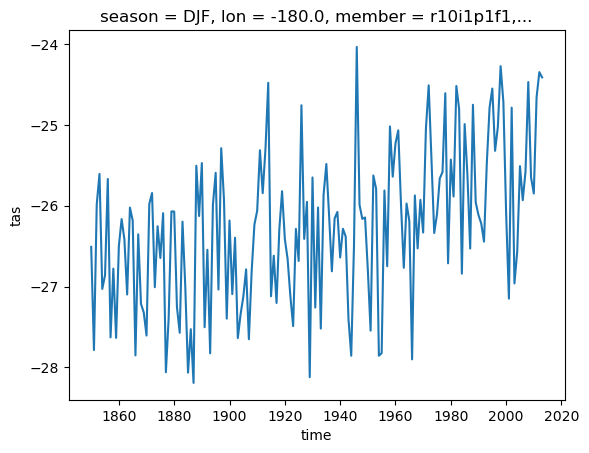

In [74]:
lesfmip_season_tree['CanESM5/historical'].tas.isel(lat=0, lon=0, member=0, season=0).plot();

## Quantile Calculation

In [75]:
from numba import njit

In [76]:
@njit
def rolling_percentile_numba(x, window, quantiles):
    nyear, nmember = x.shape
    nquantile = len(quantiles)
    half = window // 2

    out = np.full((nquantile, nyear), np.nan)

    for t in range(half, nyear - half):
        values = np.empty(window * nmember)
        n = 0

        for y in range(t - half, t + half + 1):
            for m in range(nmember):
                v = x[y, m]

                if not np.isnan(v):
                    values[n] = v
                    n += 1

        if n > 0:
            out[:, t] = np.quantile(values[:n], quantiles)

    return out

@skip_empty
def rolling_percentile_xr(
    da,
    rolling_dim="year",
    window=11,
    quantiles=(0.1, 0.5, 0.9),
    extra_dims=("member",),
):
    quantiles = np.asarray(quantiles, dtype=float)
    core_dims = [rolling_dim, *extra_dims]

    out = xr.apply_ufunc(
        rolling_percentile_numba,
        da,
        input_core_dims=[core_dims],
        output_core_dims=[["quantile", rolling_dim]],
        kwargs={
            "window": window,
            "quantiles": quantiles,
        },
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        dask_gufunc_kwargs={
            "output_sizes": {
                "quantile": len(quantiles),
                rolling_dim: da.sizes[rolling_dim],
            },
            "allow_rechunk": True,
        },
    )

    return out.assign_coords(quantile=quantiles)

In [77]:
from scipy import sparse

def lowess_matrix(n, frac):
    """Sparse weight matrices for local linear regression with tricube weights."""
    r = max(int(np.ceil(frac * n)), 2)
    x = np.arange(n, dtype=float)
    rows, cols, w_vals, wu_vals, wu2_vals = [], [], [], [], []

    for i in range(n):
        lo = min(max(i - r // 2, 0), n - r)
        idx = np.arange(lo, lo + r)
        u = x[idx] - x[i]

        d = np.abs(u).max()
        w = np.ones_like(u) if d == 0 else (1 - np.abs(u / d) ** 3) ** 3

        rows.append(np.full(r, i))
        cols.append(idx)
        w_vals.append(w)
        wu_vals.append(w * u)
        wu2_vals.append(w * u**2)

    rows = np.concatenate(rows)
    cols = np.concatenate(cols)

    W = sparse.csr_matrix((np.concatenate(w_vals), (rows, cols)), shape=(n, n))
    WU = sparse.csr_matrix((np.concatenate(wu_vals), (rows, cols)), shape=(n, n))
    WU2 = sparse.csr_matrix((np.concatenate(wu2_vals), (rows, cols)), shape=(n, n))

    return W, WU, WU2


@skip_empty
def lowess_matrix_xarray(da, core_dims='year', window: int = 81):
    frac = window / da.sizes[core_dims]
    W, WU, WU2 = lowess_matrix(da.sizes[core_dims], frac=frac)

    def smooth(y):
        shape = y.shape
        y = y.reshape(-1, shape[-1])

        valid = np.isfinite(y)
        y0 = np.where(valid, y, 0.0)
        m = valid.astype(float)

        s0 = (W @ m.T).T
        s1 = (WU @ m.T).T
        s2 = (WU2 @ m.T).T

        wy = (W @ y0.T).T
        wuy = (WU @ y0.T).T

        denom = s0 * s2 - s1**2

        out = np.full_like(y0, np.nan, dtype=float)
        np.divide(
            s2 * wy - s1 * wuy,
            denom,
            out=out,
            where=denom != 0,
        )

        out[~valid] = np.nan

        return out.reshape(shape)

    return xr.apply_ufunc(
        smooth,
        da,
        input_core_dims=[[core_dims]],
        output_core_dims=[[core_dims]],
        dask="parallelized",
        output_dtypes=[float],
    )

In [78]:
#(t): Defining quantiles
QUANTILES = np.array([0.9, 0.95, 0.99])
QUANTILES = np.sort(np.concatenate([1-QUANTILES, [0.5], QUANTILES])).round(2)
QUANTILES

array([0.01, 0.05, 0.1 , 0.5 , 0.9 , 0.95, 0.99])

In [79]:
#(t): The quantiles of the base period
q_histnat_base_tree = lesfmip_season_tree.match('*/hist-nat').map_over_datasets(skip_empty(lambda da: da.quantile(QUANTILES, dim=['year', 'member']))).compute()

In [80]:
rolling_quantile

<function __main__.rolling_quantile(da, rolling_dim, window, quantiles, extra_dims=None)>

In [81]:
# rolling_percentile_xr(lesfmip_season_tree['CanESM5/historical'], quantiles=QUANTILES)

In [82]:
%%time
lesfmip_tree_rolling_q = lesfmip_season_tree.map_over_datasets(
    partial(
        rolling_percentile_xr,
        rolling_dim="year",
        window=11,
        quantiles=QUANTILES,
        extra_dims=["member"],
    )
).persist()
wait(lesfmip_tree_rolling_q);

CPU times: user 247 ms, sys: 1.06 ms, total: 248 ms
Wall time: 249 ms


In [83]:
%%time
lesfmip_tree_smooth_q = lesfmip_tree_rolling_q.map_over_datasets(lowess_matrix_xarray).compute()

CPU times: user 232 ms, sys: 15.6 ms, total: 247 ms
Wall time: 1min 28s


CommClosedError: in <TLS (closed) ConnectionPool.gather local=tls://10.20.9.55:35742 remote=gateway://dask-gateway.jasmin.ac.uk:443/e05d086bb3664e93b0490ac2a2ce5997>: Stream is closed

In [ ]:
lesfmip_rolling_q_da = xarray_datatree_utils.tree_to_dataset(lesfmip_tree_rolling_q, dims=['model', 'experiment']).squeeze()

In [ ]:
lesfmip_smooth_q_da = xarray_datatree_utils.tree_to_dataset(lesfmip_tree_smooth_q, dims=['model', 'experiment']).squeeze()

In [ ]:
lesfmip_tree_smooth_q

In [ ]:
q_histnat_base_da = xarray_datatree_utils.tree_to_dataset(q_histnat_base_tree, dims=['model', 'experiment']).squeeze()
q_histnat_base_da

<b> Two methods of quantile changes <b>


**1. Differences**
- Difference in exp − difference in hist-nat
- This is more in line with Bracegirdle et al., 2024

$$
\text{diff} = (\text{difference in experiment}) - (\text{difference in hist-nat})
$$

$$
= (p_{\text{upper, exp}} - p_{\text{lower, exp}}) - (p_{\text{upper, hist-nat}} - p_{\text{lower, hist-nat}})
$$

**2. Anomalies**
- Calculate anomalies; difference between anomalies; difference between experiments

$$
\begin{aligned}
\text{diff} &= (p_{\text{upper, exp}} - p_{\text{upper, hist-nat}}) - (p_{\text{lower, exp}} - p_{\text{lower, hist-nat}}) \\
&= p_{\text{upper, exp}} - p_{\text{upper, hist-nat}} - p_{\text{lower, exp}} + p_{\text{lower, hist-nat}} \\
&= (p_{\text{upper, exp}} - p_{\text{lower, exp}}) - (p_{\text{upper, hist-nat}} - p_{\text{lower, hist-nat}})
\end{aligned}
$$

- Which just becomes the same as the first one

In [ ]:
lesfmip_change_quantile_da = lesfmip_smooth_q_da - q_histnat_base_da

In [ ]:
lesfmip_change_quantile_da = lesfmip_change_quantile_da.compute()

In [ ]:
lesfmip_change_quantile_da

In [ ]:
#(t): Final anomaly
#(c): space only
final_change_quantile = lesfmip_change_quantile_da.isel(year=-6).compute()
final_change_quantile

In [ ]:
a = lesfmip_tree_rolling_q["CanESM5"]["hist-GHG"]["tas"].isel(
    lat=0, lon=0, season=0, quantile=0
).dropna(dim='year')

b = lesfmip_tree_smooth_q["CanESM5"]["hist-GHG"]["tas"].isel(
    lat=0, lon=0, season=0, quantile=0
).dropna(dim='year')

print(a.year.values[[0, -1]], a.sizes["year"])
print(b.year.values[[0, -1]], b.sizes["year"])

print(a.dropna("year").year.values[[0, -1]])
print(b.dropna("year").year.values[[0, -1]])

In [ ]:
lesfmip_tree_rolling_q['CanESM5/historical'].isel(season=0, lat=0, lon=0).tas.plot(hue='quantile');
lesfmip_tree_smooth_q['CanESM5/historical'].isel(season=0, lat=0, lon=0).tas.plot(hue='quantile');
# lesfmip_tree_smooth_q_v2['CanESM5/historical'].isel(season=0, lat=0, lon=0).tas.plot(hue='quantile');


# lesfmip_smooth_q_da.tas.sel(model='CanESM5', experiment='historical').isel(season=0, lat=0, lon=0).plot(hue='quantile');

In [ ]:
lesfmip_tree_rolling_q['CanESM5/historical'].isel(season=0, lat=0, lon=0).tas.plot(hue='quantile');

In [ ]:
lesfmip_tree_rolling_q['CanESM5/hist-nat'].isel(season=0, lat=0, lon=0).tas.std(dim='year').plot()

In [ ]:
lesfmip_tree_rolling_q['CanESM5/hist-nat'].isel(season=0, lat=0, lon=0).tas.plot(hue='quantile');

In [ ]:
lesfmip_change_quantile_da.tas.isel(year=-6, model=0, season=0, quantile=0).plot(col='experiment')

In [ ]:
from typing import NamedTuple

In [ ]:
class QuantilePairs(NamedTuple):#
    lower:float
    upper:float

In [ ]:
quantile_pairs = [QuantilePairs(lower=0.01, upper=0.9), QuantilePairs(lower=0.05, upper=0.95), QuantilePairs(lower=0.01, upper=0.99)]

In [ ]:
final_quantile_spread = xr.concat(
    [(final_change_quantile.sel(quantile=qp.upper) - final_change_quantile.sel(quantile=qp.lower)).assign_coords(quantile=qp.upper) for qp in quantile_pairs],
    dim='quantile').tas

In [ ]:
models_spread_sign_count = xr.concat(
    [
        (final_quantile_spread > 0).sum("model"),
        (final_quantile_spread < 0).sum("model"),
    ],
    dim=xr.IndexVariable("change", ["increase", "decrease"]),
)

In [ ]:
models_spread_sign_count

In [ ]:
(models_spread_sign_count.sel(experiment='historical', season='DJF')/6).plot(col='quantile', row='change', subplot_kws={'projection':ccrs.SouthPolarStereo()}, transform=ccrs.PlateCarree())

In [ ]:
final_quantile_spread

In [ ]:
final_quantile_spread.isel(season=0, model=0).sel(experiment='historical').plot(col='quantile', robust=True)

In [ ]:
#(t): Space mean
# lesfmip_tree_smooth_q_smean = lesfmip_tree_change_quantile.map_over_datasets(space_mean)

In [ ]:
# #(t): That change of the intensity of the quantiles
# #(c): space x time
# lesfmip_tree_change_quantile = xr.DataTree.from_dict(
#     {key: xarray_datatree_utils.to_dataset(lesfmip_tree_smooth_q[key], concat_dim='experiment') - q_histnat_base_tree[key] for key in q_histnat_base_tree})

In [ ]:
# ~
#(t): Calculting rolling quantiles over all datasets
# lesfmip_tree_rolling_q = lesfmip_season_tree.map_over_datasets(
#     partial(rolling_quantile, rolling_dim='year', window=11, quantiles=QUANTILES, extra_dims=['member'])
# ).compute()

In [ ]:
# %%time
# # lowess_matrix_xarray 
# lesfmip_tree_smooth_q = lesfmip_tree_rolling_q.map_over_datasets(skip_empty(lowess_xarray)).compute()
# lesfmip_smooth_q_da = xarray_datatree_utils.tree_to_dataset(lesfmip_tree_smooth_q, dims=['model', 'experiment']).squeeze()

## Method demonstration

In [ ]:
client.upload_file('/home/users/aborow/ExtAnt-initial/xarray_stats.py');

In [ ]:
EXMAPLE_QUANTILES = [0.05, 0.95]

In [ ]:
lesfmip_season_example =  xr.DataTree.from_dict(
    {protocal:lesfmip_season_tree['CanESM5'][protocal].isel(season=0, lat=0, lon=0) for protocal in ['historical', 'hist-nat']})
lesfmip_season_example

In [ ]:
# lesfmip_season_example =  lesfmip_season_tree['CanESM5']['hist-nat'].tas.isel(season=0, lat=0, lon=0)
lesfmip_smooth_q_example = lesfmip_smooth_q_da.tas.isel(lat=0, lon=0, season=0).sel(model='CanESM5', experiment=['historical', 'hist-nat']).sel(quantile=EXMAPLE_QUANTILES)

In [ ]:
q_histnat_base_example = q_histnat_base_tree['CanESM5']['hist-nat'].tas.isel(season=0, lat=0, lon=0).sel(quantile=EXMAPLE_QUANTILES).compute()
q_histnat_base_example

In [ ]:
example_qdiff = lesfmip_smooth_q_example.isel(quantile=1) - lesfmip_smooth_q_example.isel(quantile=0)

In [ ]:
# example_qdiff = xarray_calc.quantile_ranges(lesfmip_smooth_q_example, pairs={'lower':0.9, 'upper':0.1})

In [ ]:
lesfmip_smooth_q_exampleta_kds = xarray_stats.fast_kde_xr(
    lesfmip_season_example['hist-nat'].tas.stack(member_year=['member', 'year']).compute(),
    np.linspace(lesfmip_season_example['hist-nat'].tas.min().values.item()-1, lesfmip_season_example['hist-nat'].tas.max().values.item()+1, 1000), 'member_year').compute()

In [ ]:
example_qdiff_kds = xarray_stats.fast_kde_xr(
    example_qdiff,
    np.linspace(example_qdiff.min().values.item()-1, example_qdiff.max().values.item()+1, 1000), 'year').compute()

In [ ]:
fig, ax = plt.subplots()
lesfmip_smooth_q_exampleta_kds.plot()
for qname, qval in dict(zip(q_histnat_base_example['quantile'].values, q_histnat_base_example.values)).items():
    ax.axvline(qval, label=qname, color='grey', alpha=0.5, linestyle='--')

In [ ]:
fig, ax = plt.subplots()
lesfmip_smooth_q_example.isel(experiment=0).sel(quantile=EXMAPLE_QUANTILES).plot(hue='quantile', color='green', linestyle='--');
lesfmip_smooth_q_example.isel(experiment=1).sel(quantile=EXMAPLE_QUANTILES).plot(hue='quantile', color='black', linestyle='--');

ax.axhline(q_histnat_base_example.isel(quantile=0), color='red')
ax.axhline(q_histnat_base_example.isel(quantile=1), color='red')

In [ ]:
example_qdiff.plot(hue='experiment')

In [ ]:
example_qdiff_kds.sel(experiment='hist-nat').plot()
example_qdiff_kds.sel(experiment='historical').plot()

In [ ]:
example_qdiff.isel(experiment=0).plot(hue='qrange');
example_qdiff.isel(experiment=1).plot(hue='qrange');

In [ ]:
lesfmip_smooth_q_example.isel(experiment=0).plot(hue='quantile');
lesfmip_smooth_q_example.isel(experiment=1).plot(hue='quantile');

## Plots

In [ ]:
models_spread_sign_count

In [ ]:
reload(utils)

In [ ]:
total_models_bounds = np.arange(0, 7)

total_models_cmap, total_models_norm = utils.make_diverging_colormap(
    total_models_bounds,
    pos_cmap='viridis',
    neg_cmap="Blues_r",
    # pos_cmap="Reds",
    white_range=(0, 0.1),
)

In [ ]:
total_models_cmap

In [ ]:
reload(maps)

In [ ]:
logger.setLevel('INFO')

In [ ]:
da = models_spread_sign_count.sel({'season': 'DJF', 'quantile': 0.99})
da

In [ ]:
from importlib import reload
from plotting_modules import core, maps

reload(core)
reload(maps)

In [ ]:
models_spread_sign_count.sel({'season': 'DJF', 'quantile': 0.99})

In [ ]:
import matplotlib as mpl
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap


def make_model_count_colormap(n_models=6,  base_cmap="Blues"):
    """Discrete sequential colormap with 0=white and one colour per model count."""
    base = mpl.colormaps[base_cmap]

    colors = ["white", *[base(x) for x in np.linspace(0.35, 1, n_models)]]
    cmap = ListedColormap(colors)

    bounds = np.arange(-0.5, n_models + 1.5)
    norm = BoundaryNorm(bounds, cmap.N)

    return cmap, norm

In [ ]:
model_cmap, model_norm = make_model_count_colormap(6, base_cmap='winter')

In [ ]:
model_cmap

In [ ]:
panels = maps.polar_grid(
    models_spread_sign_count.sel({'season': 'DJF', 'quantile': 0.99}),
    col_dim='experiment',
    row_dim='change',
    levels=total_models_bounds,
    cmap=model_cmap,
    norm=model_norm,
    plot_type='pcolourmesh',
    cbar_label='Number of models',
    cbar_height=0.33
    # title=True
)

# Bootstrapping and Permutation tests

## Bootstrap Examples

In [ ]:
# Defined from Permutation Test (All grid cells)
max_loc = {'season': 'DJF', 'lon': -180.0, 'lat': -75.0}

In [ ]:
lesfmip_season_example =  xr.DataTree.from_dict(
    {protocal:lesfmip_season_tree['CanESM5'][protocal].sel(max_loc) for protocal in ['historical', 'hist-nat']})
lesfmip_season_example

In [ ]:
rng = np.random.default_rng()
n_samples = 10
n_trials = 10000

random_indexes_histnat = np.argsort(
    rng.random((n_trials, lesfmip_season_example['hist-nat'].sizes['member'])), axis=1)[:, :n_samples]
idx_histnat_da = xr.DataArray(random_indexes_histnat, dims=('trial', 'member'))

idx_histnat_da

In [ ]:
random_indexes_hist = np.argsort(rng.random((n_trials, lesfmip_season_example['historical'].sizes['member'])), axis=1)[:, :n_samples]
idx_hist_da = xr.DataArray(random_indexes_hist, dims=('trial', 'member'))

idx_hist_da

In [ ]:
chunks = {
    'trial': 500,
    'member': -1,
    'year': -1,
}

In [ ]:
hist_boot = lesfmip_season_example['historical'].tas.isel(member=idx_hist_da).chunk(chunks).persist()
wait(hist_boot);

In [ ]:
rng = np.random.default_rng()
n_trials = 10_000

n_hist = lesfmip_season_example['historical'].sizes['member']
n_histnat = lesfmip_season_example['hist-nat'].sizes['member']

idx_hist_da = xr.DataArray(
    rng.integers(0, n_hist, size=(n_trials, n_hist)),
    dims=('trial', 'member'),
)

idx_histnat_da = xr.DataArray(
    rng.integers(0, n_histnat, size=(n_trials, n_histnat)),
    dims=('trial', 'member'),
)

hist_boot = (
    lesfmip_season_example['historical'].tas
    .isel(member=idx_hist_da)
    .chunk(chunks)
    .persist()
)
wait(hist_boot)

histnat_boot = (
    lesfmip_season_example['hist-nat'].tas
    .isel(member=idx_histnat_da)
    .chunk(chunks)
    .persist()
)
wait(histnat_boot);

In [ ]:
rolling_percentile_boot_hist = rolling_percentile_xr(
    hist_boot, 
    rolling_dim="year",
    window=11,
    quantiles=EXMAPLE_QUANTILES,
    extra_dims=["member"]
)

In [ ]:
%%time
rolling_percentile_boot_hist = rolling_percentile_boot_hist.compute()

In [ ]:
histnat_boot = lesfmip_season_example['hist-nat'].isel(member=idx_histnat_da).chunk(chunks).persist()
wait(histnat_boot);

In [ ]:
rolling_percentile_boot_histnat = rolling_percentile_xr(
    histnat_boot, 
    rolling_dim="year",
    window=11,
    quantiles=EXMAPLE_QUANTILES,
    extra_dims=["member"]
)

In [ ]:
%%time
rolling_percentile_boot_histnat = rolling_percentile_boot_histnat.compute()

In [ ]:
qdiff_boot = rolling_percentile_boot_hist - rolling_percentile_boot_histnat

In [ ]:
qdiff_boot = qdiff_boot.sel(quantile=0.95) - qdiff_boot.sel(quantile=0.05)

In [ ]:
qdiff_boot_quantile = qdiff_boot.quantile([0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99], dim='trial')

In [ ]:
qdiff_boot_quantile = qdiff_boot_quantile.rename({'quantile': 'trial_quantile'})

In [ ]:
qdiff_boot_quantile.tas.plot(hue='trial_quantile');
(example_qdiff.isel(experiment=0) - example_qdiff.isel(experiment=1)).plot()

## Pemutation test example

In [ ]:
lesfmip_season_example["historical"].tas

In [ ]:
rng = np.random.default_rng()
n_trials = 10_000

In [ ]:
hist = lesfmip_season_example["historical"].tas
histnat = lesfmip_season_example["hist-nat"].tas

In [ ]:
histnat

In [ ]:
n_hist = hist.sizes["member"]
n_histnat = histnat.sizes["member"]
n_total = n_hist + n_histnat

In [ ]:
# Pool all member trajectories
pooled = xr.concat(
    [
        hist.rename(member="pool_member"),
        histnat.rename(member="pool_member"),
    ],
    dim="pool_member",
)

In [ ]:
pooled

In [ ]:
# Random permutation of all members for each trial
random_indexes = np.argsort(
    rng.random((n_trials, n_total)),
    axis=1,
)

idx_hist = xr.DataArray(
    random_indexes[:, :n_hist],
    dims=("trial", "member"),
)

idx_histnat = xr.DataArray(
    random_indexes[:, n_hist:],
    dims=("trial", "member"),
)

# Randomly relabel members as historical / hist-nat
hist_perm = (
    pooled
    .isel(pool_member=idx_hist)
    .chunk({"trial": 500, "member": -1, "year": -1})
    .persist()
)
wait(hist_perm);

histnat_perm = (
    pooled
    .isel(pool_member=idx_histnat)
    .chunk({"trial": 500, "member": -1, "year": -1})
    .persist()
)
wait(histnat_perm)

# Same statistic as the real analysis
hist_q_perm = rolling_percentile_xr(
    hist_perm,
    rolling_dim="year",
    window=11,
    quantiles=EXMAPLE_QUANTILES,
    extra_dims=["member"],
)

histnat_q_perm = rolling_percentile_xr(
    histnat_perm,
    rolling_dim="year",
    window=11,
    quantiles=EXMAPLE_QUANTILES,
    extra_dims=["member"],
)

hist_range_perm = (
    hist_q_perm.sel(quantile=0.95)
    - hist_q_perm.sel(quantile=0.05)
).compute()

histnat_range_perm = (
    histnat_q_perm.sel(quantile=0.95)
    - histnat_q_perm.sel(quantile=0.05)
).compute()

qdiff_perm = hist_range_perm - histnat_range_perm

In [ ]:
hist_q = rolling_percentile_xr(
    hist,
    rolling_dim="year",
    window=11,
    quantiles=EXMAPLE_QUANTILES,
    extra_dims=["member"],
).compute()

histnat_q = rolling_percentile_xr(
    histnat,
    rolling_dim="year",
    window=11,
    quantiles=EXMAPLE_QUANTILES,
    extra_dims=["member"],
).compute()

qdiff_actual = (
    hist_q.sel(quantile=0.95)
    - hist_q.sel(quantile=0.05)
    - histnat_q.sel(quantile=0.95)
    + histnat_q.sel(quantile=0.05)
)

In [ ]:
pvalue = (
    (np.abs(qdiff_perm) >= np.abs(qdiff_actual)).sum("trial") + 1
) / (n_trials + 1)

significant = pvalue < 0.05

In [ ]:
pvalue

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Actual response
actual = example_qdiff.isel(experiment=0) - example_qdiff.isel(experiment=1)

# Null distribution quantiles
perm_q = qdiff_perm.quantile(
    [0.025, 0.05, 0.5, 0.95, 0.975],
    dim="trial",
)

# Two-sided permutation p-value
pvalue = (
    (np.abs(qdiff_perm) >= np.abs(actual)).sum("trial") + 1
) / (qdiff_perm.sizes["trial"] + 1)

significant = pvalue < 0.05


fig, ax = plt.subplots(figsize=(10, 5))

year = actual.year

# Permutation null distribution
ax.fill_between(
    year,
    perm_q.sel(quantile=0.025),
    perm_q.sel(quantile=0.975),
    alpha=0.15,
    label="95% null interval",
)

ax.fill_between(
    year,
    perm_q.sel(quantile=0.05),
    perm_q.sel(quantile=0.95),
    alpha=0.2,
    label="90% null interval",
)

ax.plot(
    year,
    perm_q.sel(quantile=0.5),
    ls="--",
    lw=1.2,
    label="Null median",
)

# Actual historical - hist-nat response
ax.plot(
    year,
    actual,
    color="k",
    lw=2,
    label="Actual response",
)

# Overplot significant parts
ax.plot(
    year,
    actual.where(significant),
    lw=3,
    label=r"$p < 0.05$",
)

ax.axhline(0, color="0.4", lw=0.8)

ax.set(
    xlabel="Year",
    ylabel=r"$\Delta(p_{95} - p_{05})$ (K)",
    title="Historical − hist-nat change in temperature range",
)

ax.legend(frameon=False, ncol=2)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

actual = example_qdiff.isel(experiment=0) - example_qdiff.isel(experiment=1)
perm = qdiff_perm.tas if hasattr(qdiff_perm, "tas") else qdiff_perm

# Pick an example year
year_sel = 2000

# Permutation distribution at that year
perm_year = perm.sel(year=year_sel).compute()
actual_year = float(actual.sel(year=year_sel))

# Permutation envelope through time
perm_q = perm.quantile([0.025, 0.5, 0.975], dim="trial").compute()


fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

# ------------------------------------------------------------------
# A. Example permutation distribution
# ------------------------------------------------------------------
ax = axs[0]

ax.hist(
    perm_year,
    bins=50,
    density=True,
    alpha=0.6,
)

ax.axvline(0, color="0.5", ls="--", lw=1)

ax.axvline(
    actual_year,
    color="k",
    lw=2.5,
    label="Actual response",
)

ax.set(
    xlabel=r"$\Delta(p_{95}-p_{05})$ (K)",
    ylabel="Density",
    title=f"Permutation distribution ({year_sel})",
)

ax.legend(frameon=False)


# ------------------------------------------------------------------
# B. Response through time
# ------------------------------------------------------------------
ax = axs[1]

ax.fill_between(
    perm_q.year,
    perm_q.sel(quantile=0.025),
    perm_q.sel(quantile=0.975),
    alpha=0.2,
    label="95% permutation range",
)

ax.plot(
    perm_q.year,
    perm_q.sel(quantile=0.5),
    ls="--",
    lw=1,
    label="Null median",
)

ax.plot(
    actual.year,
    actual,
    color="k",
    lw=2,
    label="Actual response",
)

ax.axhline(0, color="0.5", lw=1)

ax.set(
    xlabel="Year",
    ylabel=r"$\Delta(p_{95}-p_{05})$ (K)",
    title="Observed response vs permutation range",
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
rolling_percentile_boot_hist

## Permutation and sameple-size significance

In [ ]:
def quantile_range(
    da: xr.DataArray,
    quantiles: tuple = (0.05, 0.95),
    dims: tuple = ("member", "year"),
) -> xr.DataArray:
    """Return the pooled upper-minus-lower quantile range."""
    dims = tuple(d for d in dims if d in da.dims)

    if da.chunks is not None:
        da = da.chunk({d: -1 for d in dims})

    q_da = da.quantile(quantiles, dim=dims, skipna=True)

    return (
        q_da.sel(quantile=quantiles[1], drop=True)
        - q_da.sel(quantile=quantiles[0], drop=True)
    ) 


def rolling_quantile_range(
    da: xr.DataArray,
    window: int = 11,
    quantiles: tuple = (0.05, 0.95),
    rolling_dim: str = "year",
    member_dim: str = "member",
) -> xr.DataArray:
    """Return the rolling pooled upper-minus-lower quantile range."""
    q_da = rolling_percentile_xr(
        da,
        rolling_dim=rolling_dim,
        window=window,
        quantiles=quantiles,
        extra_dims=(member_dim,),
    )

    return (
        q_da.sel(quantile=quantiles[1], drop=True)
        - q_da.sel(quantile=quantiles[0], drop=True)
    )
def sample_hist_nat_qrange_changes(
    hist_nat_da: xr.DataArray,
    hist_nat_reference_qrange_da: xr.DataArray,
    n_members_to_sample: int,
    years: int = 11,
    quantiles: tuple = (0.05, 0.95),
    n_trials: int = 10_000,
    batch_size: int = 100,
    seed: int = 0,
) -> xr.DataArray:
    """Sample hist-nat members and periods to estimate Q-range variability."""
    rng = np.random.default_rng(seed)

    n_hist_nat_members = hist_nat_da.sizes["member"]
    n_hist_nat_years = hist_nat_da.sizes["year"]

    if n_members_to_sample > n_hist_nat_members:
        raise ValueError(
            "n_members_to_sample cannot exceed available hist-nat members."
        )

    if years % 2 == 0:
        raise ValueError("years must be odd.")

    half_window = years // 2

    # All centre years that have a complete N-year window.
    valid_centre_indices = np.arange(
        half_window,
        n_hist_nat_years - half_window,
    )
    n_valid_windows = len(valid_centre_indices)

    # Use every possible time window approximately equally.
    n_full_repeats = n_trials // n_valid_windows
    n_extra_trials = n_trials % n_valid_windows

    sampled_centre_indices = np.tile(
        valid_centre_indices,
        n_full_repeats,
    )

    if n_extra_trials:
        sampled_centre_indices = np.concatenate([
            sampled_centre_indices,
            rng.choice(
                valid_centre_indices,
                n_extra_trials,
                replace=False,
            ),
        ])

    rng.shuffle(sampled_centre_indices)

    # Relative year positions within each centred window.
    year_offsets = np.arange(-half_window, half_window + 1)

    qrange_change_batches = []

    for start in range(0, n_trials, batch_size):
        n_trials_in_batch = min(batch_size, n_trials - start)

        # ----------------------------------------------------
        # Choose N distinct hist-nat members for each trial.
        # ----------------------------------------------------

        random_member_scores = rng.random(
            (n_trials_in_batch, n_hist_nat_members)
        )

        sampled_member_indices = np.argpartition(
            random_member_scores,
            n_members_to_sample - 1,
            axis=1,
        )[:, :n_members_to_sample]

        sampled_member_indices_da = xr.DataArray(
            sampled_member_indices,
            dims=("trial", "sample_member"),
        )

        # ----------------------------------------------------
        # Choose the actual N-year window for each trial.
        # ----------------------------------------------------

        batch_centre_indices = sampled_centre_indices[
            start:start + n_trials_in_batch
        ]

        sampled_year_indices = (
            batch_centre_indices[:, None]
            + year_offsets[None, :]
        )

        sampled_year_indices_da = xr.DataArray(
            sampled_year_indices,
            dims=("trial", "sample_year"),
        )

        # ----------------------------------------------------
        # Extract ONLY the required members and years.
        #
        # Result has dimensions approximately:
        # trial × sample_member × sample_year × season × lat × lon
        # ----------------------------------------------------

        sampled_hist_nat_da = hist_nat_da.isel(
            member=sampled_member_indices_da,
            year=sampled_year_indices_da,
        )

        # One Q95-Q05 calculation per trial.
        sampled_qrange_da = quantile_range(
            sampled_hist_nat_da,
            quantiles=quantiles,
            dims=("sample_member", "sample_year"),
        )

        qrange_change_batches.append(
            (
                sampled_qrange_da
                - hist_nat_reference_qrange_da
            )
            .compute()
            .astype("float32")
        )

    return xr.concat(
        qrange_change_batches,
        dim="trial",
    ).assign_coords(trial=np.arange(n_trials))
def permutation_qrange_changes(
    experiment_da: xr.DataArray,
    hist_nat_da: xr.DataArray,
    quantiles: tuple = (0.05, 0.95),
    n_trials: int = 10_000,
    batch_size: int = 100,
    seed: int = 0,
) -> xr.DataArray:
    """Permute whole members between an experiment and hist-nat."""
    rng = np.random.default_rng(seed)

    n_experiment_members = experiment_da.sizes["member"]
    n_hist_nat_members = hist_nat_da.sizes["member"]
    n_pooled_members = n_experiment_members + n_hist_nat_members

    # Pool both ensembles while keeping each member's full
    # time series intact.
    pooled_members_da = xr.concat(
        [
            experiment_da.rename(member="pool_member"),
            hist_nat_da.rename(member="pool_member"),
        ],
        dim="pool_member",
    ).assign_coords(
        pool_member=np.arange(n_pooled_members)
    )

    qrange_difference_batches = []

    for start in range(0, n_trials, batch_size):
        n_trials_in_batch = min(
            batch_size,
            n_trials - start,
        )

        # ----------------------------------------------------
        # Randomly partition the pooled members.
        #
        # Each trial gets:
        #   - n_experiment_members in the experiment-sized group
        #   - n_hist_nat_members in the hist-nat-sized group
        # ----------------------------------------------------

        random_member_scores = rng.random(
            (n_trials_in_batch, n_pooled_members)
        )

        random_partition = np.argpartition(
            random_member_scores,
            n_experiment_members - 1,
            axis=1,
        )

        experiment_member_indices_da = xr.DataArray(
            random_partition[:, :n_experiment_members],
            dims=("trial", "experiment_member"),
        )

        hist_nat_member_indices_da = xr.DataArray(
            random_partition[:, n_experiment_members:],
            dims=("trial", "hist_nat_member"),
        )

        permuted_experiment_da = pooled_members_da.isel(
            pool_member=experiment_member_indices_da
        )

        permuted_hist_nat_da = pooled_members_da.isel(
            pool_member=hist_nat_member_indices_da
        )

        # Calculate Q95-Q05 for each randomly formed group.
        permuted_experiment_qrange_da = quantile_range(
            permuted_experiment_da,
            quantiles=quantiles,
            dims=("experiment_member", "year"),
        )

        permuted_hist_nat_qrange_da = quantile_range(
            permuted_hist_nat_da,
            quantiles=quantiles,
            dims=("hist_nat_member", "year"),
        )

        # Difference between the randomly formed groups.
        qrange_difference_batches.append(
            (
                permuted_experiment_qrange_da
                - permuted_hist_nat_qrange_da
            )
            .compute()
            .astype("float32")
        )

    return xr.concat(
        qrange_difference_batches,
        dim="trial",
    ).assign_coords(trial=np.arange(n_trials))

In [ ]:
# ============================================================
# SETTINGS
# ============================================================

model = "CanESM5"
experiment = "historical"

window_length = 11
quantiles = (0.05, 0.95)

n_trials = 600
batch_size = 100
alpha = 0.05
seed = 0

In [ ]:
ensemble_sizes = [da.sizes['member'] for da in lesfmip_season_tree.match('CanESM5/*').leaves]
ensemble_sizes

In [ ]:
# ============================================================
# DATA
# ============================================================

# Full hist-nat record.
hist_nat_da = (
    lesfmip_season_tree[model]["hist-nat"].tas
    .dropna("member", how="all")
).persist()
wait(hist_nat_da);

# Hist-nat over the same final period as historical.
hist_nat_period_da = (
    hist_nat_da
    .isel(year=slice(-years, None))
    .dropna("member", how="all")
)

wait(hist_nat_period_da);

# Historical over the final period.
hist_exp_da = (
    lesfmip_season_tree[model][experiment].tas
    .isel(year=slice(-years, None))
    .dropna("member", how="all")
)

wait(hist_exp_da);


# n_hist_exp_members = hist_exp_da.sizes["member"]

In [ ]:
# ============================================================
# Q95-Q05 RANGES
# ============================================================

# Long-term natural Q95-Q05 reference.
hist_nat_qrange_da = quantile_range(
    hist_nat_da,
    quantiles=quantiles,
).compute().rename("hist_nat_qrange")

# Hist-nat over the final 11 years.
hist_nat_period_qrange_da = quantile_range(
    hist_nat_period_da,
    quantiles=quantiles,
).compute().rename("hist_nat_period_qrange")

# Historical over the final 11 years.
hist_exp_qrange_da = quantile_range(
    hist_exp_da,
    quantiles=quantiles,
).compute().rename("hist_exp_qrange")

In [ ]:
# ============================================================
# OBSERVED CHANGE
# ============================================================

# Historical relative to the long-term natural reference.
# Positive = wider distribution.
# Negative = narrower distribution.
qrange_change_da = (
    hist_exp_qrange_da - hist_nat_qrange_da
).rename("qrange_change")


In [ ]:
# ============================================================
# 1. OUTSIDE POSSIBLE N-MEMBER HIST-NAT RANGE
# ============================================================

# Repeatedly select the same number of members as historical
# from hist-nat and calculate their Q95-Q05 over 11-year periods.

hist_nat_qrange_change_samples_da = sample_hist_nat_qrange_changes(
    hist_nat_da=hist_nat_da,
    hist_nat_reference_qrange_da=hist_nat_qrange_da,
    n_members_to_sample=np.min(ensemble_sizes),
    years=years,
    quantiles=quantiles,
    n_trials=n_trials,
    batch_size=batch_size,
    seed=seed,
)

In [ ]:
# Central 95% of changes obtainable from hist-nat.
hist_nat_qrange_change_bounds_da = (
    hist_nat_qrange_change_samples_da
    .quantile([alpha / 2, 1 - alpha / 2], dim="trial")
)

hist_nat_qrange_change_lower_95_da = (
    hist_nat_qrange_change_bounds_da
    .sel(quantile=alpha / 2, drop=True)
    .rename("hist_nat_qrange_change_lower_95")
)

hist_nat_qrange_change_upper_95_da = (
    hist_nat_qrange_change_bounds_da
    .sel(quantile=1 - alpha / 2, drop=True)
    .rename("hist_nat_qrange_change_upper_95")
)

# True where historical is outside what N hist-nat members
# over an 11-year period can reasonably produce.
qrange_outside_hist_nat_range_da = (
    (qrange_change_da < hist_nat_qrange_change_lower_95_da)
    | (qrange_change_da > hist_nat_qrange_change_upper_95_da)
).rename("qrange_outside_hist_nat_range")

In [ ]:
# ============================================================
# 2. PERMUTATION TEST
# ============================================================

# Actual historical minus hist-nat difference over the SAME 11 years.
qrange_period_difference_da = (
    hist_exp_qrange_da - hist_nat_period_qrange_da
).rename("qrange_period_difference")

# Pool historical and hist-nat members, randomly redistribute
# whole member trajectories, and recalculate the Q95-Q05 difference.
qrange_permutation_samples_da = permutation_qrange_changes(
    experiment_da=hist_exp_da,
    hist_nat_da=hist_nat_period_da,
    quantiles=quantiles,
    n_trials=n_trials,
    batch_size=batch_size,
    seed=seed,
)

# Two-sided permutation p-value.
qrange_permutation_upper_tail_da = (
    (qrange_permutation_samples_da >= qrange_period_difference_da)
    .sum("trial") + 1
) / (n_trials + 1)

qrange_permutation_lower_tail_da = (
    (qrange_permutation_samples_da <= qrange_period_difference_da)
    .sum("trial") + 1
) / (n_trials + 1)

qrange_permutation_pvalue_da = (
    2 * xr.concat(
        [
            qrange_permutation_upper_tail_da,
            qrange_permutation_lower_tail_da,
        ],
        dim="tail",
    ).min("tail")
).clip(max=1).rename("qrange_permutation_pvalue")

qrange_permutation_significant_da = (
    qrange_permutation_pvalue_da < alpha
).rename("qrange_permutation_significant")

In [ ]:
# ============================================================
# OUTPUT DATASET
# ============================================================

qrange_change_ds = xr.Dataset({
    "hist_nat_qrange": hist_nat_qrange_da,
    "hist_nat_period_qrange": hist_nat_period_qrange_da,
    "hist_exp_qrange": hist_exp_qrange_da,

    # Historical minus long-term hist-nat.
    "qrange_change": qrange_change_da,

    # Sampling uncertainty from N hist-nat members over 11 years.
    "hist_nat_qrange_change_lower_95": hist_nat_qrange_change_lower_95_da,
    "hist_nat_qrange_change_upper_95": hist_nat_qrange_change_upper_95_da,
    "qrange_outside_hist_nat_range": qrange_outside_hist_nat_range_da,

    # Historical versus hist-nat over the same 11 years.
    "qrange_period_difference": qrange_period_difference_da,
    "qrange_permutation_pvalue": qrange_permutation_pvalue_da,
    "qrange_permutation_significant": qrange_permutation_significant_da,
})

In [ ]:
import numpy as np
import xarray as xr

from plotting_modules.maps import polar_grid

season = "MAM"
ds = qrange_change_ds.sel(season=season)


def panel_fields(names, labels):
    return xr.concat(
        [ds[name] for name in names],
        dim=xr.IndexVariable("field", labels),
    )


# ============================================================
# 1. Q95-Q05 RANGES
# ============================================================

ranges = panel_fields(
    [
        "hist_nat_qrange",
        "hist_nat_period_qrange",
        "hist_exp_qrange",
    ],
    [
        "Hist-nat — full record",
        "Hist-nat — final 11 years",
        "Historical — final 11 years",
    ],
)

range_max = float(ranges.quantile(0.98))

range_panels = polar_grid(
    ranges,
    col_dim="field",
    levels=np.linspace(0, range_max, 13),
    cmap="viridis",
    title=f"Q95 − Q05 range — {season}",
    cbar_label=ds["hist_exp_qrange"].attrs.get("units", "Q95 − Q05"),
    tag=False,
)


# ============================================================
# 2. CHANGES / DIFFERENCES
# ============================================================

differences = panel_fields(
    [
        "qrange_change",
        "qrange_period_difference",
    ],
    [
        "Historical − long-term hist-nat",
        "Historical − contemporary hist-nat",
    ],
)

difference_max = float(np.abs(differences).quantile(0.98))

difference_panels = polar_grid(
    differences,
    col_dim="field",
    levels=np.linspace(-difference_max, difference_max, 13),
    cmap="RdBu_r",
    title=f"Change in Q95 − Q05 — {season}",
    cbar_label=ds["qrange_change"].attrs.get("units", "Δ Q95 − Q05"),
    tag=False,
)


# ============================================================
# 3. N-MEMBER HIST-NAT SAMPLING RANGE
# ============================================================

sampling = panel_fields(
    [
        "qrange_change",
        "hist_nat_qrange_change_lower_95",
        "hist_nat_qrange_change_upper_95",
    ],
    [
        "Observed change",
        "2.5th percentile",
        "97.5th percentile",
    ],
)

sampling_max = float(np.abs(sampling).quantile(0.98))

sampling_panels = polar_grid(
    sampling,
    col_dim="field",
    levels=np.linspace(-sampling_max, sampling_max, 13),
    cmap="RdBu_r",
    title=f"N-member hist-nat sampling range — {season}",
    cbar_label="Δ Q95 − Q05",
    tag=False,
)


# ============================================================
# 4. PERMUTATION TEST
# ============================================================

permutation_pvalue_panels = polar_grid(
    ds["qrange_permutation_pvalue"].expand_dims(
        field=["Permutation p-value"]
    ),
    col_dim="field",
    levels=np.linspace(0, 0.10, 11),
    cmap="magma_r",
    title=f"Historical vs hist-nat permutation test — {season}",
    cbar_label="p-value (values > 0.10 saturated)",
    tag=False,
)


# ============================================================
# 5. TWO TESTS SIDE-BY-SIDE
# ============================================================

masks = panel_fields(
    [
        "qrange_outside_hist_nat_range",
        "qrange_permutation_significant",
    ],
    [
        "Outside N-member hist-nat range",
        "Historical ≠ hist-nat permutation",
    ],
).astype(int)

mask_panels = polar_grid(
    masks,
    col_dim="field",
    levels=[-0.5, 0.5, 1.5],
    cmap="Greys",
    title=f"Significant changes in Q95 − Q05 — {season}",
    cbar_label="False                                      True",
    tag=False,
)

In [ ]:
# ============================================================
# 6. AGREEMENT BETWEEN THE TWO TESTS
# ============================================================

# 0 = neither
# 1 = outside N-member range only
# 2 = permutation significant only
# 3 = both
test_agreement = (
    ds["qrange_outside_hist_nat_range"].astype(int)
    + 2 * ds["qrange_permutation_significant"].astype(int)
).rename("test_agreement")

test_agreement = test_agreement.expand_dims(
    field=["Agreement between tests"]
)

agreement_panels = polar_grid(
    test_agreement,
    col_dim="field",
    levels=np.arange(-0.5, 4.5, 1),
    cmap="viridis",
    title=f"Agreement between significance tests — {season}",
    cbar_label=(
        "0: neither    1: sampling only    "
        "2: permutation only    3: both"
    ),
    tag=False,
)

In [ ]:
# Mutually exclusive non-significance categories.
permutation_not_sig = (
    qrange_change_ds["qrange_permutation_pvalue"].notnull()
    & (qrange_change_ds["qrange_permutation_pvalue"] >= alpha)
)

hist_nat_not_sig = (
    qrange_change_ds["qrange_outside_hist_nat_range"].notnull()
    & ~qrange_change_ds["qrange_outside_hist_nat_range"]
)

permutation_only = permutation_not_sig & ~hist_nat_not_sig
hist_nat_only = ~permutation_not_sig & hist_nat_not_sig
both_not_sig = permutation_not_sig & hist_nat_not_sig

# Dense but faint hatching on the maps.
hatch_color = (0, 0, 0, 0.3)

for ax, season in zip(panels.axes[0], change["season"].values):
    plot_hatch(
        ax, permutation_only.sel(season=season),
        hatch="....", color=hatch_color, linewidth=0.25,
    )
    plot_hatch(
        ax, hist_nat_only.sel(season=season),
        hatch="////", color=hatch_color, linewidth=0.3,
    )
    plot_hatch(
        ax, both_not_sig.sel(season=season),
        hatch="xxxx", color=hatch_color, linewidth=0.3,
    )

# Darker versions in the legend so the patterns are easy to distinguish.
panels.fig.legend(
    handles=[
        Patch(
            facecolor="white", edgecolor="0.25", hatch="....",
            label="Permutation non-significant",
        ),
        Patch(
            facecolor="white", edgecolor="0.25", hatch="////",
            label="Within hist-nat 95% range",
        ),
        Patch(
            facecolor="white", edgecolor="0.25", hatch="xxxx",
            label="Non-significant in both tests",
        ),
    ],
    loc="lower center", ncol=3, frameon=False,
    handlelength=2.2, handleheight=1.2,
    columnspacing=2,
    bbox_to_anchor=(0.5, 0.005),
)

In [ ]:
import numpy as np
from matplotlib.patches import Patch

from plotting_modules.maps import polar_grid, plot_hatch

alpha = 0.05
change = qrange_change_ds["qrange_change"]

# One shared, zero-centred scale across all seasons.
limit = float(np.nanquantile(np.abs(change.values), 0.98))
levels = np.linspace(-limit, limit, 13)

panels = polar_grid(
    change,
    col_dim="season",
    levels=levels,
    cmap="RdBu_r",
    title="Change in Q95 − Q05: experiment − long-term hist-nat",
    cbar_label=change.attrs.get("units", "Change in Q95 − Q05"),
    tag=False,
)

# Non-significance according to each test.
permutation_not_sig = (
    qrange_change_ds["qrange_permutation_pvalue"].notnull()
    & (qrange_change_ds["qrange_permutation_pvalue"] >= alpha)
)

hist_nat_not_sig = (
    qrange_change_ds["qrange_outside_hist_nat_range"].notnull()
    & ~qrange_change_ds["qrange_outside_hist_nat_range"]
)

# Mutually exclusive categories.
permutation_only = permutation_not_sig & ~hist_nat_not_sig
hist_nat_only = ~permutation_not_sig & hist_nat_not_sig
both_not_sig = permutation_not_sig & hist_nat_not_sig

# Dense but faint hatching on the maps.
hatch_color = (0, 0, 0, 0.3)

for ax, season in zip(panels.axes[0], change["season"].values):
    plot_hatch(
        ax,
        permutation_only.sel(season=season),
        hatch="....",
        color=hatch_color,
        linewidth=0.25,
    )

    plot_hatch(
        ax,
        hist_nat_only.sel(season=season),
        hatch="////",
        color=hatch_color,
        linewidth=0.3,
    )

    plot_hatch(
        ax,
        both_not_sig.sel(season=season),
        hatch="xxxx",
        color=hatch_color,
        linewidth=0.3,
    )

# Darker hatching in the legend so the patterns are easy to read.
panels.fig.legend(
    handles=[
        Patch(
            facecolor="white",
            edgecolor="0.25",
            hatch="....",
            label="Permutation non-significant",
        ),
        Patch(
            facecolor="white",
            edgecolor="0.25",
            hatch="////",
            label="Within hist-nat 95% range",
        ),
        Patch(
            facecolor="white",
            edgecolor="0.25",
            hatch="xxxx",
            label="Non-significant in both tests",
        ),
    ],
    loc="lower center",
    ncol=3,
    frameon=False,
    handlelength=2.2,
    handleheight=1.2,
    columnspacing=2,
    bbox_to_anchor=(0.5, 0.005),
)

In [ ]:
experiment_da = hist_exp_da

In [ ]:
quantiles = [0.05, 0.50, 0.95]

experiment_quantiles_da = experiment_da.quantile(
    quantiles,
    dim=("member", "year"),
    skipna=True,
)

hist_nat_quantiles_da = hist_nat_da.quantile(
    quantiles,
    dim=("member", "year"),
    skipna=True,
)

quantile_response_da = (
    experiment_quantiles_da - hist_nat_quantiles_da
).rename("quantile_response").compute()

delta_q05_da = quantile_response_da.sel(quantile=0.05, drop=True).rename("delta_q05")
delta_q50_da = quantile_response_da.sel(quantile=0.50, drop=True).rename("delta_q50")
delta_q95_da = quantile_response_da.sel(quantile=0.95, drop=True).rename("delta_q95")

tail_dominance_da = (
    delta_q05_da - delta_q95_da
).rename("tail_dominance").compute()

In [ ]:
quantile_response_plot = quantile_response_da.assign_coords(
    quantile=["Q05", "Q50", "Q95"]
)

limit = float(
    np.nanquantile(
        np.abs(quantile_response_plot.values),
        0.98,
    )
)

quantile_panels = polar_grid(
    quantile_response_plot,
    row_dim="quantile",
    col_dim="season",
    levels=np.linspace(-limit, limit, 13),
    cmap="RdBu_r",
    title="Temperature response by quantile",
    cbar_label=quantile_response_da.attrs.get(
        "units",
        "Experiment − hist-nat",
    ),
    tag=False,
)

In [ ]:
tail_limit = float(
    np.nanquantile(
        np.abs(tail_dominance_da.values),
        0.98,
    )
)

tail_panels = polar_grid(
    tail_dominance_da,
    col_dim="season",
    levels=np.linspace(-tail_limit, tail_limit, 13),
    cmap="BrBG",
    title="Relative warming of cold and warm tails",
    cbar_label="ΔQ05 − ΔQ95",
    tag=False,
)

In [ ]:
permutation_not_sig = (
    qrange_change_ds["qrange_permutation_pvalue"].notnull()
    & (qrange_change_ds["qrange_permutation_pvalue"] >= alpha)
)

for ax, season in zip(
    tail_panels.axes[0],
    tail_dominance_da["season"].values,
):
    plot_hatch(
        ax,
        permutation_not_sig.sel(season=season),
        hatch="....",
        color=(0, 0, 0, 0.25),
        linewidth=0.25,
    )

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from plotting_modules import maps


def bivariate_rgba(
    warming,
    tail_dominance,
    warming_min,
    warming_max,
    tail_limit,
):
    """Brown/green hue for tail dominance; saturation for median warming."""
    tail_norm = np.clip(
        (tail_dominance / tail_limit + 1) / 2,
        0,
        1,
    )

    base_rgb = plt.get_cmap("BrBG")(tail_norm)[..., :3]

    warming_norm = np.clip(
        (warming - warming_min)
        / (warming_max - warming_min),
        0,
        1,
    )

    # Keep weak responses visible, but make stronger warming more saturated.
    strength = 0.15 + 0.85 * warming_norm

    rgb = 1 - strength[..., None] * (1 - base_rgb)

    alpha = (
        np.isfinite(warming)
        & np.isfinite(tail_dominance)
    ).astype(float)

    return np.concatenate(
        [rgb, alpha[..., None]],
        axis=-1,
    )


warming_min = float(
    np.nanquantile(delta_q50_da.values, 0.02)
)
warming_max = float(
    np.nanquantile(delta_q50_da.values, 0.98)
)

tail_limit = float(
    np.nanquantile(
        np.abs(tail_dominance_da.values),
        0.98,
    )
)

seasons = delta_q50_da["season"].values

fig = plt.figure(figsize=(13, 3.3))

axes = [
    fig.add_subplot(
        1,
        len(seasons) + 1,
        i + 1,
        projection=ccrs.SouthPolarStereo(),
    )
    for i in range(len(seasons))
]

axes = [maps.setup_polar_ax(ax) for ax in axes]

for ax, season in zip(axes, seasons):
    warming = delta_q50_da.sel(season=season)
    tail = tail_dominance_da.sel(season=season)

    rgba = bivariate_rgba(
        warming.values,
        tail.values,
        warming_min,
        warming_max,
        tail_limit,
    )

    ax.pcolormesh(
        warming.lon,
        warming.lat,
        rgba,
        transform=ccrs.PlateCarree(),
        shading="auto",
    )

    ax.set_title(str(season))


# ============================================================
# 2-D BIVARIATE LEGEND
# ============================================================

legend_ax = fig.add_subplot(
    1,
    len(seasons) + 1,
    len(seasons) + 1,
)

legend_warming = np.linspace(
    warming_min,
    warming_max,
    150,
)

legend_tail = np.linspace(
    -tail_limit,
    tail_limit,
    150,
)

legend_warming_2d, legend_tail_2d = np.meshgrid(
    legend_warming,
    legend_tail,
)

legend_rgba = bivariate_rgba(
    legend_warming_2d,
    legend_tail_2d,
    warming_min,
    warming_max,
    tail_limit,
)

legend_ax.imshow(
    legend_rgba,
    origin="lower",
    extent=[
        warming_min,
        warming_max,
        -tail_limit,
        tail_limit,
    ],
    aspect="auto",
)

legend_ax.axhline(0, color="0.4", lw=0.7)

legend_ax.set_xlabel("Median warming ΔQ50")
legend_ax.set_ylabel("ΔQ05 − ΔQ95")

legend_ax.text(
    0.5,
    1.03,
    "Cold tail faster",
    ha="center",
    transform=legend_ax.transAxes,
)

legend_ax.text(
    0.5,
    -0.20,
    "Warm tail faster",
    ha="center",
    transform=legend_ax.transAxes,
)

fig.suptitle(
    "Median warming and relative tail response",
    y=1.02,
)

fig.tight_layout()

In [ ]:
curve_quantiles = np.arange(0.05, 1.00, 0.05)

experiment_curve_da = (
    experiment_da
    .chunk({"member": -1, "year": -1})
    .quantile(
        curve_quantiles,
        dim=("member", "year"),
        skipna=True,
    )
)

hist_nat_curve_da = (
    hist_nat_da
    .chunk({"member": -1, "year": -1})
    .quantile(
        curve_quantiles,
        dim=("member", "year"),
        skipna=True,
    )
)

quantile_curve_da = (
    experiment_curve_da - hist_nat_curve_da
).compute()

# Cos(latitude) area weighting.
weights = np.cos(
    np.deg2rad(quantile_curve_da["lat"])
)

antarctic_quantile_curve_da = (
    quantile_curve_da
    .weighted(weights)
    .mean(("lat", "lon"))
)

fig, ax = plt.subplots(figsize=(7, 4))

for season in antarctic_quantile_curve_da["season"].values:
    da = antarctic_quantile_curve_da.sel(season=season)

    ax.plot(
        da["quantile"] * 100,
        da,
        marker="o",
        ms=3,
        label=str(season),
    )

ax.axhline(0, color="0.5", lw=0.8)

ax.set(
    xlabel="Percentile",
    ylabel="Temperature response",
    title="Antarctic temperature response across the distribution",
)

ax.legend(
    title="Season",
    frameon=False,
    ncol=2,
)

fig.tight_layout()

## Old

In [ ]:
# ============================================================
# SETTINGS
# ============================================================

model = "CanESM5"
experiment = "historical"

years = 11
quantiles = (0.05, 0.95)

n_trials = 10_000
batch_size = 100
alpha = 0.05
seed = 0


# ============================================================
# DATA
# ============================================================

# Full hist-nat record.
hist_nat_da = (
    lesfmip_season_tree[model]["hist-nat"].tas
    .dropna("member", how="all")
)

# Final period from hist-nat.
hist_nat_period_da = (
    hist_nat_da
    .isel(year=slice(-years, None))
)

# Final period from experiment.
hist_exp_da = (
    lesfmip_season_tree[model][experiment].tas
    .isel(year=slice(-years, None))
    .dropna("member", how="all")
)

n_hist_exp_members = hist_exp_da.sizes["member"]


# ============================================================
# OBSERVED Q-RANGES
# ============================================================

# Long-term natural reference.
hist_nat_qrange_da = quantile_range(
    hist_nat_da,
    quantiles=quantiles,
).compute().rename("hist_nat_qrange")

# Hist-nat over the same final period used by historical.
hist_nat_period_qrange_da = quantile_range(
    hist_nat_period_da,
    quantiles=quantiles,
).compute().rename("hist_nat_period_qrange")

# Historical over the final period.
hist_exp_qrange_da = quantile_range(
    hist_exp_da,
    quantiles=quantiles,
).compute().rename("hist_exp_qrange")

In [ ]:
# ============================================================
# 1. OUTSIDE POSSIBLE N-MEMBER HIST-NAT RANGE
# ============================================================

# Observed change relative to the long-term hist-nat reference.
qrange_change_da = (
    hist_exp_qrange_da - hist_nat_qrange_da
).rename("qrange_change")

# What changes could arise from taking the same number of
# hist-nat members over an 11-year period?
hist_nat_qrange_change_samples_da = sample_hist_nat_qrange_changes(
    hist_nat_da=hist_nat_da,
    hist_nat_qrange_da=hist_nat_qrange_da,
    n_members=n_hist_exp_members,
    years=years,
    quantiles=quantiles,
    n_trials=n_trials,
    batch_size=batch_size,
    seed=seed,
)

hist_nat_qrange_change_bounds_da = (
    hist_nat_qrange_change_samples_da
    .quantile([alpha / 2, 1 - alpha / 2], dim="trial")
)

hist_nat_qrange_change_lower_95_da = (
    hist_nat_qrange_change_bounds_da
    .sel(quantile=alpha / 2, drop=True)
    .rename("hist_nat_qrange_change_lower_95")
)

hist_nat_qrange_change_upper_95_da = (
    hist_nat_qrange_change_bounds_da
    .sel(quantile=1 - alpha / 2, drop=True)
    .rename("hist_nat_qrange_change_upper_95")
)

qrange_outside_hist_nat_range_da = (
    (qrange_change_da < hist_nat_qrange_change_lower_95_da)
    | (qrange_change_da > hist_nat_qrange_change_upper_95_da)
).rename("qrange_outside_hist_nat_range")

In [ ]:
# ============================================================
# 2. PERMUTATION TEST
# ============================================================

# Observed historical - hist-nat difference over the SAME 11 years.
qrange_period_difference_da = (
    hist_exp_qrange_da - hist_nat_period_qrange_da
).rename("qrange_period_difference")

# Pool historical + hist-nat members, randomly redistribute them
# into groups of the original sizes, and recalculate the difference.
qrange_permutation_samples_da = permutation_qrange_changes(
    hist_da=hist_exp_da,
    hist_nat_da=hist_nat_period_da,
    quantiles=quantiles,
    n_trials=n_trials,
    batch_size=batch_size,
    seed=seed,
)

# Two-sided permutation p-value.
qrange_permutation_upper_tail_da = (
    (qrange_permutation_samples_da >= qrange_period_difference_da)
    .sum("trial") + 1
) / (n_trials + 1)

qrange_permutation_lower_tail_da = (
    (qrange_permutation_samples_da <= qrange_period_difference_da)
    .sum("trial") + 1
) / (n_trials + 1)

qrange_permutation_pvalue_da = (
    2 * xr.concat(
        [
            qrange_permutation_upper_tail_da,
            qrange_permutation_lower_tail_da,
        ],
        dim="tail",
    ).min("tail")
).clip(max=1).rename("qrange_permutation_pvalue")

qrange_permutation_significant_da = (
    qrange_permutation_pvalue_da < alpha
).rename("qrange_permutation_significant")

In [ ]:
qrange_change_ds = xr.Dataset({
    "hist_nat_qrange": hist_nat_qrange_da,
    "hist_nat_period_qrange": hist_nat_period_qrange_da,
    "hist_exp_qrange": hist_exp_qrange_da,

    # Historical relative to the long-term natural reference.
    "qrange_change": qrange_change_da,

    # Range expected from sampling N hist-nat members over 11 years.
    "hist_nat_qrange_change_lower_95": hist_nat_qrange_change_lower_95_da,
    "hist_nat_qrange_change_upper_95": hist_nat_qrange_change_upper_95_da,
    "qrange_outside_hist_nat_range": qrange_outside_hist_nat_range_da,

    # Historical vs hist-nat over the same 11-year period.
    "qrange_period_difference": qrange_period_difference_da,
    "qrange_permutation_pvalue": qrange_permutation_pvalue_da,
    "qrange_permutation_significant": qrange_permutation_significant_da,
})

In [ ]:
import numpy as np
import xarray as xr


def quantile_range(
    da: xr.DataArray,
    quantiles: tuple = (0.05, 0.95),
    dims: tuple = ("member", "year"),
) -> xr.DataArray:
    """Return the pooled upper-minus-lower quantile range."""
    dims = tuple(d for d in dims if d in da.dims)

    if da.chunks is not None:
        da = da.chunk({d: -1 for d in dims})

    q_da = da.quantile(quantiles, dim=dims, skipna=True)

    return (
        q_da.sel(quantile=quantiles[1], drop=True)
        - q_da.sel(quantile=quantiles[0], drop=True)
    )


def sample_hist_nat_qrange_changes(
    hist_nat_da: xr.DataArray,
    hist_nat_qrange_da: xr.DataArray,
    n_members: int,
    years: int = 11,
    quantiles: tuple = (0.05, 0.95),
    n_trials: int = 10_000,
    batch_size: int = 100,
    seed: int = 0,
) -> xr.DataArray:
    """Sample N-member, N-year hist-nat periods and return Q-range changes."""
    rng = np.random.default_rng(seed)

    n_hist_nat_members = hist_nat_da.sizes["member"]

    # Every possible contiguous N-year window.
    hist_nat_windows_da = (
        hist_nat_da
        .rolling(year=years)
        .construct("sample_year")
        .isel(year=slice(years - 1, None))
        .rename(year="window")
    )

    n_windows = hist_nat_windows_da.sizes["window"]

    # Use all windows approximately equally across the trials.
    n_complete = n_trials // n_windows
    n_remainder = n_trials % n_windows

    window_idx = np.tile(np.arange(n_windows), n_complete)

    if n_remainder:
        window_idx = np.concatenate([
            window_idx,
            rng.choice(n_windows, n_remainder, replace=False),
        ])

    rng.shuffle(window_idx)

    hist_nat_qrange_change_list = []

    for start in range(0, n_trials, batch_size):
        n_batch = min(batch_size, n_trials - start)

        member_idx_da = xr.DataArray(
            rng.integers(
                0,
                n_hist_nat_members,
                size=(n_batch, n_members),
            ),
            dims=("trial", "sample_member"),
        )

        window_idx_da = xr.DataArray(
            window_idx[start:start + n_batch],
            dims="trial",
        )

        hist_nat_sample_da = hist_nat_windows_da.isel(
            member=member_idx_da,
            window=window_idx_da,
        )

        hist_nat_sample_qrange_da = quantile_range(
            hist_nat_sample_da,
            quantiles=quantiles,
            dims=("sample_member", "sample_year"),
        )

        hist_nat_sample_qrange_change_da = (
            hist_nat_sample_qrange_da - hist_nat_qrange_da
        ).compute().astype("float32")

        hist_nat_qrange_change_list.append(
            hist_nat_sample_qrange_change_da
        )

    hist_nat_qrange_change_samples_da = xr.concat(
        hist_nat_qrange_change_list,
        dim="trial",
    ).assign_coords(trial=np.arange(n_trials))

    return hist_nat_qrange_change_samples_da

# ============================================================
# SETTINGS
# ============================================================

# model = "MIROC6"
model = 'CanESM5'
experiment = "historical"

years = 11
quantiles = (0.05, 0.95)

n_trials = 10_000
batch_size = 100
alpha = 0.05
seed = 0


# ============================================================
# DATA
# ============================================================

# Full hist-nat record: all years and all available members.
hist_nat_da = (
    lesfmip_season_tree[model]["hist-nat"].tas
    .dropna("member", how="all")
)

# Experiment: final 11 years and all available members.
hist_exp_da = (
    lesfmip_season_tree[model][experiment].tas
    .isel(year=slice(-years, None))
    .dropna("member", how="all")
)

n_hist_nat_members = hist_nat_da.sizes["member"]
n_hist_exp_members = hist_exp_da.sizes["member"]

# ============================================================
# OBSERVED Q95-Q05 CHANGE
# ============================================================

# Best estimate of the natural Q95-Q05 range using all
# hist-nat members and all available hist-nat years.
hist_nat_qrange_da = quantile_range(
    hist_nat_da,
    quantiles=quantiles,
).compute().rename("hist_nat_qrange")

# Q95-Q05 from the experiment using all experiment members
# over the selected 11-year period.
hist_exp_qrange_da = quantile_range(
    hist_exp_da,
    quantiles=quantiles,
).compute().rename("hist_exp_qrange")

# Experiment minus hist-nat.
# Positive = wider distribution; negative = narrower distribution.
qrange_change_da = (
    hist_exp_qrange_da - hist_nat_qrange_da
).rename("qrange_change")

# ============================================================
# HIST-NAT RESAMPLING DISTRIBUTION
# ============================================================

# Generate apparent Q95-Q05 changes from hist-nat alone.
#
# Each trial uses:
#   - the same number of members as hist-exp
#   - one contiguous 11-year hist-nat period
#
# The sampled Q95-Q05 is compared with the full hist-nat
# Q95-Q05 reference.
hist_nat_qrange_change_samples_da = sample_hist_nat_qrange_changes(
    hist_nat_da=hist_nat_da,
    hist_nat_qrange_da=hist_nat_qrange_da,
    n_members=n_hist_exp_members,
    years=years,
    quantiles=quantiles,
    n_trials=n_trials,
    batch_size=batch_size,
    seed=seed,
)



# ============================================================
# CENTRAL 95% HIST-NAT RESAMPLING RANGE
# ============================================================

hist_nat_qrange_change_bounds_da = (
    hist_nat_qrange_change_samples_da
    .quantile([alpha / 2, 1 - alpha / 2], dim="trial")
)

hist_nat_qrange_change_lower_95_da = (
    hist_nat_qrange_change_bounds_da
    .sel(quantile=alpha / 2, drop=True)
    .rename("hist_nat_qrange_change_lower_95")
)

hist_nat_qrange_change_upper_95_da = (
    hist_nat_qrange_change_bounds_da
    .sel(quantile=1 - alpha / 2, drop=True)
    .rename("hist_nat_qrange_change_upper_95")
)

# True where the observed Q95-Q05 change falls outside the
# central 95% of changes generated from hist-nat.
qrange_outside_hist_nat_range_da = (
    (qrange_change_da < hist_nat_qrange_change_lower_95_da)
    | (qrange_change_da > hist_nat_qrange_change_upper_95_da)
).rename("qrange_outside_hist_nat_range")

# ============================================================
# TWO-SIDED RESAMPLING P-VALUE
# ============================================================

# Fraction of hist-nat trials at least as positive as observed.
qrange_upper_tail_da = (
    (hist_nat_qrange_change_samples_da >= qrange_change_da).sum("trial") + 1
) / (n_trials + 1)

# Fraction of hist-nat trials at least as negative as observed.
qrange_lower_tail_da = (
    (hist_nat_qrange_change_samples_da <= qrange_change_da).sum("trial") + 1
) / (n_trials + 1)

# Two-sided p-value: twice the smaller tail probability.
qrange_resampling_pvalue_da = (
    2 * xr.concat(
        [qrange_upper_tail_da, qrange_lower_tail_da],
        dim="tail",
    ).min("tail")
).clip(max=1).rename("qrange_resampling_pvalue")

# ============================================================
# ONE-SIDED TEST FOR AN INCREASE IN Q95-Q05
# ============================================================

# 95th percentile of the hist-nat resampling distribution.
hist_nat_qrange_change_upper_one_sided_95_da = (
    hist_nat_qrange_change_samples_da
    .quantile(1 - alpha, dim="trial")
    .rename("hist_nat_qrange_change_upper_one_sided_95")
)

# Probability of obtaining an equally large or larger positive
# Q95-Q05 change from hist-nat alone.
qrange_increase_resampling_pvalue_da = (
    (hist_nat_qrange_change_samples_da >= qrange_change_da).sum("trial") + 1
) / (n_trials + 1)

qrange_increase_resampling_pvalue_da = (
    qrange_increase_resampling_pvalue_da
    .rename("qrange_increase_resampling_pvalue")
)

# True where the observed increase exceeds the one-sided
# 95th percentile of the hist-nat resampling distribution.
qrange_above_hist_nat_range_da = (
    qrange_change_da > hist_nat_qrange_change_upper_one_sided_95_da
).rename("qrange_above_hist_nat_range")

qrange_change_ds = xr.Dataset({
    # Q95-Q05 calculated from all hist-nat members and all hist-nat years.
    "hist_nat_qrange": hist_nat_qrange_da,

    # Q95-Q05 calculated from all experiment members over the selected period.
    "hist_exp_qrange": hist_exp_qrange_da,

    # Observed change in Q95-Q05:
    # experiment minus the full hist-nat reference.
    # Positive = wider distribution; negative = narrower distribution.
    "qrange_change": qrange_change_da,

    # Lower and upper bounds of the central 95% of Q95-Q05 changes
    # generated by resampling hist-nat with the same number of members
    # and years as the experiment.
    "hist_nat_qrange_change_lower_95": hist_nat_qrange_change_lower_95_da,
    "hist_nat_qrange_change_upper_95": hist_nat_qrange_change_upper_95_da,

    # Two-sided p-value from the hist-nat resampling distribution.
    # Small values mean the observed change is unusual in either direction.
    "qrange_resampling_pvalue": qrange_resampling_pvalue_da,

    # True where the observed change lies outside the central 95%
    # hist-nat resampling range.
    "qrange_outside_hist_nat_range": qrange_outside_hist_nat_range_da,

    # One-sided p-value asking specifically whether Q95-Q05 increased.
    "qrange_increase_resampling_pvalue": qrange_increase_resampling_pvalue_da,

    # True where the observed positive change is above the 95th percentile
    # of the hist-nat resampling distribution.
    "qrange_above_hist_nat_range": qrange_above_hist_nat_range_da,
})

In [ ]:
# qrange_significance_ds.isel(season=0).to_array('type').plot(col='type', col_wrap=3, subplot_kws={'projection':ccrs.SouthPolarStereo()}
#                                                             , transform=ccrs.PlateCarree(), robust=True)

In [ ]:
fig, ax = plt.subplots()
(hist_nat_qrange_change_samples_da
    .isel(season=0, lat=0, lon=0)
    .plot(ax=ax)
);

ax.axhline(qrange_change_da.isel(season=0, lat=0, lon=0).values.item(), 
          color='red')

alpha

In [ ]:
import numpy as np
from matplotlib.patches import Patch

from plotting_modules.maps import polar_grid, plot_hatch

alpha = 0.05
change = qrange_change_ds["qrange_change"]

# One shared, zero-centred scale across every seasonal Antarctica panel.
limit = float(np.nanquantile(np.abs(change.values), 0.98))
levels = np.linspace(-limit, limit, 13)

panels = polar_grid(
    change, col_dim="season", levels=levels, cmap="RdBu_r",
    title="Change in Q95 − Q05: experiment − hist-nat",
    cbar_label=change.attrs.get("units", "Change in Q95 − Q05"),
    tag=False,
)

# Hatch non-significant locations only.
permutation_not_significant = (
    qrange_change_ds["qrange_resampling_pvalue"].notnull()
    & (qrange_change_ds["qrange_resampling_pvalue"] >= alpha)
)
within_hist_nat_range = (
    qrange_change_ds["qrange_outside_hist_nat_range"].notnull()
    & ~qrange_change_ds["qrange_outside_hist_nat_range"]
)

for ax, season in zip(panels.axes[0], change["season"].values):
    plot_hatch(ax, permutation_not_significant.sel(season=season),
               hatch="...", color="black", linewidth=0.25)
    plot_hatch(ax, within_hist_nat_range.sel(season=season),
               hatch="xx", color="black", linewidth=0.45)

panels.fig.legend(
    handles=[
        Patch(facecolor="none", edgecolor="black", hatch="...",
              label=f"Permutation p ≥ {alpha:g}"),
        Patch(facecolor="none", edgecolor="black", hatch="xx",
              label="Within hist-nat 95% range"),
    ],
    loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.01),
)

In [ ]:
import numpy as np
from matplotlib.patches import Patch

from plotting_modules.maps import polar_grid, plot_hatch

alpha = 0.05

# One Antarctica panel per season, sharing one zero-centred colour scale.
change = qrange_change_ds["qrange_change"]
limit = float(np.nanquantile(np.abs(change), 0.98))

panels = polar_grid(
    change,
    col_dim="season",
    levels=np.linspace(-limit, limit, 13),
    cmap="RdBu_r",
    title="Change in Q95 − Q05: experiment − hist-nat",
    cbar_label=change.attrs.get("units", "Change in Q95 − Q05"),
    tag=False,
)

# Significance type 1: resampling/permutation test says the change is unusual.
permutation_significant = (
    qrange_change_ds["qrange_resampling_pvalue"] < alpha
)

# Significance type 2: observed change is outside the hist-nat 95% range.
outside_hist_nat_range = qrange_change_ds["qrange_outside_hist_nat_range"]

for ax, season in zip(panels.axes[0], change["season"].values):
    # Fine dots: permutation test significance.
    plot_hatch(
        ax,
        permutation_significant.sel(season=season),
        hatch="...",
        color="black",
        linewidth=0.25,
    )

    # Diagonal cross-hatch: beyond the hist-nat resampling range.
    plot_hatch(
        ax,
        outside_hist_nat_range.sel(season=season),
        hatch="xx",
        color="black",
        linewidth=0.45,
    )

panels.fig.legend(
    handles=[
        Patch(facecolor="none", edgecolor="black", hatch="...",
              label=f"Permutation p < {alpha:g}"),
        Patch(facecolor="none", edgecolor="black", hatch="xx",
              label="Outside hist-nat 95% range"),
    ],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
)

In [ ]:
import numpy as np
import xarray as xr

from plotting_modules.maps import polar_grid

season = "MAM"
ds = qrange_change_ds.sel(season=season)

def panel_fields(names, labels):
    return xr.concat(
        [ds[name] for name in names],
        dim=xr.IndexVariable("field", labels),
    )

# 1. The two Q95–Q05 ranges
ranges = panel_fields(
    ["hist_nat_qrange", "hist_exp_qrange"],
    ["Hist-nat Q95 − Q05", "Experiment Q95 − Q05"],
)
range_max = float(ranges.quantile(0.98))
range_panels = polar_grid(
    ranges,
    col_dim="field",
    levels=np.linspace(0, range_max, 13),
    cmap="viridis",
    title=f"Distribution range — {season}",
    cbar_label=ranges.attrs.get("units", "Q95 − Q05"),
    tag=False,
)

# 2. Observed change and its hist-nat resampling bounds
changes = panel_fields(
    [
        "qrange_change",
        "hist_nat_qrange_change_lower_95",
        "hist_nat_qrange_change_upper_95",
    ],
    ["Observed change", "Hist-nat lower 95%", "Hist-nat upper 95%"],
)
change_max = float(np.abs(changes).quantile(0.98))
change_panels = polar_grid(
    changes,
    col_dim="field",
    levels=np.linspace(-change_max, change_max, 13),
    cmap="RdBu_r",
    title=f"Change in Q95 − Q05 — {season}",
    cbar_label=changes.attrs.get("units", "Experiment − hist-nat"),
    tag=False,
)

# 3. Resampling p-values
pvalues = panel_fields(
    ["qrange_resampling_pvalue", "qrange_increase_resampling_pvalue"],
    ["Two-sided p-value", "Increase-only p-value"],
)
pvalue_panels = polar_grid(
    pvalues,
    col_dim="field",
    levels=np.linspace(0, 0.10, 11),
    cmap="magma_r",
    title=f"Resampling evidence — {season}",
    cbar_label="p-value (values above 0.10 are saturated)",
    tag=False,
)

# 4. Boolean significance masks
masks = panel_fields(
    ["qrange_outside_hist_nat_range", "qrange_above_hist_nat_range"],
    ["Outside two-sided 95% range", "Above upper 95% range"],
).astype(int)

mask_panels = polar_grid(
    masks,
    col_dim="field",
    levels=[-0.5, 0.5, 1.5],
    cmap="Greys",
    title=f"Significant Q95 − Q05 changes — {season}",
    cbar_label="False                                      True",
    tag=False,
)

## Permutation Test (All grid cells)

### Calculation

In [117]:
def quantile_range(da, quantiles=(0.05, 0.95), dims=("member", "year")):
    """Return the difference between the upper and lower quantiles."""
    q = da.quantile(quantiles, dim=dims)
    return q.sel(quantile=quantiles[1]) - q.sel(quantile=quantiles[0])


def permutation_range_test(
    exp,
    reference,
    years=11,
    quantiles=(0.05, 0.95),
    n_trials=10_000,
    batch_size=100,
    alpha=0.05,
    seed=0,
    is_example=False,
):
    """
    Test the difference in quantile range between two ensembles by permutation.

    Uses the final `years` years and compares the pooled member-year quantile
    ranges of `exp` and `reference`. The null distribution is generated by
    pooling ensemble members and randomly reassigning whole member trajectories
    between the two groups while preserving their original ensemble sizes.

    Parameters
    ----------
    exp : xr.DataArray
        Experimental ensemble containing `member` and `year` dimensions.
    reference : xr.DataArray
        Reference ensemble containing `member` and `year` dimensions.
    years : int, default 11
        Number of final years included in the test.
    quantiles : tuple, default (0.05, 0.95)
        Lower and upper quantiles defining the range.
    n_trials : int, default 10_000
        Number of permutation trials.
    batch_size : int, default 100
        Number of permutation trials evaluated per batch.
    alpha : float, default 0.05
        Significance threshold.
    seed : int, default 0
        Random seed used for permutations.
    is_example : bool, default False
        If True, also return intermediate values useful for demonstrating
        the permutation method.

    Returns
    -------
    xr.Dataset
        Dataset containing `response`, `pvalue`, and `significant`.
    dict, optional
        Returned alongside the Dataset when `is_example=True`, containing
        the input samples, observed ranges and response, pooled ensemble,
        permutation distribution, exceedances, and cumulative exceedances.
    """
    rng = np.random.default_rng(seed)

    exp = exp.isel(year=slice(-years, None))
    reference = reference.isel(year=slice(-years, None))

    n_exp = exp.sizes["member"]
    n_ref = reference.sizes["member"]
    n_total = n_exp + n_ref

    exp_range = quantile_range(exp, quantiles).compute()
    ref_range = quantile_range(reference, quantiles).compute()
    actual = exp_range - ref_range

    pooled = xr.concat(
        [
            exp.rename(member="pool_member"),
            reference.rename(member="pool_member"),
        ],
        dim="pool_member",
    )

    exceed_count = xr.zeros_like(actual, dtype="int32")

    if is_example:
        perm_list = []
        exceed_list = []

    for start in range(0, n_trials, batch_size):
        n = min(batch_size, n_trials - start)

        indexes = np.argsort(
            rng.random((n, n_total)),
            axis=1,
        )

        idx_exp = xr.DataArray(
            indexes[:, :n_exp],
            dims=("trial", "member"),
        )
        idx_ref = xr.DataArray(
            indexes[:, n_exp:],
            dims=("trial", "member"),
        )

        exp_perm = pooled.isel(pool_member=idx_exp)
        ref_perm = pooled.isel(pool_member=idx_ref)

        perm = (
            quantile_range(exp_perm, quantiles)
            - quantile_range(ref_perm, quantiles)
        ).compute()

        exceed = np.abs(perm) >= np.abs(actual)

        exceed_count += exceed.sum("trial")

        if is_example:
            perm_list.append(perm)
            exceed_list.append(exceed)

    pvalue = (exceed_count + 1) / (n_trials + 1)

    result = xr.Dataset({
        "response": actual,
        "pvalue": pvalue,
        "significant": pvalue < alpha,
    })
    
    if is_example:
        permutations = xr.concat(perm_list, dim="trial").assign_coords(
            trial=np.arange(n_trials)
        )
        
        exceeds = xr.concat(exceed_list, dim="trial").assign_coords(
            trial=np.arange(n_trials)
        )
        
        example = xr.Dataset({
            "exp": exp.rename(member="exp_member"),
            "reference": reference.rename(member="reference_member"),
            "exp_range": exp_range,
            "reference_range": ref_range,
            "response": actual,
            "pooled": pooled,
            "permutations": permutations,
            "exceeds": exceeds,
            "cumulative_exceeds": exceeds.cumsum("trial"),
        })

        return result, example
    return result

In [118]:
%%time
hist_test = permutation_range_test(
    lesfmip_season_tree['CanESM5']["historical"].tas,
    lesfmip_season_tree['CanESM5']["hist-nat"].tas,
    n_trials=500
)

CPU times: user 1.36 s, sys: 52.2 ms, total: 1.41 s
Wall time: 45.9 s


In [128]:
q_change_stipple = maps.stipple_mask(
    hist_test.pvalue,
    threshold=0.05,
)

In [133]:
hist_test_stack = hist_test.pvalue.stack(latlon=list(hist_test.coords))
hist_test_stack = hist_test_stack.sortby(hist_test_stack, ascending=True)

In [189]:
final_quantile_diff = final_change_quantile.sel(quantile=0.95) - final_change_quantile.sel(quantile=0.05)

In [134]:
dict(zip(hist_test_stack.latlon.values[:5], hist_test_stack.values[:5]))

{('DJF', -180.0, -75.0): np.float64(0.001996007984031936),
 ('DJF', -180.0, -72.5): np.float64(0.001996007984031936),
 ('DJF', -180.0, -70.0): np.float64(0.001996007984031936),
 ('DJF', -177.5, -72.5): np.float64(0.001996007984031936),
 ('DJF', -177.5, -70.0): np.float64(0.001996007984031936)}

In [135]:
max_loc = dict(zip(list(hist_test.coords), hist_test_stack.latlon.values[0]))
max_loc

{'season': 'DJF', 'lon': -180.0, 'lat': -75.0}

In [136]:
%%time
result, example  = permutation_range_test(
    lesfmip_season_tree['CanESM5']["historical"].tas.sel(max_loc),
    lesfmip_season_tree['CanESM5']["hist-nat"].tas.sel(max_loc),
    n_trials=10_000,
    is_example=True,
)

CPU times: user 6.19 s, sys: 109 ms, total: 6.3 s
Wall time: 1min 18s


In [137]:
example

<xarray.Dataset> Size: 270kB
Dimensions:             (year: 11, exp_member: 65, reference_member: 50,
                         pool_member: 115, trial: 10000)
Coordinates:
  * year                (year) int64 88B 2004 2005 2006 2007 ... 2012 2013 2014
    season              <U3 12B 'DJF'
    lon                 float64 8B -180.0
  * exp_member          (exp_member) object 520B 'r10i1p1f1' ... 'r9i1p2f1'
    lat                 float64 8B -75.0
    height              float64 8B 2.0
  * reference_member    (reference_member) object 400B 'r10i1p1f1' ... 'r9i1p...
  * pool_member         (pool_member) object 920B 'r10i1p1f1' ... 'r9i1p2f1'
  * trial               (trial) int64 80kB 0 1 2 3 4 ... 9996 9997 9998 9999
Data variables:
    exp                 (exp_member, year) float64 6kB dask.array<chunksize=(65, 10), meta=np.ndarray>
    reference           (reference_member, year) float32 2kB dask.array<chunksize=(50, 10), meta=np.ndarray>
    exp_range           float64 8B 4.458
    reference_range     float64 8B 5.101
    response            float64 8B -0.6423
    pooled              (pool_member, year) float64 10kB dask.array<chunksize=(65, 10), meta=np.ndarray>
    permutations        (trial) float64 80kB 0.3664 0.01448 ... -0.319 0.26
    exceeds             (trial) bool 10kB False False False ... False False
    cumulative_exceeds  (trial) int64 80kB 0 0 0 0 0 0 0 ... 22 22 22 22 22 22

### Plots

In [120]:
q_change_bounds = np.arange(-1, 1.1, 0.1)

q_change_cmap, q_change_norm = make_diverging_colormap(
    q_change_bounds,
    neg_cmap="Blues_r",
    pos_cmap="Reds",
    white_range=(-0.1, 0.1),
)



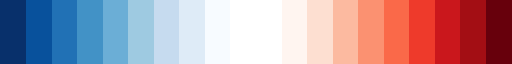

In [121]:
q_change_cmap

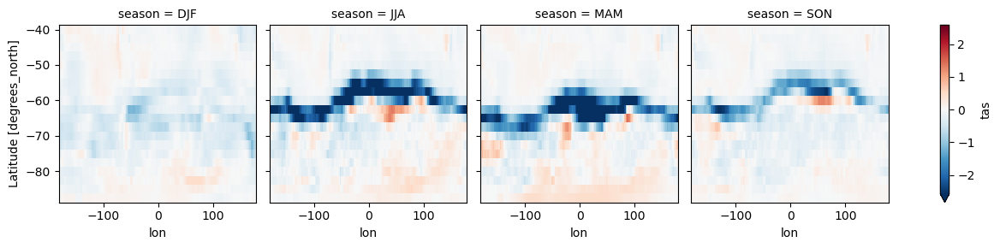

In [192]:
final_quantile_diff.sel(model='CanESM5', experiment='historical').tas.plot(col='season', robust=True)

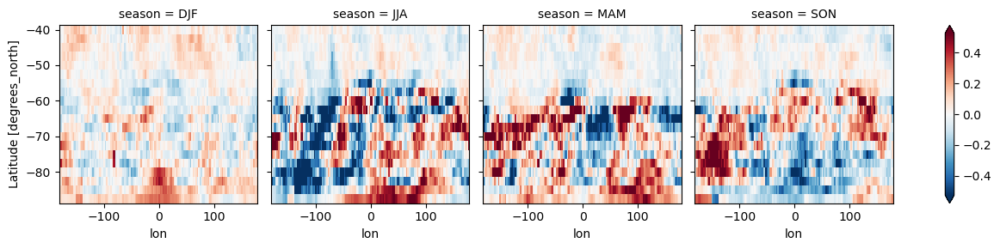

In [197]:
(final_quantile_diff.sel(model='CanESM5', experiment='historical').tas - hist_test.response).plot(col='season', robust=True)

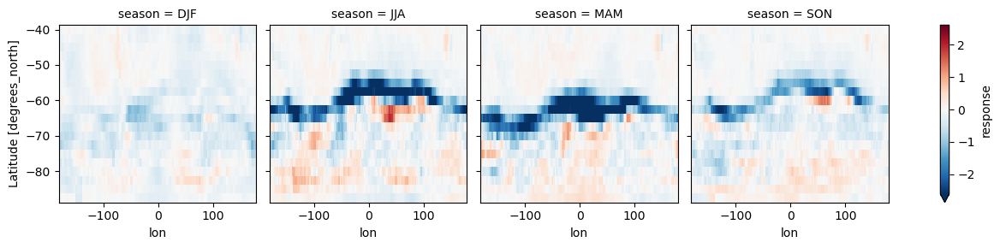

In [196]:
hist_test.response.plot(col='season', robust=True)

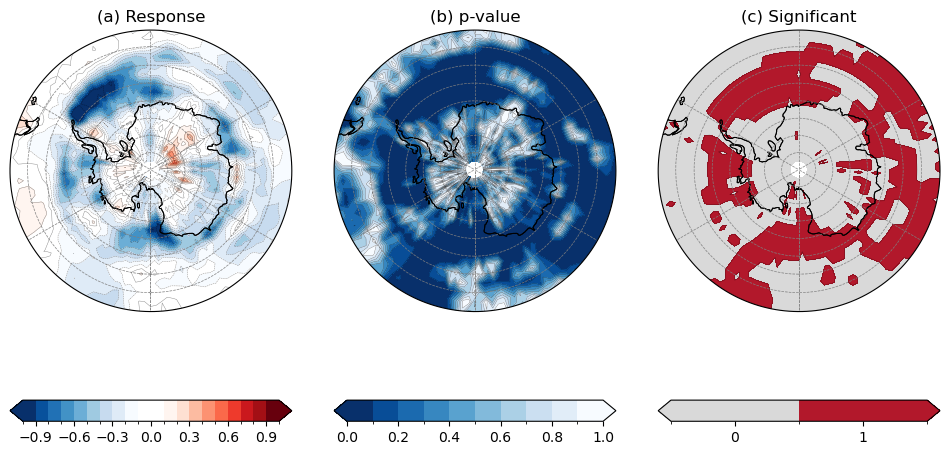

In [123]:
q_change_bounds = np.arange(-1, 1.1, 0.1)
q_change_cmap, q_change_norm = make_diverging_colormap(
    q_change_bounds, neg_cmap="Blues_r", pos_cmap="Reds", white_range=(-0.1, 0.1)
)

pvalue_bounds = np.arange(0, 1.1, 0.1)
pvalue_cmap = plt.get_cmap("Blues_r", len(pvalue_bounds) - 1)
pvalue_norm = mcolors.BoundaryNorm(pvalue_bounds, pvalue_cmap.N)

sig_bounds = [-0.5, 0.5, 1.5]
sig_cmap = mcolors.ListedColormap(["0.85", "#b2182b"])
sig_norm = mcolors.BoundaryNorm(sig_bounds, sig_cmap.N)


fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.05], hspace=0.08, wspace=0.15)

axes = [fig.add_subplot(gs[0, i], projection=ccrs.SouthPolarStereo()) for i in range(3)]
caxes = [fig.add_subplot(gs[1, i]) for i in range(3)]

axes = [maps.setup_polar_ax(ax) for ax in axes]

cf0 = maps.draw_polar_contour(
    axes[0], hist_test.isel(season=0).response,
    levels=q_change_bounds, cmap=q_change_cmap, norm=q_change_norm
)

cf1 = maps.draw_polar_contour(
    axes[1], hist_test.isel(season=0).pvalue,
    levels=pvalue_bounds, cmap=pvalue_cmap, norm=pvalue_norm
)

cf2 = maps.draw_polar_contour(
    axes[2], hist_test.isel(season=0).significant,
    levels=sig_bounds, cmap=sig_cmap, norm=sig_norm
)

axes[0].set_title("(a) Response")
axes[1].set_title("(b) p-value")
axes[2].set_title("(c) Significant")

fig.colorbar(cf0, cax=caxes[0], orientation="horizontal")
fig.colorbar(cf1, cax=caxes[1], orientation="horizontal")
fig.colorbar(cf2, cax=caxes[2], orientation="horizontal", ticks=[0, 1])

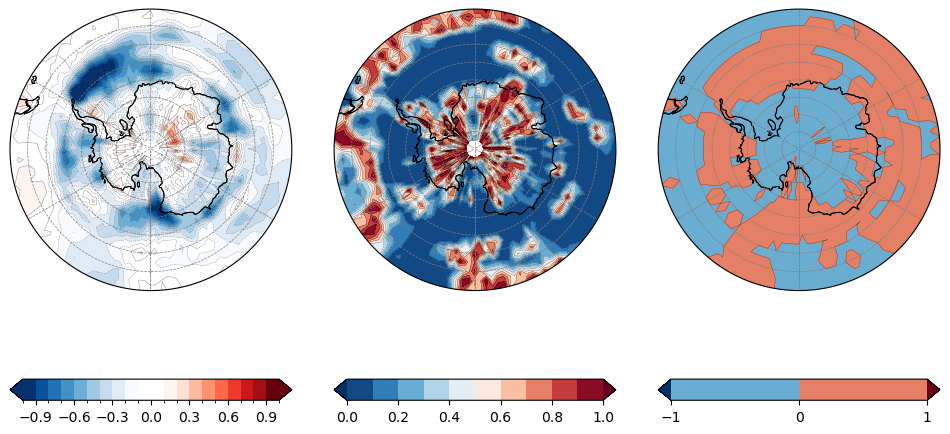

In [124]:
fig = plt.figure(figsize=(12, 6))

gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.05], hspace=0.08, wspace=0.15)

axes = [fig.add_subplot(gs[0, i], projection=ccrs.SouthPolarStereo()) for i in range(3)]
caxes = [fig.add_subplot(gs[1, i]) for i in range(3)]
axes = [maps.setup_polar_ax(ax) for ax in axes]


cf0 = maps.draw_polar_contour(
    axes[0], hist_test.isel(season=0).response,
    levels=q_change_bounds, cmap=q_change_cmap, norm=q_change_norm
)

cf1 = maps.draw_polar_contour(
    axes[1], hist_test.isel(season=0).pvalue,
    levels=np.arange(0, 1.1, 0.1)
)

cf2 = maps.draw_polar_contour(
    axes[2], hist_test.isel(season=0).significant,
    levels=np.arange(-1, 2, 1)
)

fig.colorbar(cf0, cax=caxes[0], orientation="horizontal")
fig.colorbar(cf1, cax=caxes[1], orientation="horizontal")
fig.colorbar(cf2, cax=caxes[2], orientation="horizontal")

In [125]:
hist_test

<xarray.Dataset> Size: 197kB
Dimensions:      (season: 4, lon: 144, lat: 20)
Coordinates:
  * season       (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon          (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat          (lat) float64 160B -87.5 -85.0 -82.5 ... -45.0 -42.5 -40.0
Data variables:
    response     (lat, lon, season) float64 92kB -0.07335 0.08069 ... 0.001805
    pvalue       (lat, lon, season) float64 92kB 0.6687 0.7764 ... 0.1178 0.976
    significant  (lat, lon, season) bool 12kB False False False ... False False

In [126]:
reload(maps)

<module 'plotting_modules.maps' from '/home/users/aborow/ExtAnt-initial/../extant-functions/plotting_modules/maps.py'>

In [127]:
# hist_test.response.expand_dims(experiment=['historical'])

In [129]:
reload(maps)

<module 'plotting_modules.maps' from '/home/users/aborow/ExtAnt-initial/../extant-functions/plotting_modules/maps.py'>

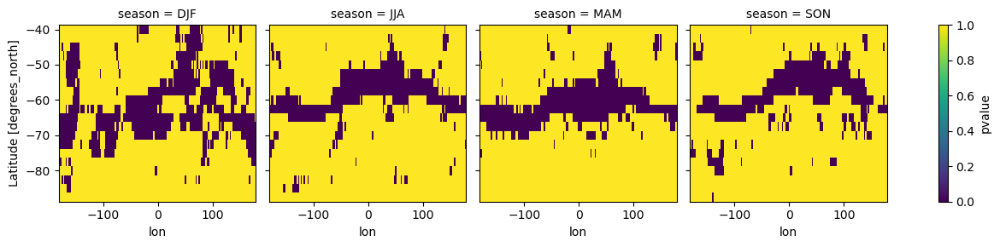

In [130]:
q_change_stipple.plot(col='season', )

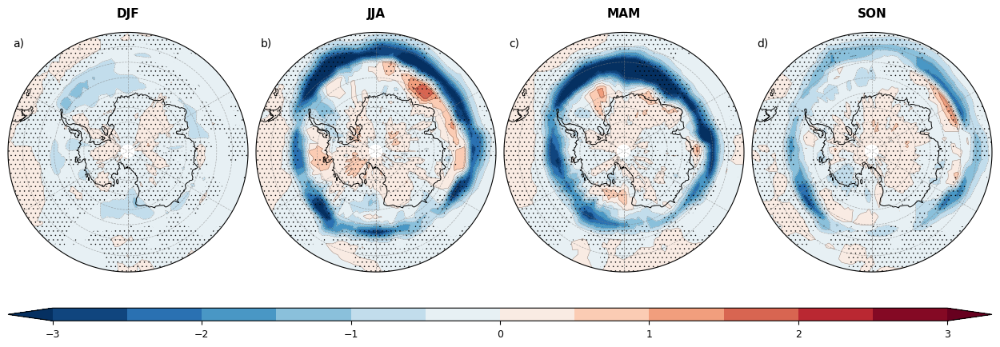

In [131]:
panels = maps.polar_grid(
    hist_test.response,
    col_dim='season',
    # row_dim='experiment',
    # levels=sn_bounds, 
    # cmap=sn_cmap,
    # cbar_label='S/N Ratio',
    # title=True
)
maps.map_panels(panels, q_change_stipple, maps.plot_hatch,
           row_dim='season', col_dim=None);

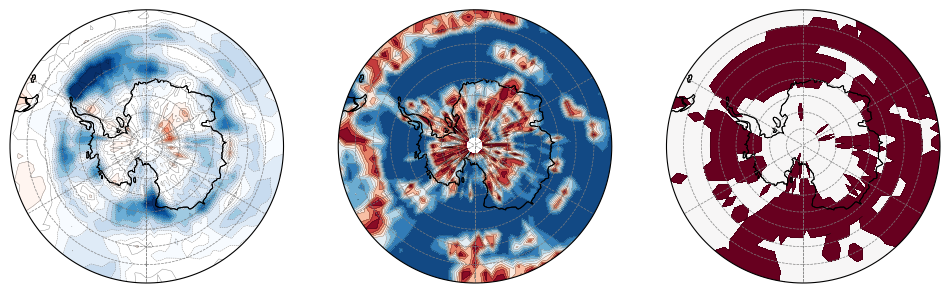

In [132]:
fig = plt.figure(figsize=(12, 6))

axes = [fig.add_subplot(1, 3, i+1, projection= ccrs.SouthPolarStereo()) for i in range(3)]

axes = [maps.setup_polar_ax(ax) for ax in axes]

maps.draw_polar_contour(axes[0], hist_test.isel(season=0).response,
                        levels=q_change_bounds, cmap=q_change_cmap, norm=q_change_norm)
maps.draw_polar_contour(axes[1], hist_test.isel(season=0).pvalue, levels=np.arange(0, 1.1, 0.1))
maps.draw_polar_contour(axes[2], hist_test.isel(season=0).significant, levels=np.arange(-1, 1, 1))

In [143]:
from matplotlib.gridspec import GridSpecFromSubplotSpec

In [144]:
def plot_permutation_example(example, result, exp_key, reference_key, bins=40,
                             exp_label=None, reference_label=None, figsize=(11, 15),
                             quantiles=(0.05, 0.95), seed=0):
    """Plot observed distributions, example permutations, and permutation null distribution."""
    exp_color = constants.FORCING_COLORS[exp_key]
    ref_color = constants.FORCING_COLORS[reference_key]

    if exp_label is None:
        exp_label = constants.FORCING_LEGEND_LABELS.get(exp_key, exp_key)
    if reference_label is None:
        reference_label = constants.FORCING_LEGEND_LABELS.get(reference_key, reference_key)

    def clean(x):
        x = np.asarray(x).ravel()
        return x[np.isfinite(x)]

    def demean(x):
        return x - x.mean()

    def qrange(x):
        q0, q1 = np.quantile(x, quantiles)
        return q1 - q0, q0, q1

    fig = plt.figure(figsize=figsize)

    # Outer layout: a -> flow -> b -> flow -> c
    outer = GridSpec(5, 1, figure=fig, height_ratios=[2.3, 0.65, 4.1, 0.65, 2.3],
                     hspace=0.55)

    ax_obs = fig.add_subplot(outer[0])
    ax_flow1 = fig.add_subplot(outer[1])
    ax_flow2 = fig.add_subplot(outer[3])
    ax_null = fig.add_subplot(outer[4])

    # Nested layout used only by panel b
    gs_b = GridSpecFromSubplotSpec(
        4, 3, subplot_spec=outer[2],
        height_ratios=[1, 1, 0.28, 1],
        hspace=0.55, wspace=0.18,
    )

    mini_axes = [
        fig.add_subplot(gs_b[0, 0]), fig.add_subplot(gs_b[0, 1]), fig.add_subplot(gs_b[0, 2]),
        fig.add_subplot(gs_b[1, 0]), fig.add_subplot(gs_b[1, 1]), fig.add_subplot(gs_b[1, 2]),
        fig.add_subplot(gs_b[3, 0]), fig.add_subplot(gs_b[3, 1]), fig.add_subplot(gs_b[3, 2]),
    ]

    ax_ellipsis = fig.add_subplot(gs_b[2, :])
    ax_ellipsis.axis("off")
    ax_ellipsis.text(0.5, 0.5, "⋯", ha="center", va="center", fontsize=24)

    exp = demean(clean(example.exp))
    ref = demean(clean(example.reference))
    pooled = example.pooled

    n_exp = example.sizes["exp_member"]
    n_ref = example.sizes["reference_member"]
    n_total = pooled.sizes["pool_member"]
    n_trials = example.sizes["trial"]

    response = float(example.response.values)
    pvalue = float(result.pvalue.values)

    # a) Observed distributions
    obs_bins = np.histogram_bin_edges(np.concatenate([exp, ref]), bins=30)

    ax_obs.hist(ref, bins=obs_bins, density=True, color=ref_color, edgecolor=ref_color,
                alpha=0.28, lw=1.4, label=reference_label)
    ax_obs.hist(exp, bins=obs_bins, density=True, color=exp_color, edgecolor=exp_color,
                alpha=0.28, lw=1.4, label=exp_label)

    _, ref_q0, ref_q1 = qrange(ref)
    _, exp_q0, exp_q1 = qrange(exp)
    ymax = ax_obs.get_ylim()[1]

    ax_obs.plot([ref_q0, ref_q1], [0.07 * ymax] * 2, color=ref_color, lw=3)
    ax_obs.plot([exp_q0, exp_q1], [0.13 * ymax] * 2, color=exp_color, lw=3)

    ax_obs.set_title("a  Observed distributions", fontsize=15, pad=10)
    ax_obs.set_xlabel("Demeaned temperature", fontsize=12)
    ax_obs.set_ylabel("Density", fontsize=12)
    ax_obs.legend(frameon=False, fontsize=10)
    ax_obs.tick_params(labelsize=11)
    ax_obs.text(0.02, 0.95, rf"$\Delta_{{obs}} = {response:.2f}$",
                transform=ax_obs.transAxes, va="top", fontsize=11)

    # flow 1
    ax_flow1.axis("off")
    ax_flow1.annotate("", xy=(0.5, 0.08), xytext=(0.5, 0.38),
                      arrowprops=dict(arrowstyle="-|>", lw=1.4))
    ax_flow1.text(0.5, 0.72,
                  f"Pool all {n_total} member trajectories,\n"
                  f"then randomly split into $n={n_exp}$ and $m={n_ref}$ members",
                  ha="center", va="center", multialignment="center", fontsize=11)

    # b) Example permutations
    rng = np.random.default_rng(seed)
    perm_labels = [1, 2, 3, 4, 5, 6, n_trials - 2, n_trials - 1, n_trials]

    permutation_samples = []
    for _ in perm_labels:
        idx = rng.permutation(n_total)
        exp_i = demean(clean(pooled.isel(pool_member=idx[:n_exp])))
        ref_i = demean(clean(pooled.isel(pool_member=idx[n_exp:])))
        permutation_samples.append((exp_i, ref_i))

    all_values = np.concatenate([x for pair in permutation_samples for x in pair])
    perm_bins = np.histogram_bin_edges(all_values, bins=14)

    ymax_perm = 0
    for exp_i, ref_i in permutation_samples:
        h_exp, _ = np.histogram(exp_i, bins=perm_bins, density=True)
        h_ref, _ = np.histogram(ref_i, bins=perm_bins, density=True)
        ymax_perm = max(ymax_perm, h_exp.max(), h_ref.max())

    for ax, label, (exp_i, ref_i) in zip(mini_axes, perm_labels, permutation_samples):
        ax.hist(ref_i, bins=perm_bins, density=True, color=ref_color,
                edgecolor=ref_color, alpha=0.28, lw=0.8)
        ax.hist(exp_i, bins=perm_bins, density=True, color=exp_color,
                edgecolor=exp_color, alpha=0.28, lw=0.8)

        ref_range, ref_q0, ref_q1 = qrange(ref_i)
        exp_range, exp_q0, exp_q1 = qrange(exp_i)
        delta = exp_range - ref_range

        ax.plot([ref_q0, ref_q1], [0.07 * ymax_perm] * 2, color=ref_color, lw=2)
        ax.plot([exp_q0, exp_q1], [0.14 * ymax_perm] * 2, color=exp_color, lw=2)

        ax.text(0.04, 0.94, f"{label:,}", transform=ax.transAxes, va="top", fontsize=8)
        ax.text(0.96, 0.94, rf"$\Delta={delta:.2f}$", transform=ax.transAxes,
                ha="right", va="top", fontsize=8)

        ax.set_xlim(perm_bins[0], perm_bins[-1])
        ax.set_ylim(0, ymax_perm * 1.08)
        ax.set_xticks([])
        ax.set_yticks([])

    mini_axes[0].set_title("b  Example permutations", fontsize=15, loc="left", pad=10)

    # flow 2
    ax_flow2.axis("off")
    ax_flow2.annotate("", xy=(0.5, 0.08), xytext=(0.5, 0.38),
                      arrowprops=dict(arrowstyle="-|>", lw=1.4))
    ax_flow2.text(0.5, 0.72,
                  f"Repeat {n_trials:,} times and calculate $\\Delta$ for each split,\n"
                  r"then compare the observed $|\Delta|$ with the permutation distribution",
                  ha="center", va="center", multialignment="center", fontsize=11)

    # c) Permutation distribution
    perm = clean(example.permutations)

    ax_null.hist(perm, bins=bins, density=True, color=ref_color, edgecolor=ref_color,
                 alpha=0.65, lw=0.8, label="Permutations")
    ax_null.axvline(response, color=exp_color, lw=2.5, ls="--", label="Observed")

    ax_null.set_title(f"c  Permutation distribution\n$p$ = {pvalue:.3f}", fontsize=15, pad=8)
    ax_null.set_xlabel("Difference in Q95–Q05 range", fontsize=12)
    ax_null.set_ylabel("Density", fontsize=12)
    ax_null.legend(frameon=False, fontsize=10)
    ax_null.tick_params(labelsize=11)

    return fig, [ax_obs, *mini_axes, ax_null]

    
# def plot_permutation_example(example, result, exp_key, reference_key, bins=40,
#                              exp_label=None, reference_label=None, figsize=(16, 5), seed=0):
#     """Plot observed distributions, example permutations, and the full null distribution."""
#     exp_color = constants.FORCING_COLORS[exp_key]
#     ref_color = constants.FORCING_COLORS[reference_key]

#     if exp_label is None:
#         exp_label = constants.FORCING_LEGEND_LABELS.get(exp_key, exp_key)
#     if reference_label is None:
#         reference_label = constants.FORCING_LEGEND_LABELS.get(reference_key, reference_key)

#     def clean(x):
#         x = np.asarray(x).ravel()
#         return x[np.isfinite(x)]

#     def demean(x):
#         return x - x.mean()

#     def qrange(x):
#         q05, q95 = np.quantile(x, [0.05, 0.95])
#         return q95 - q05, q05, q95

#     fig = plt.figure(figsize=figsize)
#     gs = GridSpec(2, 7, figure=fig, width_ratios=[1.4, 1.4, 1, 1, 0.25, 1.4, 1.4],
#                   wspace=0.45, hspace=0.18)

#     ax_obs = fig.add_subplot(gs[:, :2])
#     mini_axes = [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3]),
#                  fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]
#     ax_gap = fig.add_subplot(gs[:, 4])
#     ax_null = fig.add_subplot(gs[:, 5:])

#     # a) Observed distributions
#     exp = demean(clean(example.exp))
#     ref = demean(clean(example.reference))
#     obs_bins = np.histogram_bin_edges(np.concatenate([exp, ref]), bins=30)

#     ax_obs.hist(ref, bins=obs_bins, density=True, color=ref_color, edgecolor=ref_color,
#                 alpha=0.28, lw=1.5, label=reference_label)
#     ax_obs.hist(exp, bins=obs_bins, density=True, color=exp_color, edgecolor=exp_color,
#                 alpha=0def 
#     _, ref_q05, ref_q95 = qrange(ref)
#     _, exp_q05, exp_q95 = qrange(exp)
#     ymax = ax_obs.get_ylim()[1]

#     for q05, q95, y, color in [(ref_q05, ref_q95, 0.07 * ymax, ref_color),
#                                (exp_q05, exp_q95, 0.13 * ymax, exp_color)]:
#         ax_obs.plot([q05, q95], [y, y], color=color, lw=3, solid_capstyle="butt")
#         ax_obs.plot([q05, q95], [y, y], "|", color=color, ms=9, mew=2)

#     ax_obs.set_title("a  Observed distributions", fontsize=15, pad=10)
#     ax_obs.set_xlabel("Demeaned temperature", fontsize=12)
#     ax_obs.set_ylabel("Density", fontsize=12)
#     ax_obs.legend(frameon=False, fontsize=10)
#     ax_obs.tick_params(labelsize=11)

#     # b) A few individual permutations
#     pooled = example.pooled
#     n_exp = example.sizes["exp_member"]
#     n_total = pooled.sizes["pool_member"]
#     rng = np.random.default_rng(seed)
#     example_stats = []

#     for i, ax in enumerate(mini_axes):
#         idx = rng.permutation(n_total)
#         exp_i = demean(clean(pooled.isel(pool_member=idx[:n_exp])))
#         ref_i = demean(clean(pooled.isel(pool_member=idx[n_exp:])))
#         hist_bins = np.histogram_bin_edges(np.concatenate([exp_i, ref_i]), bins=12)

#         ax.hist(ref_i, bins=hist_bins, density=True, color=ref_color,
#                 edgecolor=ref_color, alpha=0.28, lw=0.8)
#         ax.hist(exp_i, bins=hist_bins, density=True, color=exp_color,
#                 edgecolor=exp_color, alpha=0.28, lw=0.8)

#         ref_range, ref_q05, ref_q95 = qrange(ref_i)
#         exp_range, exp_q05, exp_q95 = qrange(exp_i)
#         stat = exp_range - ref_range
#         example_stats.append(stat)

#         ymax = ax.get_ylim()[1]
#         ax.plot([ref_q05, ref_q95], [0.08 * ymax] * 2, color=ref_color, lw=2)
#         ax.plot([exp_q05, exp_q95], [0.16 * ymax] * 2, color=exp_color, lw=2)

#         ax.text(0.04, 0.94, rf"$\Delta={stat:.2f}$", transform=ax.transAxes,
#                 va="top", fontsize=8)
#         ax.set_xticks([])
#         ax.set_yticks([])

#     mini_axes[0].set_title("b  Example permutations", fontsize=13, loc="left", pad=7)

#     ax_gap.axis("off")
#     ax_gap.text(0.5, 0.5, "⋯", ha="center", va="center", fontsize=24)

#     # c) Full permutation distribution
#     perm = clean(example.permutations)
#     response = float(example.response.values)
#     pvalue = float(result.pvalue.values)

#     counts, edges = np.histogram(perm, bins=bins, density=True)
#     centres = (edges[:-1] + edges[1:]) / 2
#     widths = np.diff(edges)

#     ax_null.bar(centres, counts, width=widths, color=ref_color, edgecolor=ref_color,
#                 alpha=0.65, lw=0.8, label="Permutations")

#     for stat in example_stats:
#         ax_null.axvline(stat, color=ref_color, lw=1.2, alpha=0.65)

#     ax_null.axvline(response, color=exp_color, lw=2.5, ls="--", label="Observed")

#     ax_null.set_title(f"c  Permutation distribution\n$p$ = {pvalue:.3f}", fontsize=15, pad=6)
#     ax_null.set_xlabel("Difference in Q95–Q05 range", fontsize=12)
#     ax_null.set_ylabel("Density", fontsize=12)
#     ax_null.legend(frameon=False, fontsize=10)
#     ax_null.tick_params(labelsize=11)

#     return fig, [ax_obs, *mini_axes, ax_null]

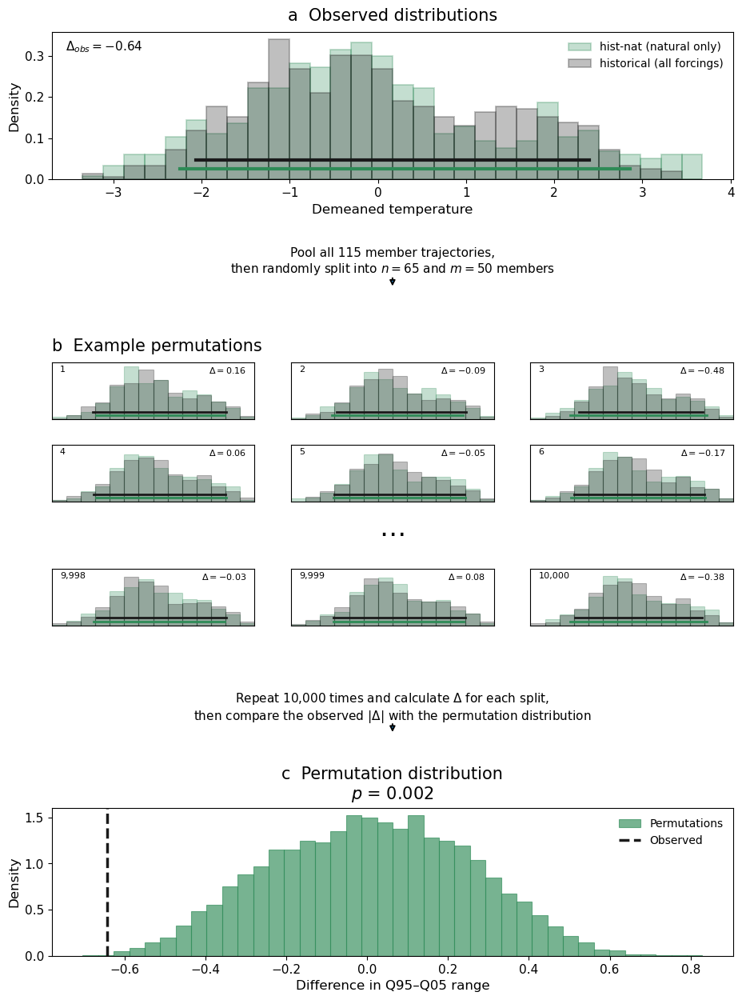

In [145]:
plot_permutation_example(example, result, 'historical', 'hist-nat', bins=40);

In [146]:
from matplotlib.gridspec import GridSpecFromSubplotSpec

In [147]:
def plot_permutation_example(example, result, exp_key, reference_key, bins=40,
                             exp_label=None, reference_label=None, figsize=(11, 15),
                             quantiles=(0.05, 0.95), seed=0):
    """Plot observed distributions, example permutations, and permutation null distribution."""
    exp_color = constants.FORCING_COLORS[exp_key]
    ref_color = constants.FORCING_COLORS[reference_key]

    if exp_label is None:
        exp_label = constants.FORCING_LEGEND_LABELS.get(exp_key, exp_key)
    if reference_label is None:
        reference_label = constants.FORCING_LEGEND_LABELS.get(reference_key, reference_key)

    def clean(x):
        x = np.asarray(x).ravel()
        return x[np.isfinite(x)]

    def demean(x):
        return x - x.mean()

    def qrange(x):
        q0, q1 = np.quantile(x, quantiles)
        return q1 - q0, q0, q1

    fig = plt.figure(figsize=figsize)

    # Outer layout: a -> flow -> b -> flow -> c
    outer = GridSpec(5, 1, figure=fig, height_ratios=[2.3, 0.65, 4.1, 0.65, 2.3],
                     hspace=0.55)

    ax_obs = fig.add_subplot(outer[0])
    ax_flow1 = fig.add_subplot(outer[1])
    ax_flow2 = fig.add_subplot(outer[3])
    ax_null = fig.add_subplot(outer[4])

    # Nested layout used only by panel b
    gs_b = GridSpecFromSubplotSpec(
        4, 3, subplot_spec=outer[2],
        height_ratios=[1, 1, 0.28, 1],
        hspace=0.55, wspace=0.18,
    )

    mini_axes = [
        fig.add_subplot(gs_b[0, 0]), fig.add_subplot(gs_b[0, 1]), fig.add_subplot(gs_b[0, 2]),
        fig.add_subplot(gs_b[1, 0]), fig.add_subplot(gs_b[1, 1]), fig.add_subplot(gs_b[1, 2]),
        fig.add_subplot(gs_b[3, 0]), fig.add_subplot(gs_b[3, 1]), fig.add_subplot(gs_b[3, 2]),
    ]

    ax_ellipsis = fig.add_subplot(gs_b[2, :])
    ax_ellipsis.axis("off")
    ax_ellipsis.text(0.5, 0.5, "⋯", ha="center", va="center", fontsize=24)

    exp = demean(clean(example.exp))
    ref = demean(clean(example.reference))
    pooled = example.pooled

    n_exp = example.sizes["exp_member"]
    n_ref = example.sizes["reference_member"]
    n_total = pooled.sizes["pool_member"]
    n_trials = example.sizes["trial"]

    response = float(example.response.values)
    pvalue = float(result.pvalue.values)

    # a) Observed distributions
    obs_bins = np.histogram_bin_edges(np.concatenate([exp, ref]), bins=30)

    ax_obs.hist(ref, bins=obs_bins, density=True, color=ref_color, edgecolor=ref_color,
                alpha=0.28, lw=1.4, label=reference_label)
    ax_obs.hist(exp, bins=obs_bins, density=True, color=exp_color, edgecolor=exp_color,
                alpha=0.28, lw=1.4, label=exp_label)

    _, ref_q0, ref_q1 = qrange(ref)
    _, exp_q0, exp_q1 = qrange(exp)
    ymax = ax_obs.get_ylim()[1]

    ax_obs.plot([ref_q0, ref_q1], [0.07 * ymax] * 2, color=ref_color, lw=3)
    ax_obs.plot([exp_q0, exp_q1], [0.13 * ymax] * 2, color=exp_color, lw=3)

    ax_obs.set_title("a  Observed distributions", fontsize=15, pad=10)
    ax_obs.set_xlabel("Demeaned temperature", fontsize=12)
    ax_obs.set_ylabel("Density", fontsize=12)
    ax_obs.legend(frameon=False, fontsize=10)
    ax_obs.tick_params(labelsize=11)
    ax_obs.text(0.02, 0.95, rf"$\Delta_{{obs}} = {response:.2f}$",
                transform=ax_obs.transAxes, va="top", fontsize=11)

    # flow 1
    ax_flow1.axis("off")
    ax_flow1.annotate("", xy=(0.5, 0.08), xytext=(0.5, 0.38),
                      arrowprops=dict(arrowstyle="-|>", lw=1.4))
    ax_flow1.text(0.5, 0.72,
                  f"Pool all {n_total} member trajectories,\n"
                  f"then randomly split into $n={n_exp}$ and $m={n_ref}$ members",
                  ha="center", va="center", multialignment="center", fontsize=11)

    # b) Example permutations
    rng = np.random.default_rng(seed)
    perm_labels = [1, 2, 3, 4, 5, 6, n_trials - 2, n_trials - 1, n_trials]

    permutation_samples = []
    for _ in perm_labels:
        idx = rng.permutation(n_total)
        exp_i = demean(clean(pooled.isel(pool_member=idx[:n_exp])))
        ref_i = demean(clean(pooled.isel(pool_member=idx[n_exp:])))
        permutation_samples.append((exp_i, ref_i))

    all_values = np.concatenate([x for pair in permutation_samples for x in pair])
    perm_bins = np.histogram_bin_edges(all_values, bins=14)

    ymax_perm = 0
    for exp_i, ref_i in permutation_samples:
        h_exp, _ = np.histogram(exp_i, bins=perm_bins, density=True)
        h_ref, _ = np.histogram(ref_i, bins=perm_bins, density=True)
        ymax_perm = max(ymax_perm, h_exp.max(), h_ref.max())

    for ax, label, (exp_i, ref_i) in zip(mini_axes, perm_labels, permutation_samples):
        ax.hist(ref_i, bins=perm_bins, density=True, color=ref_color,
                edgecolor=ref_color, alpha=0.28, lw=0.8)
        ax.hist(exp_i, bins=perm_bins, density=True, color=exp_color,
                edgecolor=exp_color, alpha=0.28, lw=0.8)

        ref_range, ref_q0, ref_q1 = qrange(ref_i)
        exp_range, exp_q0, exp_q1 = qrange(exp_i)
        delta = exp_range - ref_range

        ax.plot([ref_q0, ref_q1], [0.07 * ymax_perm] * 2, color=ref_color, lw=2)
        ax.plot([exp_q0, exp_q1], [0.14 * ymax_perm] * 2, color=exp_color, lw=2)

        ax.text(0.04, 0.94, f"{label:,}", transform=ax.transAxes, va="top", fontsize=8)
        ax.text(0.96, 0.94, rf"$\Delta={delta:.2f}$", transform=ax.transAxes,
                ha="right", va="top", fontsize=8)

        ax.set_xlim(perm_bins[0], perm_bins[-1])
        ax.set_ylim(0, ymax_perm * 1.08)
        ax.set_xticks([])
        ax.set_yticks([])

    mini_axes[0].set_title("b  Example permutations", fontsize=15, loc="left", pad=10)

    # flow 2
    ax_flow2.axis("off")
    ax_flow2.annotate("", xy=(0.5, 0.08), xytext=(0.5, 0.38),
                      arrowprops=dict(arrowstyle="-|>", lw=1.4))
    ax_flow2.text(0.5, 0.72,
                  f"Repeat {n_trials:,} times and calculate $\\Delta$ for each split,\n"
                  r"then compare the observed $|\Delta|$ with the permutation distribution",
                  ha="center", va="center", multialignment="center", fontsize=11)

    # c) Permutation distribution
    perm = clean(example.permutations)

    ax_null.hist(perm, bins=bins, density=True, color=ref_color, edgecolor=ref_color,
                 alpha=0.65, lw=0.8, label="Permutations")
    ax_null.axvline(response, color=exp_color, lw=2.5, ls="--", label="Observed")

    ax_null.set_title(f"c  Permutation distribution\n$p$ = {pvalue:.3f}", fontsize=15, pad=8)
    ax_null.set_xlabel("Difference in Q95–Q05 range", fontsize=12)
    ax_null.set_ylabel("Density", fontsize=12)
    ax_null.legend(frameon=False, fontsize=10)
    ax_null.tick_params(labelsize=11)

    return fig, [ax_obs, *mini_axes, ax_null]

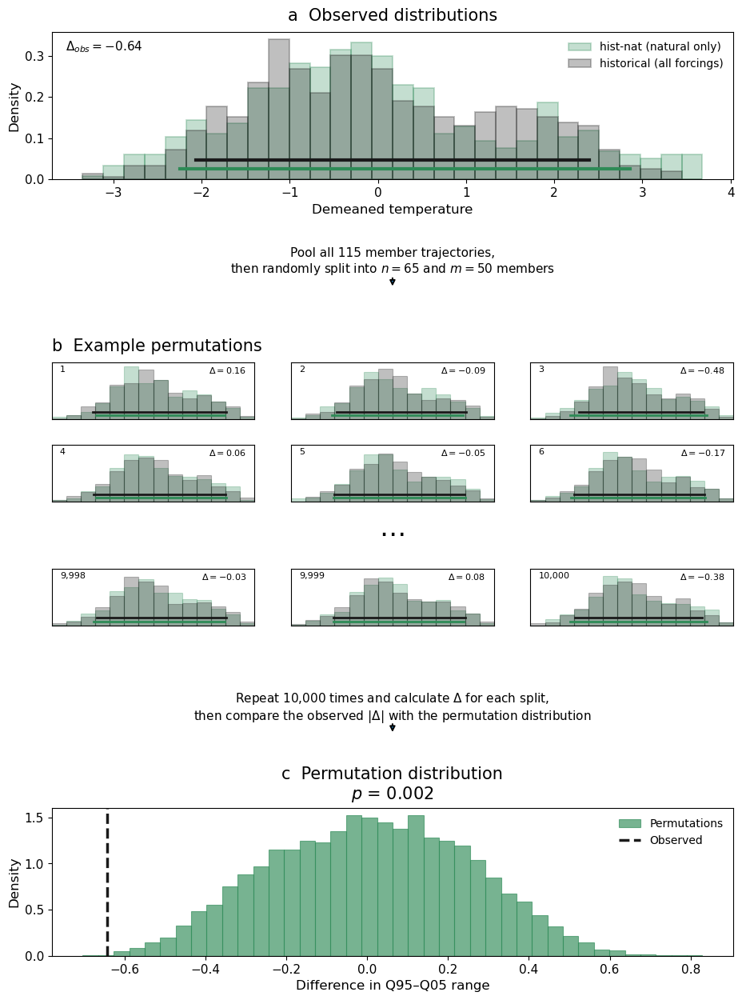

In [148]:
plot_permutation_example(example, result, 'historical', 'hist-nat', bins=40);

# ToE Methods

### Functions

In [113]:
from scipy.ndimage import gaussian_filter1d


In [115]:
import xarray_calc
@skip_empty
def rolling_seasonal_mean(da):
    da = da.resample(time='QS-DEC').mean()
    da = xarray_calc.split_time(da, ('year', 'season'), 'time')
    return da

In [116]:
def return_statistical_pvalue(arr1, arr2, stats_test):
    """
    Calculate the p-value for a given statistical test for two arrays.

    Parameters:
    arr1 (numpy array): The first input array.
    arr2 (numpy array): The second input array.

    Returns:
    float: The p-value of the specified statistical test.

    Notes:
    If either array contains only NaN values, the function returns NaN.
    """
    # Check if all values are nan
    if np.all(np.isnan(arr1)) or np.all(np.isnan(arr2)): return np.nan
    arr1, arr2 = remove_nans(arr1, arr2)

    return stats_test(arr1, arr2).pvalue

In [117]:
# from scipy.special import stdtr

# @skip_empty
# def ttest_welch(
#     ds1: xr.Dataset,
#     ds2: xr.Dataset,
#     dims: tuple[str, ...] = ("year", "member"),
# ) -> xr.Dataset:
#     """
#     Perform a Welch's t-test across specified dimensions.

#     Parameters
#     ----------
#     ds1 (xr.Dataset): First distribution.
#     ds2 (xr.Dataset): Second distribution.
#     dims (tuple[str, ...]): Dimensions to reduce over.

#     Returns
#     -------
#     xr.Dataset: T-statistic and two-sided p-value.
#     """
#     n1 = np.prod([ds1.sizes[d] for d in dims])
#     n2 = np.prod([ds2.sizes[d] for d in dims])

#     m1, m2 = ds1.mean(dims), ds2.mean(dims)
#     v1, v2 = ds1.var(dims, ddof=1), ds2.var(dims, ddof=1)

#     se2 = v1 / n1 + v2 / n2
#     t = (m1 - m2) / np.sqrt(se2)

#     df = se2**2 / (
#         (v1 / n1) ** 2 / (n1 - 1)
#         + (v2 / n2) ** 2 / (n2 - 1)
#     )

#     p = 2 * stdtr(df, -abs(t))

#     name = list(t)[0]
#     return xr.Dataset({
#         "t": t[name],
#         "p": p[name],
#     })

In [118]:
import scipy.special

@skip_empty
def ttest_welch(
    da1: xr.Dataset,
    da2: xr.Dataset,
    dims: tuple[str, ...] = ("year", "member"),
) -> xr.Dataset:
    """Perform a Welch's t-test across specified dimensions."""
    n1 = np.prod([da1.sizes[d] for d in dims])
    n2 = np.prod([da2.sizes[d] for d in dims])

    m1, m2 = da1.mean(dims), da2.mean(dims)
    v1, v2 = da1.var(dims, ddof=1), da2.var(dims, ddof=1)

    se2 = v1 / n1 + v2 / n2
    t = (m1 - m2) / np.sqrt(se2)

    df = se2**2 / (
        (v1 / n1) ** 2 / (n1 - 1)
        + (v2 / n2) ** 2 / (n2 - 1)
    )

    p = 2 * scipy.special.stdtr(df, -np.abs(t))

    return xr.Dataset({
        "t": t["tas"],
        "p": p["tas"],
    })

### T-test

In [119]:
lesfmip_season_tree['CanESM5']['hist-nat'].dataset.isel(year=slice(0, 20))

<xarray.Dataset> Size: 46MB
Dimensions:  (member: 50, lat: 20, lon: 144, year: 20, season: 4)
Coordinates:
  * year     (year) int64 160B 1850 1851 1852 1853 1854 ... 1866 1867 1868 1869
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height   float64 8B 2.0
Data variables:
    tas      (member, lat, lon, year, season) float32 46MB dask.array<chunksize=(50, 4, 144, 20, 4), meta=np.ndarray>

In [120]:
# da1 = lesfmip_season_tree['CanESM5']['hist-nat'].dataset.isel(year=slice(0, 20))
# da2 = lesfmip_season_tree['CanESM5']['historical'].dataset.isel(year=slice(0, 20))

In [121]:
# out = ttest_welch(
#     lesfmip_season_tree['CanESM5']['hist-nat'].dataset.isel(year=slice(-11, None)),
#     lesfmip_season_tree['CanESM5']['historical'].dataset.isel(year=slice(-11, None)),
#     dims= ("year", "member")

# ).compute()

In [122]:
# out.isel().t.plot(col='season')

In [123]:
# out.isel(season=0).p.plot()

In [124]:
# ttest_da = xr.map_over_datasets(
#     ttest_welch,
#     lesfmip_season_tree['CanESM5'].isel(year=slice(-11, None)),
#     lesfmip_season_tree['CanESM5']['hist-nat'].dataset.isel(year=slice(-11, None)),
#     kwargs={"dims": ("year", "member")}
# )

In [125]:
ttest_tree = xr.DataTree.from_dict({model: xr.map_over_datasets(
    ttest_welch,
    lesfmip_season_tree[model].isel(year=slice(-11, None)),
    lesfmip_season_tree[model]['hist-nat'].dataset.isel(year=slice(-11, None)),
    kwargs={"dims": ("year", "member")}
) for model in lesfmip_season_tree}).compute()

In [126]:
ttest_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (season: 4, lon: 144, lat: 20)
│   │       Coordinates:
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           t        (lat, lon, season) float64 92kB 48.69 23.38 34.12 ... 55.18 55.89
│   │           p        (lat, lon, season) float64 92kB 1.845e-276 2.209e-98 ... 3.953e-323
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (season: 4, lon: 144, lat: 20)
│   │       Coordinates:
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           t        (lat, lon, season) float64 92kB -9.063 -5.981 ... -19.69 -18.39
│   │           p        (lat, lon, season) float64 92kB 1.392e-18 3.473e-09 ... 1.41e-61
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (season: 4, lon: 144, lat: 20)
│   │       Coordinates:
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           t        (lat, lon, season) float64 92kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
│   │           p        (lat, lon, season) float64 92kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (season: 4, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           t        (lat, lon, season) float64 92kB 1.92 1.242 5.4 ... 3.293 2.371
│   │           p        (lat, lon, season) float64 92kB 0.05669 0.2163 ... 0.001212 0.01887
│   └── Group: /CanESM5/historical
│           Dimensions:  (season: 4, lon: 144, lat: 20)
│           Coordinates:
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B 2.0
│           Data variables:
│               t        (lat, lon, season) float64 92kB 39.72 17.05 32.08 ... 46.29 43.38
│               p        (lat, lon, season) float64 92kB 2.29e-219 1.762e-58 ... 4.587e-246
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (season: 4, lon: 144, lat: 20)
│   │       Coordinates:
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           t        (lat, lon, season) float64 92kB 23.01 22.21 21.83 ... 33.83 34.22
│   │           p        (lat, lon, season) float64 92kB 5.236e-80 1.78e-74 ... 9.993e-127
│   ├── Group: /GISS-E2-1-G/hist-aer
│   │       Dimensions:  (season: 4, lon: 144, lat: 20)
│   │       Coordinates:
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177

In [127]:
ttest_ds = xarray_datatree_utils.tree_to_dataset(ttest_tree, dims=['model', 'experiment'])

In [128]:
ttest_ds

<xarray.Dataset> Size: 6MB
Dimensions:     (model: 6, experiment: 5, lat: 20, lon: 144, season: 4)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height      (model, experiment) float64 240B 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0
Data variables:
    t           (lat, lon, season, model, experiment) float64 3MB 48.69 ... 1...
    p           (lat, lon, season, model, experiment) float64 3MB 1.845e-276 ...

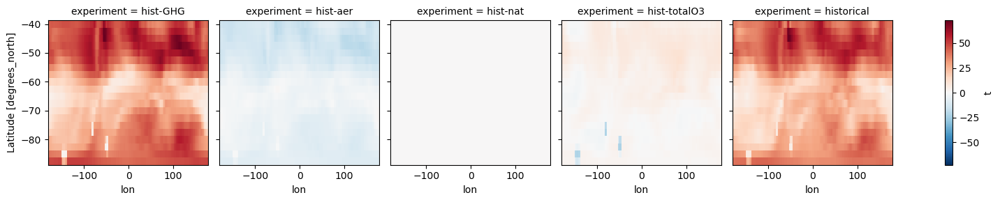

In [129]:
ttest_ds.isel(season=0, model=0).t.plot(col='experiment')

### S/N Ratio

In [130]:
lesfmip_season_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (year: 165, season: 4, lon: 144, member: 50, lat: 20)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 380MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (year: 165, season: 4, lon: 144, member: 30, lat: 20)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 228MB dask.array<chunksize=(30, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (year: 165, season: 4, lon: 144, member: 50, lat: 20)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 380MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (year: 165, season: 4, lat: 20, lon: 144, member: 10)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 76MB dask.array<chunksize=(10, 4, 144, 164, 4), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (year: 165, season: 4, lon: 144, member: 65, lat: 20)
│           Coordinates:
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B 2.0
│           Data variables:
│               tas      (member, lat, lon, year, season) float64 988MB dask.array<chunksize=(65, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (year: 165, season: 4, member: 45, lon: 144, lat: 20)


In [131]:
base_mean = lesfmip_season_tree.mean(dim=['year', 'member'])#.persist()
# wait(base_mean);

In [132]:
lesfmip_tree_seasonal_anom = lesfmip_season_tree - base_mean

In [133]:
lesfmip_tree_mm_signal = lesfmip_tree_seasonal_anom.mean(dim='member')
lesfmip_tree_mm_signal = lesfmip_tree_mm_signal.map_over_datasets(skip_empty(lowess_xarray), kwargs=dict(core_dims='year')).persist()
wait(lesfmip_tree_mm_signal);

In [134]:
lesfmip_tree_mm_signal

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (lat: 20, lon: 144, season: 4, year: 165)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (lat, lon, year, season) float64 15MB dask.array<chunksize=(4, 144, 165, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (lat: 20, lon: 144, season: 4, year: 165)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (lat, lon, year, season) float64 15MB dask.array<chunksize=(4, 144, 165, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (lat: 20, lon: 144, season: 4, year: 165)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (lat, lon, year, season) float64 15MB dask.array<chunksize=(4, 144, 165, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (lat: 20, lon: 144, season: 4, year: 165)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (lat, lon, year, season) float64 15MB dask.array<chunksize=(4, 144, 165, 4), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (lat: 20, lon: 144, season: 4, year: 165)
│           Coordinates:
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B 2.0
│           Data variables:
│               tas      (lat, lon, year, season) float64 15MB dask.array<chunksize=(4, 144, 165, 4), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (lat: 20, lon: 144, season: 4, year: 165)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (lat, lon, year, season) float64 15MB dask.array<chunksize=(4, 144, 165, 4), meta=np.ndarray>
│   ├──

In [135]:
lesfmip_detrend = (lesfmip_tree_seasonal_anom - lesfmip_tree_mm_signal).persist()
wait(lesfmip_detrend);

In [136]:
lesfmip_tree_seasonal_noise = lesfmip_season_tree.match('*/hist-nat').std(dim=['member', 'year'])
lesfmip_tree_seasonal_noise = xr.DataTree.from_dict({key: branch['hist-nat'] for key, branch in lesfmip_season_tree.items()}).std(dim=['member', 'year'])#.persist()
# wait(lesfmip_tree_seasonal_noise);

In [137]:
lesfmip_experiment_noise = lesfmip_detrend.map_over_datasets(rolling_std)

In [138]:
lesfmip_experiment_noise_da = xarray_datatree_utils.tree_to_dataset(
    lesfmip_experiment_noise, dims=['model', 'experiment']).drop_vars('height')#.persist()
# wait(lesfmip_experiment_noise_da);

In [139]:
lesfmip_experiment_noise_da

<xarray.Dataset> Size: 456MB
Dimensions:     (model: 6, experiment: 5, lat: 20, lon: 144, year: 165,
                 season: 4)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
Data variables:
    tas         (lat, lon, year, season, model, experiment) float64 456MB dask.array<chunksize=(2, 72, 159, 2, 1, 1), meta=np.ndarray>

In [140]:
# lesfmip_experiment_noise_da = xr.concat(
#     [
#         xarray_datatree_utils.to_dataset(branch, concat_dim='experiment').assign_coords(model=model) for model, branch in lesfmip_experiment_noise.items()
#     ], dim='model')

In [141]:
ALL_BUT_HISTNAT = [str(exp) for exp in lesfmip_experiment_noise_da.experiment.values if exp != 'hist-nat']
ALL_BUT_HISTNAT

['hist-GHG', 'hist-aer', 'hist-totalO3', 'historical']

In [142]:
lesfmip_noise_da = np.sqrt(
    1/2 * (
        lesfmip_experiment_noise_da.sel(experiment='hist-nat')**2 + lesfmip_experiment_noise_da**2
    )
).persist()
wait(lesfmip_noise_da);

In [143]:
lesfmip_mm_signal_da = xarray_datatree_utils.tree_to_dataset(
    lesfmip_tree_mm_signal, dims=['model', 'experiment']).drop_vars('height')

In [144]:
lesfmip_mm_signal_da

<xarray.Dataset> Size: 456MB
Dimensions:     (model: 6, experiment: 5, lat: 20, lon: 144, year: 165,
                 season: 4)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
Data variables:
    tas         (lat, lon, year, season, model, experiment) float64 456MB dask.array<chunksize=(4, 144, 165, 4, 1, 1), meta=np.ndarray>

In [145]:
# lesfmip_mm_signal_da = xr.concat(
#     [
#         xarray_datatree_utils.to_dataset(branch, concat_dim='experiment').assign_coords(model=model)
#         for model, branch in lesfmip_tree_mm_signal.items()
#     ], dim='model')

In [146]:
# lesfmip_seasonal_sn_da = lesfmip_seasonal_sn_da.compute()
lesfmip_mm_signal_da = lesfmip_mm_signal_da.compute()
lesfmip_noise_da = lesfmip_noise_da.compute()

In [147]:
lesfmip_seasonal_sn_da = lesfmip_mm_signal_da/lesfmip_experiment_noise_da

In [148]:
%%time
#(t): Computing S/N
#(c): This is REALlY SLOW
lesfmip_seasonal_sn_da = lesfmip_seasonal_sn_da.compute()

CPU times: user 361 ms, sys: 2.33 s, total: 2.69 s
Wall time: 1min 45s


In [149]:
# reload(xarray_datatree_utils)

In [150]:
# lesfmip_experiment_noise.map_over_datasets(xarray_datatree_utils.to_dataset, kwargs={'concat_dim': 'experiment'})

In [151]:
# lesfmip_experiment_noise + xarray_datatree_utils.take_level(lesfmip_experiment_noise, 'hist-nat')

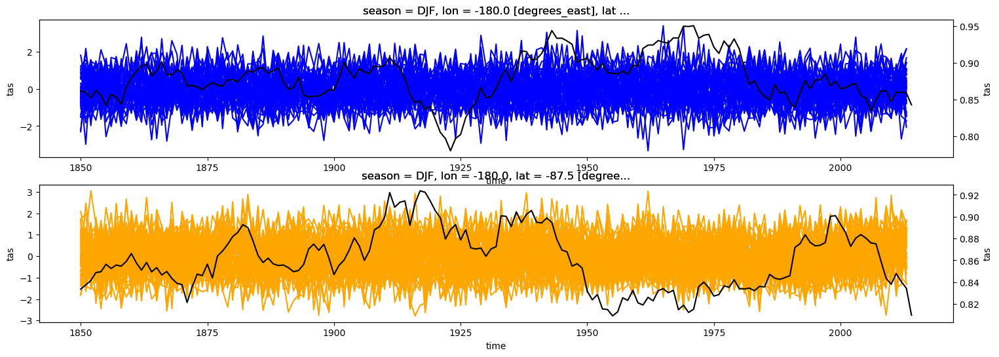

In [152]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 6))

ax1_twinx = ax1.twinx()
ax2_twinx = ax2.twinx()

lesfmip_detrend['CanESM5']['hist-nat'].isel(season=0, lat=0, lon=0).tas.plot(ax=ax1, hue='member', color='blue', add_legend=False);
lesfmip_detrend['CanESM5']['historical'].isel(season=0, lat=0, lon=0).tas.plot(ax=ax2, hue='member', color='orange', add_legend=False);

lesfmip_experiment_noise['CanESM5']['hist-nat'].isel(season=0, lat=0, lon=0).tas.plot(ax=ax1_twinx, label='histnat', color='black')
lesfmip_experiment_noise['CanESM5']['historical'].isel(season=0, lat=0, lon=0).tas.plot(ax=ax2_twinx, label='hist', color='black')

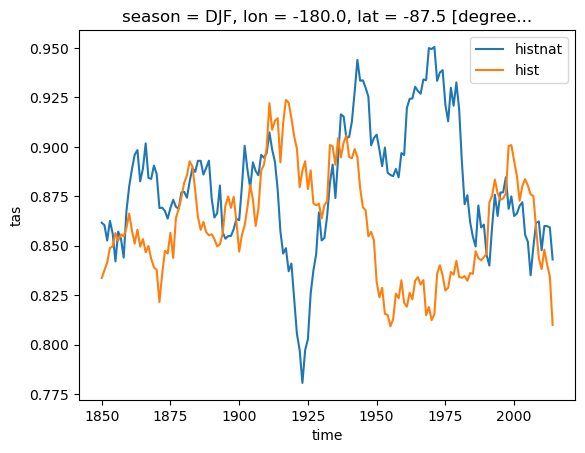

In [153]:
lesfmip_experiment_noise['CanESM5']['hist-nat'].isel(season=0, lat=0, lon=0).tas.plot(label='histnat')
lesfmip_experiment_noise['CanESM5']['historical'].isel(season=0, lat=0, lon=0).tas.plot(label='hist')
plt.legend()

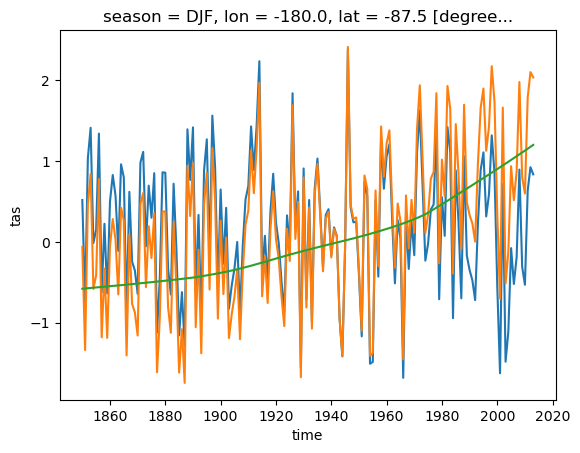

In [154]:
lesfmip_detrend['CanESM5']['historical'].isel(season=0, lat=0, lon=0, member=0).tas.plot()
lesfmip_tree_seasonal_anom['CanESM5']['historical'].isel(season=0, lat=0, lon=0, member=0).tas.plot()
lesfmip_tree_mm_signal['CanESM5']['historical'].isel(season=0, lat=0, lon=0).tas.plot()

In [155]:
# lesfmip_tree_seasonal_sn =xr.DataTree.from_dict({key: lesfmip_tree_mm_signal[key]/lesfmip_tree_seasonal_noise[key].tas for key in lesfmip_tree_mm_signal.keys()})

In [156]:
# lesfmip_tree_seasonal_sn = lesfmip_tree_seasonal_sn.compute()

In [157]:
# lesfmip_seasonal_sn_da.sel(model='CanESM5').tas.isel(season=0, year=-10).plot(col='experiment')

In [158]:
# xarray_datatree_utils.to_dataset(lesfmip_tree_seasonal_sn['CanESM5'], concat_dim='experiment').isel(season=0, year=-10).plot(col='experiment')

## Fraction per protocal

In [159]:
ALL_BUT_HISTORICAL = ['hist-GHG', 'hist-aer', 'hist-nat', 'hist-totalO3']

In [160]:
lesfmip_change_quantile_da

<xarray.Dataset> Size: 3GB
Dimensions:     (model: 6, experiment: 5, year: 165, season: 4, lon: 144,
                 lat: 20, quantile: 7)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height      (model, experiment) float64 240B 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0
  * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
Data variables:
    tas         (lat, lon, season, quantile, year, model, experiment) float64 3GB ...

In [161]:
fraction_of_historical = (
    lesfmip_change_quantile_da.sel(quantile=0.5, experiment=ALL_BUT_HISTORICAL)
    /lesfmip_change_quantile_da.sel(quantile=0.5).sel(experiment='historical')
).tas

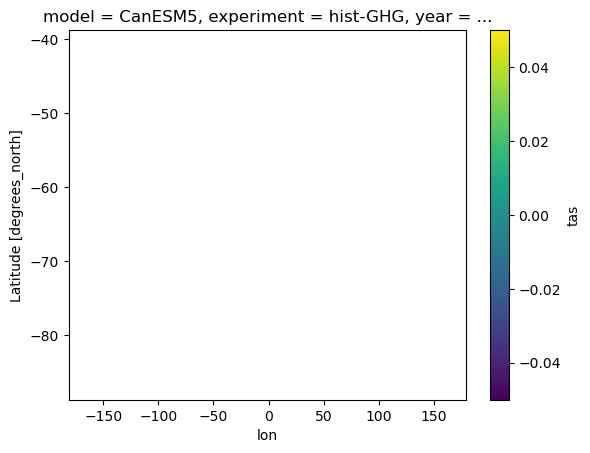

In [162]:
(100*fraction_of_historical).isel(model=0, experiment=0, year=-5, season=0).plot(robust=True)

In [163]:
sum_all_but_historical = (lesfmip_change_quantile_da
    .sel(quantile=0.5)
    .sel(experiment=ALL_BUT_HISTORICAL)
    .sum(dim='experiment')).tas

# sum_all_but_historical = xr.concat([ds.tas.assign_coords(model=model) for model, ds in sum_all_but_historical.items()], dim='model')

In [164]:
fraction_sum_all_but_historical = sum_all_but_historical/lesfmip_change_quantile_da.sel(quantile=0.5).sel(experiment='historical').tas

In [165]:
sum_all_but_historical

<xarray.DataArray 'tas' (lat: 20, lon: 144, season: 4, year: 165, model: 6)> Size: 91MB
0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
Coordinates:
  * model     (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * year      (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * season    (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon       (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat       (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    quantile  float64 8B 0.5

# Bootstrapping

## General

In [ ]:
# QUANTILE_PAIRS = {
#     80: {"upper": 0.9, "lower": 0.1},
#     90: {"upper": 0.95, "lower": 0.05},
#     98: {"upper": 0.99, "lower": 0.01},
# }


# def xarray_calc.quantile_ranges(da, pairs=QUANTILE_PAIRS, dim="qrange"):
#     """Compute the spread between symmetric quantile pairs.
#     Parameters
#     ----------
#     da : xarray.DataArray
#         Array with a `quantile` dimension containing the required levels.
#     pairs : dict, optional
#         Mapping of range label to a dict with `upper` and `lower` quantiles.
#     dim : str, optional
#         Name of the new dimension holding the range labels.
#     Returns
#     -------
#     xarray.DataArray
#         Ranges stacked along `dim`, with `quantile` removed.
#     """
#     ranges = []
#     for label, cfg in pairs.items():
#         upper = da.sel(quantile=cfg["upper"])
#         lower = da.sel(quantile=cfg["lower"])
#         ranges.append(upper - lower)
#     return xr.concat(ranges, dim=xr.DataArray(list(pairs), dims=dim, name=dim))

In [ ]:
QUANTILES

In [ ]:
PLOT_QUANTILES

In [ ]:
rng = np.random.default_rng()

## All

In [ ]:
tda = lesfmip_tree['MIROC6']['historical'].tas#.isel(lat=slice(0, 5), lon=slice(0, 5))#.sel(**latlon).tas
tda = tda.sel(time=tda.time.dt.month==12) # Is seasonal, so this is summer not December
tda.sizes

In [ ]:
# Only need last 11 years, not entire rolling
tda = tda.isel(time=slice(-21, None))

In [ ]:
# tda_histnat = lesfmip_tree['MIROC6']['hist-nat'].tas.isel(lat=slice(0, 5), lon=slice(0, 5))#.sel(**latlon).tas
# tda_histnat = tda_histnat.sel(time=tda_histnat.time.dt.month==12)

In [ ]:
n_samples = 10
n_trials = 10000
# random_indexes = np.random.randint(0, tda.sizes['member'], (n_trials, n_samples))
random_indexes = np.argsort(rng.random((n_trials, tda.sizes['member'])), axis=1)[:, :n_samples]
# random_indexes[:3]
random_indexes.shape

idx_da = xr.DataArray(random_indexes, dims=('trial', 'member'))

In [ ]:
random_member_da = tda.isel(member=idx_da)

In [ ]:
da_q = tda.quantile(QUANTILES, dim=['time', 'member']).compute()

In [ ]:
da_random_q = random_member_da.quantile(QUANTILES, dim=['time', 'member']).compute()

In [ ]:
fig, ax = plt.subplots()
bins = np.arange(-20, -19, 0.01)
da_random_q.isel(lat=0, lon=0).sel(quantile=0.5).plot.hist(ax=ax, bins=bins);
ax.axvline(da_q.isel(lat=0, lon=0).sel(quantile=0.5).values.item(), color='red')
ax.axvline(da_random_q.isel(lat=0, lon=0).sel(quantile=0.5).mean(dim='trial').values.item(), color='orange')

In [ ]:
da_random_q

In [ ]:
random_mean = da_random_q.mean(dim='trial')
random_std = da_random_q.std(dim='trial')

In [ ]:
cohens_d = (da_q - random_mean) / random_std
cohens_d

In [ ]:
da_random_q

In [ ]:
# Quantile ranges (e.g. the 90th - 10th percentile)
da_random_q_range_q = xarray_calc.quantile_ranges(da_random_q)
da_q_range_q = xarray_calc.quantile_ranges(da_q)

# Calculate the percent uncertainty
percent_range_q_std = da_random_q_range_q.std(dim='trial')
# Convert to percent, then  multiple by 2 for twice standard deviation
percent_range_q_uncertainty_percent = 100 * (2 * percent_range_q_std) / da_q_range_q
# percent_range_q_uncertainty = percent_range_q_uncertainty*2

In [ ]:
da_q_range_q

In [ ]:
fig = plt.figure(figsize=(13, 17))

outer_gs = fig.add_gridspec(4, 1, hspace=0.1)

row_labels = [
    'Full-ensemble\nestimate',
    'Bootstrapped\nuncertainty (2σ)',
    'Bootstrapped\nuncertainty (%)',
    ''
]

axes_maps = []
caxes = []

for row in range(3):
    gs = outer_gs[row].subgridspec(
        # 2, 4,
        1, 5,
        # width_ratios=[0.9, 3, 3, 3], height_ratios=[1, 0.08],
        width_ratios=[0.9, 3, 3, 3, 0.24],
        # height_ratios=[1, 0.08],
        hspace=0.08, wspace=0.04)

    label_ax = fig.add_subplot(gs[0, 0])
    label_ax.axis('off')
    label_ax.text(1, 0.5, row_labels[row], ha='right', va='center', fontsize=11, fontweight='bold')

    # 0, i
    axes = [fig.add_subplot(gs[0, i], projection=ccrs.SouthPolarStereo()) for i in range(1, 4)]
    cax = fig.add_subplot(gs[-1])
    # cax = fig.add_subplot(gs[1, 1:])

    axes_maps.append(axes)
    caxes.append(cax)

gs = outer_gs[3].subgridspec(1, 4, width_ratios=[0.9, 3, 3, 3], wspace=0.04)

label_ax = fig.add_subplot(gs[0, 0])
label_ax.axis('off')
label_ax.text(1, 0.5, row_labels[3], ha='right', va='center', fontsize=11, fontweight='bold')

axes_hists = [fig.add_subplot(gs[0, i]) for i in range(1, 4)]


for i, qrange in enumerate(percent_range_q_uncertainty_percent.qrange):
    axn1 = axes_maps[0][i]
    ax0 = axes_maps[1][i]
    ax1 = axes_maps[2][i]
    ax2 = axes_hists[i]

    im0 = da_q_range_q.sel(qrange=qrange).plot(
        ax=axn1, transform=ccrs.PlateCarree(),
        levels=np.arange(0, 4.2, .2), cmap='terrain_r',
        add_colorbar=False
    )

    im1 = percent_range_q_std.sel(qrange=qrange).plot(
        ax=ax0, transform=ccrs.PlateCarree(),
        levels=np.arange(0, 0.4, 0.02), cmap='terrain_r',
        add_colorbar=False
    )

    im2 = percent_range_q_uncertainty_percent.sel(qrange=qrange).plot(
        ax=ax1, transform=ccrs.PlateCarree(),
        levels=np.arange(0, 20, 1), cmap='terrain_r',
        add_colorbar=False
    )

    values = percent_range_q_uncertainty_percent.sel(qrange=qrange).values.flatten()
    values = values[np.isfinite(values)]

    ax2.hist(values, bins=np.arange(0, 20, .2), density=True)
    ax2.axvline(np.median(values), linestyle='--', linewidth=1.2)
    ax2.set_xlim(0, 20)
    ax2.set_xlabel('Uncertainty (%)')
    ax2.set_ylabel('Probability density')

    maps.setup_polar_ax(axn1)
    maps.setup_polar_ax(ax0)
    maps.setup_polar_ax(ax1)

    qleft = 100 - qrange.values
    ends = qleft/2
    axn1.set_title(f'{ends:.0f}–{100-ends:.0f}\npercentile range', fontsize=13, fontweight='bold', pad=8)

    ax0.set_title('')
    ax1.set_title('')
    ax2.set_title('')

cbar_fontsize = 14
cbar_orientation = 'vertical'
cbar0 = fig.colorbar(im0, cax=caxes[0], orientation=cbar_orientation)
cbar0.set_label('°C', fontsize=cbar_fontsize)

cbar1 = fig.colorbar(im1, cax=caxes[1], orientation=cbar_orientation)
cbar1.set_label('°C', fontsize=cbar_fontsize)

cbar2 = fig.colorbar(im2, cax=caxes[2], orientation=cbar_orientation)
cbar2.set_label('Percent (%)', fontsize=cbar_fontsize)

for cbar in [cbar0, cbar1, cbar2]: cbar.ax.tick_params(labelsize=12)

for j, ax in enumerate(axes_hists):
    if j > 0: ax.set_ylabel(''); ax.set_yticklabels([])
    formatting.style_ax(ax)
    ax.set_ylim(0, 0.35)

In [ ]:
fig, ax = plt.subplots()
bins = np.arange(0, 4, 0.02)
da_random_q_range_q.sel(qrange=90).isel(lat=0, lon=0).plot.hist(bins=bins);
ax.axvline(da_q_range_q.sel(qrange=90).isel(lat=0, lon=0).values.item(), color='red')

# Plotting

## Set-up

In [11]:
from matplotlib.lines import Line2D
import string
from cartopy.util import add_cyclic_point

In [12]:


FORCING_REVEAL_ORDER = ["hist-nat", "hist-GHG", "hist-aer", "hist-totalO3", "historical"]

FORCING_COLORS = {
    "hist-nat": "#2E8B57",
    "hist-GHG": "#D1495B",
    "hist-aer": "#3A86C8",
    "hist-totalO3": "#8A5FBF",
    "historical": "#1A1A1A",
}

FORCING_LEGEND_LABELS = {
    "hist-nat": "hist-nat (natural only)",
    "hist-GHG": "hist-GHG (greenhouse gases)",
    "hist-aer": "hist-aer (aerosols)",
    "hist-totalO3": "hist-totalO3 (ozone)",
    "historical": "historical (all forcings)",
}

BUILDUP_SLIDE_RC = {
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "lines.solid_capstyle": "round",
    "savefig.dpi": 200,
}

BUILDUP_FRAME_DIR = Path("slides_tas_buildup")
BUILDUP_FRAME_DIR.mkdir(parents=True, exist_ok=True)
BUILDUP_FRAME_SIZE = (9, 5)

NameError: name 'Path' is not defined

In [ ]:
def antarctic_format(ax):
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
    # circular boundary in axes coordinates
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = mpath.Path(np.column_stack([np.cos(theta), np.sin(theta)]) * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines()

In [ ]:
"""Polar quantile matrix figures with row-count-invariant layout."""

# --------------------------------------------------------------------------
# Layout constants, all in INCHES. Nothing here is a figure fraction, which
# is what keeps the colorbars identical whether there is 1 row or 10.
# --------------------------------------------------------------------------
PANEL_SIZE = 3.0  # side length of one square polar panel
WSPACE = 0.10  # gap between columns
HSPACE = 0.28  # gap between rows
MARGIN_LEFT = 1.00  # room for row labels
MARGIN_RIGHT = 0.15
MARGIN_TOP = 0.40  # room for column titles
TITLE_SPACE = 0.45  # extra top room when a suptitle is passed
CBAR_GAP = 0.45  # gap between the bottom row and the bars
CBAR_HEIGHT = 0.16  # bar thickness
CBAR_LABELS = 0.45  # room below the bars for tick labels
CBAR_TITLE = 0.24  # extra room below that for the colorbar axis label
CBAR_INSET = 0.30  # horizontal inset so bars stop short of the panel edges


class _Layout:
    """Convert a fixed inch-based layout into figure fractions.

    Parameters
    ----------
    n_rows : int
        Number of rows in the panel grid.
    n_cols : int
        Number of columns in the panel grid.
    has_title : bool
        Whether extra top margin is reserved for a suptitle.
    has_cbar_label : bool
        Whether extra bottom margin is reserved for colorbar axis labels.
    """

    def __init__(self, n_rows, n_cols, has_title=False, has_cbar_label=False):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.top_in = MARGIN_TOP + (TITLE_SPACE if has_title else 0.0)
        self.cbar_y0 = CBAR_LABELS + (CBAR_TITLE if has_cbar_label else 0.0)
        self.bottom_in = self.cbar_y0 + CBAR_HEIGHT + CBAR_GAP
        self.grid_w = n_cols * PANEL_SIZE + (n_cols - 1) * WSPACE
        self.grid_h = n_rows * PANEL_SIZE + (n_rows - 1) * HSPACE
        self.fig_w = MARGIN_LEFT + self.grid_w + MARGIN_RIGHT
        self.fig_h = self.top_in + self.grid_h + self.bottom_in

    def fx(self, inches):
        """Convert a horizontal length in inches to a figure fraction."""
        return inches / self.fig_w

    def fy(self, inches):
        """Convert a vertical length in inches to a figure fraction."""
        return inches / self.fig_h

    def make_figure(self):
        """Return a figure sized so each panel is exactly PANEL_SIZE inches."""
        return plt.figure(figsize=(self.fig_w, self.fig_h))

    def make_gridspec(self, fig):
        """Return a GridSpec pinned to absolute figure-edge offsets."""
        return GridSpec(
            self.n_rows,
            self.n_cols,
            figure=fig,
            left=self.fx(MARGIN_LEFT),
            right=self.fx(MARGIN_LEFT + self.grid_w),
            bottom=self.fy(self.bottom_in),
            top=self.fy(self.bottom_in + self.grid_h),
            wspace=WSPACE / PANEL_SIZE,
            hspace=HSPACE / PANEL_SIZE,
        )

    def col_left(self, col):
        """Return the left edge of a column in inches from the figure edge."""
        return MARGIN_LEFT + col * (PANEL_SIZE + WSPACE)

    def cbar_ax(self, fig, first_col, last_col, inset=CBAR_INSET):
        """Add a colorbar axes spanning columns first_col..last_col inclusive."""
        x0 = self.col_left(first_col) + inset
        x1 = self.col_left(last_col) + PANEL_SIZE - inset
        return fig.add_axes(
            [self.fx(x0), self.fy(self.cbar_y0), self.fx(x1 - x0), self.fy(CBAR_HEIGHT)]
        )

    def title_y(self):
        """Return the figure-fraction y for a top-aligned suptitle."""
        return self.fy(self.fig_h - 0.18)


def setup_polar_ax(ax, extent=(-180, 180, -90, -50)):
    """Apply circular boundary, coastlines and gridlines to a polar axes.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to configure, expected to use a polar stereographic projection.
    extent : sequence of float
        Extent as (lon_min, lon_max, lat_min, lat_max) in PlateCarree.
    """
    theta = np.linspace(0, 2 * np.pi, 200)
    circle_path = mpath.Path(np.column_stack([np.cos(theta), np.sin(theta)]) * 0.5 + 0.5)

    ax.set_aspect("equal", adjustable="box")
    ax.set_extent(list(extent), crs=ccrs.PlateCarree())
    ax.set_boundary(circle_path, transform=ax.transAxes)
    ax.coastlines(linewidth=0.7)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=0.5, color="gray", alpha=0.6, linestyle="--")
    gl.n_steps = 90
    return ax


def plot_polar_contour(ax, da, levels, cmap="RdBu_r", lat_name="lat", lon_name="lon"):
    """Filled and line contours of a 2-D field on a polar axes.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Target axes.
    da : xarray.DataArray
        Field with latitude and longitude dimensions.
    levels : array_like
        Contour levels.
    cmap : str
        Colormap name.
    lat_name : str
        Name of the latitude coordinate.
    lon_name : str
        Name of the longitude coordinate.
    """
    da = da.transpose(lat_name, lon_name)
    data_cyclic, lons_cyclic = add_cyclic_point(da.values, coord=da[lon_name].values)
    lats = da[lat_name].values

    cf = ax.contourf(
        lons_cyclic,
        lats,
        data_cyclic,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap=cmap,
        extend="both",
    )
    ax.contour(
        lons_cyclic,
        lats,
        data_cyclic,
        transform=ccrs.PlateCarree(),
        levels=levels,
        colors="k",
        linewidths=0.3,
        alpha=0.5,
    )

    setup_polar_ax(ax)
    return cf


def plot_quantile_matrix(
    ds,
    row_dim="season",
    quant_dim="quantile",
    q_low=0.1,
    q_high=0.9,
    raw_levels=np.linspace(-3, 3, 13),
    diff_levels=np.linspace(-2, 2, 9),
    cmap="RdBu_r",
    lat_name="lat",
    lon_name="lon",
    title=None,
    raw_label=None,
    diff_label=None,
):
    """Grid of polar panels: low, median, high quantile and their difference.

    Panels are a fixed physical size and the colorbars are identical regardless
    of how many rows are drawn.

    Parameters
    ----------
    ds : xarray.DataArray
        Field with a quantile dimension and optionally a row dimension.
    row_dim : str
        Dimension mapped to figure rows.
    quant_dim : str
        Dimension holding the quantiles.
    q_low, q_high : float
        Quantiles drawn in the first and third columns.
    raw_levels : array_like
        Contour levels for the three quantile columns.
    diff_levels : array_like
        Contour levels for the difference column.
    cmap : str
        Colormap name.
    lat_name : str
        Name of the latitude coordinate.
    lon_name : str
        Name of the longitude coordinate.
    title : str or None
        Optional figure title.
    raw_label : str or None
        Optional label under the quantile colorbar, e.g. units.
    diff_label : str or None
        Optional label under the difference colorbar.
    """
    if row_dim in ds.dims:
        row_vals = np.atleast_1d(ds[row_dim].values)
    else:
        row_vals = [ds[row_dim].values.item()]

    n_rows = len(row_vals)
    lay = _Layout(
        n_rows,
        n_cols=4,
        has_title=title is not None,
        has_cbar_label=raw_label is not None or diff_label is not None,
    )

    fig = lay.make_figure()
    gs = lay.make_gridspec(fig)

    col_titles = [f"p{int(q_low * 100)}", "p50", f"p{int(q_high * 100)}",
                  f"p{int(q_high * 100)} - p{int(q_low * 100)}"]
    labels = list(string.ascii_lowercase)
    label_idx = 0

    raw_mappable, diff_mappable = None, None

    for row, val in enumerate(row_vals):
        ds_row = ds.sel({row_dim: val}) if row_dim in ds.dims else ds

        da_low = ds_row.sel({quant_dim: q_low}, method="nearest")
        da_high = ds_row.sel({quant_dim: q_high}, method="nearest")
        da_clim = ds_row.sel({quant_dim: 0.5}, method="nearest")
        da_diff = da_high - da_low
        cols = [da_low, da_clim, da_high, da_diff]

        for col, da in enumerate(cols):
            ax = fig.add_subplot(gs[row, col], projection=ccrs.SouthPolarStereo())
            is_diff = col == 3
            levels = diff_levels if is_diff else raw_levels

            mappable = plot_polar_contour(ax, da, levels, cmap, lat_name, lon_name)

            if is_diff:
                diff_mappable = mappable
            elif raw_mappable is None:
                raw_mappable = mappable

            if row == 0:
                ax.set_title(col_titles[col], pad=14, fontsize=11, fontweight="bold")

            if col == 0:
                ax.annotate(
                    str(val),
                    xy=(-0.05, 0.5),
                    xycoords="axes fraction",
                    ha="right",
                    va="center",
                    fontsize=11,
                    fontweight="bold",
                )

            ax.text(0.02, 0.98, f"{labels[label_idx]})", transform=ax.transAxes, fontsize=10)
            label_idx += 1

    cb1 = fig.colorbar(
        raw_mappable,
        cax=lay.cbar_ax(fig, 0, 2),
        orientation="horizontal",
        ticks=raw_levels[::2],
    )
    cb1.ax.tick_params(labelsize=9)
    if raw_label:
        cb1.set_label(raw_label, fontsize=10, labelpad=4)

    cb2 = fig.colorbar(
        diff_mappable,
        cax=lay.cbar_ax(fig, 3, 3),
        orientation="horizontal",
        ticks=np.round(diff_levels[::2], 1),
    )
    cb2.ax.tick_params(labelsize=9)
    if diff_label:
        cb2.set_label(diff_label, fontsize=10, labelpad=4)

    if title:
        fig.text(0.5, lay.title_y(), title, ha="center", va="top", fontsize=13, fontweight="bold")

    return fig

## Line-plots

In [ ]:
def style_buildup_axis(ax, ylim):
    """Apply shared frame styling so every saved buildup frame lines up exactly.

    Args:
        ax (Axes): Axis to style.
        ylim (tuple): Lower and upper y limits.
    """
    ax.axhline(BUILDUP_BASELINE_TAS, color="0.75", lw=0.9, ls=(0, (4, 3)), zorder=0)
    ax.set_xlim(*BUILDUP_XLIM)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Year")
    ax.set_ylabel("Near-surface air temperature [K]")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=4, width=1.0)


def draw_buildup_series(ax, tas_by_forcing, revealed_forcings, fade_earlier):
    """Draw one line per forcing in reveal order.

    Args:
        ax (Axes): Axis to draw on.
        tas_by_forcing (dict): Forcing name to DataArray with a `year` dimension.
        revealed_forcings (list): Forcings to draw, in reveal order.
        fade_earlier (bool): Dim all but the newest line.
    """
    for position, forcing in enumerate(revealed_forcings):
        is_newest = position == len(revealed_forcings) - 1
        ax.plot(
            tas_by_forcing[forcing].year,
            tas_by_forcing[forcing],
            color=constants.FORCING_COLORS[forcing],
            lw=2.2 if is_newest else 1.5,
            alpha=0.35 if fade_earlier and not is_newest else 1.0,
            zorder=3 + position,
        )


def add_buildup_legend(fig, revealed_forcings):
    """Add the full legend with unrevealed entries dimmed, keeping geometry fixed.

    Args:
        fig (Figure): Figure to attach the legend to.
        revealed_forcings (list): Forcings already drawn.
    """
    handles = [
        Line2D(
            [], [],
            color=FORCING_COLORS[forcing],
            lw=2.4,
            label=FORCING_LEGEND_LABELS[forcing],
            alpha=1.0 if forcing in revealed_forcings else 0.12,
        )
        for forcing in FORCING_REVEAL_ORDER
    ]
    buildup_legend = fig.legend(handles=handles, loc="outside upper center", ncols=3, frameon=False)
    for forcing, text in zip(FORCING_REVEAL_ORDER, buildup_legend.get_texts()):
        text.set_alpha(1.0 if forcing in revealed_forcings else 0.22)


def save_buildup_frame(fig, frame_number, frame_name):
    """Write a frame at fixed canvas size and close it.

    Args:
        fig (Figure): Figure to save.
        frame_number (int): Slide order index.
        frame_name (str): Descriptive suffix for the filename.
    """
    fig.savefig(BUILDUP_FRAME_DIR / f"{frame_number:02d}_{frame_name}.png", facecolor="white")
    # plt.close(fig)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import draft_current_plotting_functions as plotting_functions

In [ ]:
SEASON_COLORS = {
    'DJF': '#1f77b4',
    'MAM': '#2ca02c',
    'JJA': '#d62728',
    'SON': '#ff7f0e'
}


def plot_season_column(ax_diff, ax_main, da_point, season, color, q_pairs, q_med, is_first_col):
    """Plot difference spread for all quantile pairs on top panel 
    and nested 3-tier quantile plume on bottom panel."""
    
    da_season = da_point.sel(season=season)
    time_dim = 'year' if 'year' in da_season.coords else da_season.dims[0]
    time_coords = da_season.coords[time_dim].values.squeeze().ravel()
    
    # --- Top Subpanel: Delta Spread for ALL Quantile Pairs ---
    # Line styles & alphas for the spread lines in the top panel
    top_styles = ['-', '--', ':']
    top_alphas = [1.0, 0.75, 0.55]
    
    for idx, (q_low_val, q_high_val) in enumerate(q_pairs):
        q_low_s = da_season.sel(quantile=q_low_val, method='nearest')
        q_high_s = da_season.sel(quantile=q_high_val, method='nearest')
        spread_s = (q_high_s - q_low_s).values.squeeze().ravel()
        
        style = top_styles[idx % len(top_styles)]
        alpha = top_alphas[idx % len(top_alphas)]
        
        ax_diff.plot(
            time_coords, 
            spread_s, 
            color=color, 
            linestyle=style,
            alpha=alpha,
            linewidth=1.2,
            label=f'q{q_high_val}-q{q_low_val}' if is_first_col else None
        )
    
    ax_diff.set_title(season, fontsize=11, fontweight='bold', pad=4)
    ax_diff.set_xlabel('')
    ax_diff.tick_params(labelbottom=False, labelsize=8)
    ax_diff.grid(True, linestyle=':', alpha=0.5)
    
    if is_first_col:
        ax_diff.set_ylabel('Δ Quantiles', fontsize=9)
        ax_diff.legend(fontsize=7, loc='upper left', frameon=True, framealpha=0.8)
    else:
        ax_diff.set_ylabel('')

    # --- Bottom Subpanel: 3-Tier Plume ---
    # 3 distinct opacities and edge properties for all 3 pairs
    alphas = [0.08, 0.18, 0.32]
    edge_widths = [0.0, 0.6, 1.0]
    edge_styles = ['-', ':', '--']

    plotting_functions.plot_plume(
        ax=ax_main,
        da=da_season,
        pairs=q_pairs,
        median=q_med,
        color=color,
        alphas=alphas,
        edge_widths=edge_widths,
        edge_styles=edge_styles,
        edge_alpha=0.6,
        lw=1.8,
        label='Median' if is_first_col else None,
        x_dim=time_dim,
        quantile_dim='quantile'
    )
    
    ax_main.set_title('')
    ax_main.set_xlabel('Year', fontsize=9)
    ax_main.tick_params(labelsize=8)
    ax_main.grid(True, linestyle=':', alpha=0.5)
    
    if is_first_col:
        ax_main.set_ylabel('Difference (hist-nat - hist)', fontsize=9)
    else:
        ax_main.set_ylabel('')

    return alphas


def create_quantile_summary_figure(da_point, q_pairs=((0.01, 0.99), (0.1, 0.9), (0.25, 0.75)), q_med=0.5):
    """Generates 4-column layout with room at the bottom for a prominent figure legend."""
    
    seasons = da_point.season.values
    n_seasons = len(seasons)
    
    fig = plt.figure(figsize=(3.5 * n_seasons, 6.2), dpi=150)
    gs = GridSpec(
        nrows=2, 
        ncols=n_seasons, 
        height_ratios=[1, 2.2], 
        hspace=0.18, 
        wspace=0.25,
        bottom=0.14
    )
    
    alphas = []
    for i, season in enumerate(seasons):
        ax_diff = fig.add_subplot(gs[0, i])
        ax_main = fig.add_subplot(gs[1, i], sharex=ax_diff)
        
        color = SEASON_COLORS.get(season, f'C{i}')
        
        alphas = plot_season_column(
            ax_diff=ax_diff, 
            ax_main=ax_main, 
            da_point=da_point, 
            season=season, 
            color=color, 
            q_pairs=q_pairs,
            q_med=q_med,
            is_first_col=(i == 0)
        )

    # Global bottom legend setup
    first_ax = fig.axes[1]
    legend_obj = plotting_functions.plume_legend(
        ax=first_ax, 
        pairs=q_pairs, 
        alphas=alphas, 
        color="0.35"
    )
    
    handles, labels = first_ax.get_legend_handles_labels()
    first_ax.get_legend().remove()
    
    fig.legend(
        handles=handles, 
        labels=labels, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.01), 
        ncol=4, 
        fontsize=10, 
        frameon=True,
        facecolor='white',
        framealpha=0.95
    )

    return fig, gs

In [ ]:
buildup_annual_tas = {}
for forcing in FORCING_REVEAL_ORDER:
    annual_tas = (lesfmip_season_tree["CanESM5"][forcing].tas
        .sel(**latlon).isel(season=0)
        # .resample(time="YE").mean()
        # .isel(time=slice(None, -1))
        .load()
                 )# -273.15
    buildup_annual_tas[forcing] = annual_tas#.assign_coords(year=annual_tas.time.dt.year).swap_dims(time="year")

buildup_single_member_tas = {k: v.isel(member=0) for k, v in buildup_annual_tas.items()}
buildup_ensemble_mean_tas = {k: v.mean(dim="member") for k, v in buildup_annual_tas.items()}

buildup_single_member_values = np.concatenate([v.values.ravel() for v in buildup_single_member_tas.values()])
BUILDUP_YLIM_SPREAD = (
    np.nanmin(buildup_single_member_values) - 0.3,
    np.nanmax(buildup_single_member_values) + 0.3,
)

buildup_ensemble_mean_values = np.concatenate([v.values.ravel() for v in buildup_ensemble_mean_tas.values()])
BUILDUP_YLIM_MEAN = (
    np.nanmin(buildup_ensemble_mean_values) - 0.2,
    np.nanmax(buildup_ensemble_mean_values) + 0.2,
)

buildup_all_years = np.concatenate([v.year.values for v in buildup_annual_tas.values()])
BUILDUP_XLIM = (buildup_all_years.min() - 2, buildup_all_years.max() + 2)

BUILDUP_BASELINE_TAS = float(buildup_ensemble_mean_tas["hist-nat"].sel(year=slice(1850, 1900)).mean())

In [ ]:
# lesfmip_season_tree["CanESM5"]

In [ ]:
annual_tas_latlon_tree = lesfmip_season_tree["CanESM5"].sel(**latlon)

In [ ]:
annual_tas_latlon_tree

In [ ]:
# annual_tas_latlon_da = xarray_datatree_utils.tree_to_dataset(lesfmip_season_tree["CanESM5"].sel(**latlon), dims=['experiment']).tas
# annual_tas_latlon_da

In [ ]:
FORCING_REVEAL_ORDER

In [ ]:
with plt.rc_context(BUILDUP_SLIDE_RC):
    for n_shown in range(1, len(FORCING_REVEAL_ORDER) + 1):
        revealed_forcings = FORCING_REVEAL_ORDER[:n_shown]
        fig, ax = plt.subplots(figsize=BUILDUP_FRAME_SIZE, layout="constrained")
        draw_buildup_series(
            ax,
            buildup_single_member_tas,
            revealed_forcings,
            fade_earlier=n_shown < len(FORCING_REVEAL_ORDER),
        )
        style_buildup_axis(ax, BUILDUP_YLIM_SPREAD)
        add_buildup_legend(fig, revealed_forcings)
        save_buildup_frame(fig, n_shown, f"single_{revealed_forcings[-1]}")

In [ ]:
PLOT_HEAVY_QUANTILES = np.arange(0.1, 1, 0.1)
PLOT_HEAVY_QUANTILES

In [ ]:
buildup_historical_members = buildup_annual_tas["historical"].transpose("year", "member")


In [ ]:
buildup_historical_members_quantiles = buildup_historical_members.quantile(PLOT_HEAVY_QUANTILES, dim='member')

In [ ]:
annual_tas_latlon_tree

In [ ]:
annual_tas_latlon_quantiles = annual_tas_latlon_tree.map_over_datasets(
    skip_empty(rolling_quantile), kwargs=dict(rolling_dim='year', window=21, quantiles=PLOT_HEAVY_QUANTILES, extra_dims=['member']))

annual_tas_latlon_quantiles = xarray_datatree_utils.tree_to_dataset(annual_tas_latlon_quantiles, dims=['experiment']).tas.compute()

In [ ]:
buildup_historical_members_quantiles = rolling_quantile(buildup_historical_members, rolling_dim='year', window=21, quantiles=PLOT_HEAVY_QUANTILES, extra_dims=['member'])

In [ ]:
buildup_historical_members_quantiles

In [ ]:
n = len(PLOT_HEAVY_QUANTILES)
QUANTILE_PAIRS = np.array(list(zip(PLOT_HEAVY_QUANTILES[:n // 2], PLOT_HEAVY_QUANTILES[::-1]))).round(2)
QUANTILE_PAIRS

In [ ]:
timeseries.draw_plume

In [ ]:
reload(timeseries)

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plume_experiment_handles = [
    Patch(facecolor="C0", label="historical"),
    Patch(facecolor="red", label="hist-nat"),
    Line2D([], [], color="k", lw=2, label="Ensemble median"),
]
plume_band_alphas = [band.get_alpha() for band in ax.collections[: len(QUANTILE_PAIRS)]]
plume_band_handles = [
    Patch(facecolor="0.35", alpha=alpha, label=f"{lo:.0%}\u2013{hi:.0%}")
    for alpha, (lo, hi) in zip(plume_band_alphas, QUANTILE_PAIRS)
]

In [ ]:
FORCING_COLORS

In [ ]:
def label_line_end(ax, x, y, text, color, **kwargs):
    """Annotate a series just past its final point, outside the axes.

    Args:
        ax (plt.Axes): Axis to annotate.
        x (float): x position of the anchor point.
        y (float): y position of the anchor point.
        text (str): Label text.
        color (str): Text colour.
        **kwargs: Passed through to ax.annotate.

    Returns:
        matplotlib.text.Annotation: The annotation.
    """
    return ax.annotate(text, xy=(x, y), xytext=(8, 0), textcoords="offset points",
                       color=color, va="center", clip_on=False, **kwargs)


def label_band_edges(ax, da, pairs, x, color="0.45", quantile_dim="quantile", **kwargs):
    """Label each band by its quantile range at the upper edge of the final point.

    Args:
        ax (plt.Axes): Axis to annotate.
        da (xr.DataArray): Quantile series the bands were drawn from.
        pairs (array-like): (lo, hi) quantile pairs, as passed to draw_plume.
        x (float): x position of the anchor points.
        color (str): Text colour.
        quantile_dim (str): Dimension the quantiles are selected along.
        **kwargs: Passed through to ax.annotate.
    """
    for lo, hi in pairs:
        label_line_end(ax, x, da.sel({quantile_dim: hi}).isel({da.dims[-1]: -1}),
                       f"{lo:.0%}\u2013{hi:.0%}", color, **kwargs)

In [ ]:
def label_line_end(ax, x, y, text, color, **kwargs):
    """Annotate a series just past its final point, outside the axes.

    Args:
        ax (plt.Axes): Axis to annotate.
        x (float): x position of the anchor point.
        y (float): y position of the anchor point.
        text (str): Label text.
        color (str): Text colour.
        **kwargs: Passed through to ax.annotate.

    Returns:
        matplotlib.text.Annotation: The annotation.
    """
    return ax.annotate(text, xy=(x, y), xytext=(8, 0), textcoords="offset points",
                       color=color, va="center", clip_on=False, **kwargs)


# def label_band_edges(ax, da, pairs, x, color="0.45", quantile_dim="quantile", **kwargs):
#     """Label each band by its quantile range at the upper edge of the final point.

#     Args:
#         ax (plt.Axes): Axis to annotate.
#         da (xr.DataArray): Quantile series the bands were drawn from.
#         pairs (array-like): (lo, hi) quantile pairs, as passed to draw_plume.
#         x (float): x position of the anchor points.
#         color (str): Text colour.
#         quantile_dim (str): Dimension the quantiles are selected along.
#         **kwargs: Passed through to ax.annotate.
#     """
#     for lo, hi in pairs:
#         label_line_end(ax, x, da.sel({quantile_dim: hi}, method="nearest").isel({da.dims[-1]: -1}),
#                        f"{lo:.0%}\u2013{hi:.0%}", color, **kwargs)


def label_band_edges(ax, da, pairs, x, color="0.45", quantile_dim="quantile", **kwargs):
    """Label each band edge with its own quantile level at the final point.

    Args:
        ax (plt.Axes): Axis to annotate.
        da (xr.DataArray): Quantile series the bands were drawn from.
        pairs (array-like): (lo, hi) quantile pairs, as passed to draw_plume.
        x (float): x position of the anchor points.
        color (str): Text colour.
        quantile_dim (str): Dimension the quantiles are selected along.
        **kwargs: Passed through to ax.annotate.
    """
    for q in np.unique(np.asarray(pairs)):
        label_line_end(ax, x, da.sel({quantile_dim: q}, method="nearest").isel({da.dims[-1]: -1}),
                       f"{q:.0%}", color, **kwargs)

In [ ]:
historical_djf_quantiles = annual_tas_latlon_quantiles.sel(experiment='historical', season='DJF')
histnat_djf_quantiles = annual_tas_latlon_quantiles.sel(experiment='hist-nat', season='DJF')
plume_label_x = historical_djf_quantiles.year.values[-1]

In [ ]:
historical_label_year = 1975
histnat_label_year = 1900

In [ ]:
formatting.format_latlon(latlon)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))


annual_tas_latlon_tree['historical'].tas.sel(season='DJF').plot(ax=ax, hue='member', color=FORCING_COLORS['historical'], add_legend=False, alpha=0.6)
annual_tas_latlon_tree['hist-nat'].tas.sel(season='DJF').plot(ax=ax, hue='member', color=FORCING_COLORS['hist-nat'], add_legend=False, alpha=0.3)


# timeseries.draw_plume(ax, histnat_djf_quantiles, QUANTILE_PAIRS, color=FORCING_COLORS['hist-nat'], edge_widths=0.2, median_color='k')
# timeseries.draw_plume(ax, historical_djf_quantiles, QUANTILE_PAIRS, color=FORCING_COLORS['historical'], edge_widths=0.2, median_color='k')

# plume_core_alpha = 1 - np.prod([1 - band.get_facecolor()[0][3] for band in ax.collections[: len(QUANTILE_PAIRS)]])
# plume_experiment_handles = [
#     Patch(facecolor=FORCING_COLORS['historical'], alpha=plume_core_alpha, label="historical"),
#     Patch(facecolor=FORCING_COLORS['hist-nat'], alpha=plume_core_alpha, label="hist-nat"),
#     Line2D([], [], color="k", lw=2, label="Ensemble median"),
# ]

# label_band_edges(ax, historical_djf_quantiles, QUANTILE_PAIRS, plume_label_x, color=FORCING_COLORS['historical'], fontsize="small")

# label_band_edges(ax, historical_djf_quantiles, QUANTILE_PAIRS[:1], plume_label_x, fontsize="small")

ax.set_xlabel("Year")
ax.set_ylabel("Annual mean tas (K)")
ax.set_title(f"DJF ({formatting.format_latlon(latlon)})")
ax.legend(handles=plume_experiment_handles, loc="upper left", frameon=False)
ax.set_ylim(-36, -26)
formatting.style_ax(ax, scale=1.2)
fig.subplots_adjust(right=0.90)
fig.savefig(BUILDUP_FRAME_DIR / 'plume_lines.png', dpi=250, bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
timeseries.draw_plume(ax, histnat_djf_quantiles, QUANTILE_PAIRS, color=FORCING_COLORS['hist-nat'], edge_widths=0.2, median_color='k')
timeseries.draw_plume(ax, historical_djf_quantiles, QUANTILE_PAIRS, color=FORCING_COLORS['historical'], edge_widths=0.2, median_color='k')

plume_core_alpha = 1 - np.prod([1 - band.get_facecolor()[0][3] for band in ax.collections[: len(QUANTILE_PAIRS)]])
plume_experiment_handles = [
    Patch(facecolor=FORCING_COLORS['historical'], alpha=plume_core_alpha, label="historical"),
    Patch(facecolor=FORCING_COLORS['hist-nat'], alpha=plume_core_alpha, label="hist-nat"),
    Line2D([], [], color="k", lw=2, label="Ensemble median"),
]

label_band_edges(ax, historical_djf_quantiles, QUANTILE_PAIRS, plume_label_x, color=FORCING_COLORS['historical'], fontsize="small")

# label_band_edges(ax, historical_djf_quantiles, QUANTILE_PAIRS[:1], plume_label_x, fontsize="small")

ax.set_xlabel("Year")
ax.set_ylabel("Annual mean tas (K)")
ax.set_title(f"DJF ({formatting.format_latlon(latlon)})")
ax.legend(handles=plume_experiment_handles, loc="upper left", frameon=False)
# ax.set_ylim(-36, -26)

formatting.style_ax(ax, scale=1.2)
fig.subplots_adjust(right=0.90)
fig.savefig(BUILDUP_FRAME_DIR / 'plume_percentiles.png', dpi=250, bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
timeseries.draw_plume(ax, histnat_djf_quantiles, QUANTILE_PAIRS, color=FORCING_COLORS['hist-nat'], edge_widths=0.2, median_color='k')
timeseries.draw_plume(ax, historical_djf_quantiles, QUANTILE_PAIRS, color=FORCING_COLORS['historical'], edge_widths=0.2, median_color='k')

label_line_end(ax, plume_label_x, historical_djf_quantiles.sel(quantile=0.5, method="nearest").isel(year=-1), "historical", FORCING_COLORS['historical'], fontweight="bold")
label_line_end(ax, plume_label_x, histnat_djf_quantiles.sel(quantile=0.5, method="nearest").isel(year=-1), "hist-nat", FORCING_COLORS['hist-nat'], fontweight="bold")
# label_band_edges(ax, historical_djf_quantiles, QUANTILE_PAIRS, plume_label_x, fontsize="small")
label_band_edges(ax, historical_djf_quantiles, QUANTILE_PAIRS, plume_label_x, color=FORCING_COLORS['historical'], fontsize="small")
# label_band_edges(ax, histnat_djf_quantiles, QUANTILE_PAIRS, plume_label_x, color=FORCING_COLORS['hist-nat'], fontsize="small")
ax.set_xlabel("Year")
ax.set_ylabel("Annual mean tas (K)")
ax.set_title("DJF")

formatting.style_ax(ax, scale=1.2)
fig.subplots_adjust(right=0.86)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
timeseries.draw_plume(ax, annual_tas_latlon_quantiles.sel(experiment='historical', season='DJF'), QUANTILE_PAIRS, edge_widths=0.2, median_color='k')
timeseries.draw_plume(ax, annual_tas_latlon_quantiles.sel(experiment='hist-nat', season='DJF'), QUANTILE_PAIRS, color='red', edge_widths=0.2, median_color='k')

In [ ]:
annual_tas_latlon_quantiles

In [ ]:
fig, ax = plt.subplots()
timeseries.draw_plume(ax, buildup_historical_members_quantiles, QUANTILE_PAIRS)

In [ ]:

with plt.rc_context(BUILDUP_SLIDE_RC):
    for step, show_ensemble_mean in enumerate([False, True]):
        fig, ax = plt.subplots(figsize=BUILDUP_FRAME_SIZE, layout="constrained")
        ax.plot(
            buildup_historical_members.year,
            buildup_historical_members.values,
            color=FORCING_COLORS["historical"],
            lw=0.6,
            alpha=0.25,
            zorder=2,
        )
        if show_ensemble_mean:
            ax.plot(
                buildup_ensemble_mean_tas["historical"].year,
                buildup_ensemble_mean_tas["historical"],
                color=FORCING_COLORS["historical"],
                lw=2.6,
                zorder=4,
            )
        style_buildup_axis(ax, BUILDUP_YLIM_SPREAD)
        add_buildup_legend(fig, ["historical"])
        # save_buildup_frame(
        #     fig,
        #     6 + step,
        #     "historical_mean" if show_ensemble_mean else "historical_members",
        # )

In [ ]:
FORCING_REVEAL_ORDER = ['hist-nat', 'historical', 'hist-GHG', 'hist-aer', 'hist-totalO3']

In [ ]:
with plt.rc_context(BUILDUP_SLIDE_RC):
    for n_shown in range(1, len(FORCING_REVEAL_ORDER) + 1):
        revealed_forcings = FORCING_REVEAL_ORDER[:n_shown]
        fig, ax = plt.subplots(figsize=BUILDUP_FRAME_SIZE, layout="constrained")
        draw_buildup_series(
            ax,
            buildup_ensemble_mean_tas,
            revealed_forcings,
            fade_earlier=n_shown < len(FORCING_REVEAL_ORDER),
        )
        style_buildup_axis(ax, BUILDUP_YLIM_SPREAD)
        add_buildup_legend(fig, revealed_forcings)
        save_buildup_frame(fig, 7 + n_shown, f"mean_{revealed_forcings[-1]}")

    fig, ax = plt.subplots(figsize=BUILDUP_FRAME_SIZE, layout="constrained")
    draw_buildup_series(ax, buildup_ensemble_mean_tas, FORCING_REVEAL_ORDER, fade_earlier=False)
    style_buildup_axis(ax, BUILDUP_YLIM_MEAN)
    add_buildup_legend(fig, FORCING_REVEAL_ORDER)
    save_buildup_frame(fig, 13, "mean_zoom")

In [ ]:
lesfmip_tree_smooth_q['CanESM5']['historical'].tas.isel(lat=0, lon=0)

In [ ]:
# Execute figure generation
fig, gs = create_quantile_summary_figure(
    # da_rolling_q.isel(lat=0, lon=0), 
    lesfmip_tree_smooth_q['CanESM5']['historical'].tas.isel(lat=0, lon=0),
    q_pairs=((0.01, 0.99), (0.1, 0.9), (0.25, 0.75)), 
    q_med=0.5
)

plt.show()

## Maps

In [ ]:
# bounds = [25, 50, 75, 100, 125, 150, 175, 200]
# bounds = np.concatenate([-1*np.array(bounds[::-1]), [0], bounds])
# bounds

In [ ]:
# my_cmap, my_norm = make_discrete_colormap(bounds, colors)

In [ ]:
# bounds

In [ ]:
# colors = ['#54278f', '#756bb1', '#9e9ac8', '#cbc9e2', '#2171b5', '#4292c6',
#        '#6baed6', '#c6dbef', '#fff7bc', '#fee391', '#fec44f', '#fe9929',
#        '#ef6548', '#d7301f', '#b30000', '#7f0000']

In [ ]:
# frac_bounds =  np.arange(.25, 2.25, .25)
# frac_bounds = np.concatenate([-1*np.array(frac_bounds[::-1]), [0], frac_bounds])
# frac_bounds

# frac_cmap, frac_norm = make_diverging_colormap(frac_bounds, colors)

In [330]:
# import matplotlib.colors as mcolors
# from matplotlib.colors import BoundaryNorm, ListedColormap


In [333]:
 utils.make_diverging_colormap

<function plotting_modules.utils.make_diverging_colormap(bounds, purple_start=-100, red_start=100, white_centre=True)>

In [ ]:
bounds = np.arange(-200, 225, 25)

my_cmap, my_norm = utils.make_diverging_colormap(
    bounds,
    purple_start=-100,
    red_start=100,
)

In [ ]:
# list(my_norm)

In [ ]:
frac_bounds = np.arange(-3, 3.25, .25)

frac_cmap, frac_norm = make_diverging_colormap(frac_bounds, -2, 2)

In [ ]:
sn_bounds = np.arange(-3, 3.25, .25)

sn_cmap, sn_norm = make_diverging_colormap(sn_bounds, -2, 2)

In [ ]:
# row_vals = _panel_values(da, row_dim)
# col_vals = _panel_values(da, col_dim)
# fmt = label_fmt or {}

# lay = _Layout(
#     len(row_vals),
#     len(col_vals),
#     has_title=title is not None,
#     has_cbar_label=cbar_label is not None,
#     # left_in=1.00 if any(v is not None for v in row_vals) else 0.15,
# )



# fig = lay.make_figure()
# gs = lay.make_gridspec(fig)

In [ ]:
fraction_sum_all_but_historical

In [ ]:
fraction_sum_all_but_historical.isel(year=-9).isel(season=0).plot(col='model', robust=True)

In [ ]:
sum_all_but_historical.isel(year=-6)

In [ ]:
fig = maps.polar_grid(
    fraction_sum_all_but_historical.isel(year=-6),
    row_dim='model',
    col_dim='season',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=sn_bounds, #np.arange(-2, 2.2, .2),
    # levels = sn_bounds,
    cmap=sn_cmap,
    cbar_label='Percent of historical',
    # title=True
)

In [ ]:
fig = maps.polar_grid(
    sum_all_but_historical.isel(year=-6),
    row_dim='model',
    col_dim='season',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=sn_bounds, #np.arange(-2, 2.2, .2),
    # levels = sn_bounds,
    cmap=sn_cmap,
    cbar_label='Percent of historical',
    # title=True
)

In [ ]:
fig = maps.polar_grid(
    100*fraction_of_historical.isel(year=-6).sel(experiment=['hist-nat', 'hist-aer', 'hist-totalO3', 'hist-GHG']),
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=frac_bounds*100,#np.arange(-2, 2.2, .2),
    cmap=my_cmap,
    cbar_label='Percent of historical',
    # title=True
)

In [ ]:
# lesfmip_seasonal_sn_da.isel(model=0, experiment=0, season=0, lat=0, lon=0).tas.values

In [ ]:
bounds

In [ ]:
fig = maps.polar_grid(
    lesfmip_seasonal_sn_da.isel(year=-2).sel(experiment=main_experiments).tas,
    row_dim='experiment',
    col_dim='season',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    sel = {'model': 'CanESM5'},
    levels=sn_bounds, 
    cmap=sn_cmap,
    cbar_label='S/N Ratio',
    # title=True
)

In [ ]:
fig = maps.polar_grid(
    lesfmip_seasonal_sn_da.isel(year=-2).sel(experiment=main_experiments).tas,
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=sn_bounds, 
    cmap=sn_cmap,
    cbar_label='S/N Ratio',
    # title=True
)

In [ ]:
sn_hists_pooled_quantiles.tas.isel(season=0, model=0, year=-6).plot(col='quantile', row='experiment', robust=True)

In [ ]:
sn_hists_pooled_quantiles

In [ ]:
pannels = 

In [ ]:
core.panel_grid

In [ ]:
da = sn_hists_pooled_quantiles.tas.isel(season=0, model=0, year=-6)

In [ ]:
da

In [ ]:
# core.panel_grid(da['quantile'].values, da.experiment.values)

In [ ]:
lesfmip_change_quantile_da
noise_hists_pooled_quantiles

In [ ]:
axes

In [ ]:
axes[:, 0]

In [ ]:
singal_levels = np.arange

In [ ]:
big_sn_levels =np.arange(-3, 3.25, .25)*10
singal_levels=np.arange(-3, 3.25, .25)
noise_levels=np.arange(0, 0.250, 0.025)

In [ ]:
maps.draw_polar_contour

In [ ]:
col_values

In [ ]:
# da_sn = sn_hists_pooled_quantiles.tas.isel(season=0, model=0, year=-6).sel(experiment='hist-GHG')
# da_signal = lesfmip_change_quantile_da.tas.isel(season=0, model=0, year=-6).sel(experiment='hist-GHG')
# da_noise = noise_hists_pooled_quantiles.isel(season=0, model=0)

# col_name = 'quantile'
# col_values = da_sn[col_name].values[1:-1]


# fig = plt.figure(figsize=(20, 12))
# gs = GridSpec(3, len(col_values))


# axes = core.make_axes(fig, gs, 3, len(col_values), projection=ccrs.SouthPolarStereo())

# for col, cv in enumerate(col_values):
#     sub_axes = axes[:, col]

#     maps.draw_polar_contour(sub_axes[0], da_signal.loc[{col_name: cv}], levels=singal_levels, cmap=sn_cmap)
    
#     # maps.draw_polar_contour(sub_axes[1], da_noise.loc[{col_name: cv}], levels=noise_levels, cmap='RdPu')
    
#     # maps.draw_polar_contour(sub_axes[2], da_sn.loc[{col_name: cv}], levels=big_sn_levels, cmap=sn_cmap)

#     if col == 0:
#         ROW_ANNOTATE_KWARGS = dict(xy=(-0.1, 0.5), xycoords='axes fraction', ha='center', va='center',
#                                   rotation=90, fontweight='bold', size=12)
#         sub_axes[0].annotate('Signal', **ROW_ANNOTATE_KWARGS)
#         sub_axes[1].annotate('Noie', **ROW_ANNOTATE_KWARGS)
#         sub_axes[2].annotate('S/N', **ROW_ANNOTATE_KWARGS)

#     sub_axes[0].set_title(cv, size=12, fontweight='bold')

In [ ]:
noise_hists_pooled_quantiles.isel(quantile=slice(1, -1)).isel(season=0, model=0)

In [ ]:
fig = maps.polar_grid(
    lesfmip_change_quantile_da.tas.isel(season=0, model=0, year=-6).isel(quantile=slice(1, -1)).sel(experiment=['historical']),
    row_dim='experiment',
    col_dim='quantile',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(-3, 3.25, .25), 
    cmap=sn_cmap,
    title='Signal'
    # cbar_label='S/N Ratio',
)

fig = maps.polar_grid(
    noise_hists_pooled_quantiles.isel(quantile=slice(1, -1)).isel(season=0, model=0),
    row_dim='experiment',
    col_dim='quantile',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(0, 0.250, 0.025), 
    cmap='RdPu',
    title='Noise'

    # cbar_label='S/N Ratio',
)



fig = maps.polar_grid(
    sn_hists_pooled_quantiles.tas.isel(season=0, model=0, year=-6).isel(quantile=slice(1, -1)).sel(experiment=['historical']),
    row_dim='experiment',
    col_dim='quantile',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(-3, 3.25, .25)*10, 
    cmap=sn_cmap,
    title='SN from hist-nat noise'
    # cbar_label='S/N Ratio',
)


In [ ]:
fig = maps.polar_grid(
    sn_hists_pooled_quantiles.tas.isel(season=0, model=0, year=-6),
    row_dim='quantile',
    col_dim='experiment',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(-3, 3.25, .25)*10, 
    cmap=sn_cmap,
    title='SN from hist-nat noise'
    # cbar_label='S/N Ratio',
)

In [ ]:
fig = maps.polar_grid(
    lesfmip_change_quantile_da.tas.isel(season=0, model=0, year=-6),
    row_dim='quantile',
    col_dim='experiment',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(-3, 3.25, .25), 
    cmap=sn_cmap,
    # cbar_label='S/N Ratio',
)

In [ ]:
fig = maps.polar_grid(
    noise_hists_pooled_quantiles,
    row_dim='quantile',
    col_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(0, 0.250, 0.025), 
    cmap='RdPu',
    # cbar_label='S/N Ratio',
)

In [ ]:
# fig = maps.polar_grid(
#     lesfmip_seasonal_sn_ds.isel(year=-8).sel(experiment=main_experiments).tas,
#     row_dim='experiment',
#     col_dim='model',
#     sel={'season': 'DJF'},#, 'quantile': 0.5},
#     levels=bounds,#np.arange(-2, 2.2, .2),
#     cmap=my_cmap,
#     cbar_label='S/N Ratio',
#     title=True
# )

In [ ]:
final_change_quantile

In [ ]:
fig = maps.polar_grid(
    (final_change_quantile.sel(quantile=0.9) - final_change_quantile.sel(quantile=0.1)).sel(experiment=main_experiments).tas,
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(-1, 1.1, .1),
    cmap='RdBu_r',
    cbar_label='p90 - p10 ' + r'($^\circ$C)',
)

In [ ]:
main_experiments_no_histnat = ['hist-aer', 'hist-totalO3', 'hist-GHG', 'historical']

In [ ]:
ttest_stipple_mask = stipple_mask(
    ttest_ds.p,
    threshold=0.05,
)

In [ ]:
panels = maps.polar_grid(
    lesfmip_seasonal_sn_da.isel(year=-2).sel(experiment=main_experiments_no_histnat, model=['CanESM5']).tas,
    col_dim='experiment',
    row_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=sn_bounds, 
    cmap=sn_cmap,
    cbar_label='S/N Ratio',
    # title=True
)
maps.map_panels(panels, ttest_stipple_mask.sel(experiment=main_experiments_no_histnat, model=['CanESM5']), maps.plot_hatch,
           row_dim='model', col_dim='experiment', sel={'season': 'DJF'});

In [ ]:
panels = maps.polar_grid(
    lesfmip_seasonal_sn_da.isel(year=-2).sel(experiment=main_experiments_no_histnat).tas,
    col_dim='experiment',
    row_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=sn_bounds, 
    cmap=sn_cmap,
    cbar_label='S/N Ratio',
    # title=True
)
maps.map_panels(panels, ttest_stipple_mask.sel(experiment=main_experiments_no_histnat), maps.plot_hatch,
           row_dim='model', col_dim='experiment', sel={'season': 'DJF'});

In [ ]:
fig = maps.polar_grid(
    (final_change_quantile.sel(quantile=0.9) - final_change_quantile.sel(quantile=0.1)).sel(experiment=main_experiments, model=['CanESM5']).tas,
     col_dim='experiment',
    row_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(-1, 1.1, .1),
    cmap='RdBu_r',
    cbar_label='p90 - p10 ' + r'($^\circ$C)',
)

In [ ]:
panels = maps.polar_grid(
    final_change_quantile.sel(experiment=main_experiments_no_histnat, model=['CanESM5']).tas,
     col_dim='experiment',
    row_dim='model',
    sel={'season': 'DJF', 'quantile': 0.5},
    levels=np.arange(-5, 5.5, .5) / 2,
    cmap='RdBu_r',
    cbar_label='Anomaly ' + r'($^\circ$C)',
)

maps.map_panels(panels, ttest_stipple_mask.sel(experiment=main_experiments_no_histnat, model=['CanESM5']), maps.plot_hatch,
           row_dim='model', col_dim='experiment', sel={'season': 'DJF'});

In [ ]:
fig = maps.polar_grid(
    final_change_quantile.sel(experiment=main_experiments).tas,
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF', 'quantile': 0.5},
    levels=np.arange(-5, 5.5, .5) / 2,
    cmap='RdBu_r',
    cbar_label='Anomaly ' + r'($^\circ$C)',
)

In [ ]:
fig = maps.polar_grid(
    final_change_quantile.tas,
    row_dim='model',
    col_dim='quantile',
    sel={'experiment': 'historical', 'season': 'DJF', 'quantile': [0.1, 0.5, 0.9]},
    levels=np.arange(-5, 5.5, .5) / 2,
    cmap='RdBu_r',
    label_fmt={'quantile': lambda q: f'p{q * 100:g}'},
    cbar_label='Anomaly ' + r'($^\circ$C)',
)

In [ ]:
final_change_quantile=

In [ ]:
fig = plot_quantile_matrix(
    ds=final_change_quantile.sel(experiment='historical').isel(season=0).tas,#,.sel(season=['DJF']),
    row_dim='model',
    quant_dim='quantile',
    q_low=0.1,
    q_high=0.9,
    raw_levels=np.arange(-5, 5.5, .5)/2,
    diff_levels=np.linspace(-2, 2, 9)/2,
    cmap='RdBu_r',
    title=False,#"tas, multi-model mean, DJF, 1996"
    raw_label = 'Anomaly ' + r'($^\circ$C)',
    diff_label = 'Difference ' + r'($^\circ$C)'
)

In [ ]:
# fig = plot_quantile_matrix(
#     ds=final_change_quantile['CanESM5'].isel(season=0).sel(experiment=main_experiments).tas,#,.sel(season=['DJF']),
#     row_dim='experiment',
#     quant_dim='quantile',
#     q_low=0.1,
#     q_high=0.9,
#     raw_levels=np.arange(-5, 5.5, .5),
#     diff_levels=np.linspace(-2, 2, 9),
#     cmap='RdBu_r',
#     title=False,#"tas, multi-model mean, DJF, 1996"
#     raw_label = 'Anomaly ' + r'($^\circ$C)',
#     diff_label = 'Difference ' + r'($^\circ$C)'

# )

In [ ]:
# fig = plot_quantile_matrix(
#     ds=final_change_quantile_concat.isel(season=0).sel(experiment=main_experiments),#,.sel(season=['DJF']),
#     row_dim='experiment',
#     quant_dim='quantile',
#     q_low=0.05,
#     q_high=0.95,
#     raw_levels=np.arange(-5, 5.5, .5),
#     diff_levels=np.linspace(-2, 2, 9),
#     cmap='RdBu_r',
#     title="tas, multi-model mean, DJF, 1996"
# )
# plt.show()

In [ ]:
# fig = plot_quantile_matrix(
#     ds=final_change_quantile['historical'].tas,#,.sel(season=['DJF']),
#     row_dim='season',
#     quant_dim='quantile',
#     q_low=0.05,
#     q_high=0.95,
#     raw_levels=np.arange(-5, 5.5, .5),
#     diff_levels=np.linspace(-2, 2, 9),
#     cmap='RdBu_r',
#     title="tas, multi-model mean, DJF, 1996"
# )
# plt.show()

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Define color stops: (position_from_0_to_1, hex_or_color_name)
# 0.0 is vmin (-3), 0.5 is zero, 1.0 is vmax (+3)
colors = [
    (0.0, '#4a90e2'),  # Soft Blue (small negative/cooling)
    (0.5, '#ffffff'),  # Pure White (zero)
    (0.65, '#ffeb3b'), # Yellow (mild positive)
    (0.82, '#ff9800'), # Orange (moderate positive)
    (1.0, '#d32f2f')   # Deep Red (high positive)
]

# Create the custom colormap
custom_cmap = LinearSegmentedColormap.from_list('custom_asymmetric', colors)

# Pass it to your MAP_QUANTILE_KWARGS
MAP_QUANTILE_KWARGS = dict(
    cmap=custom_cmap, 
    vmin=-3, 
    vmax=3, 
    add_colorbar=False
)

In [ ]:
import matplotlib.path as mpath


In [ ]:


seasons = final_change_quantile.season.values
quantiles = final_change_quantile['quantile'].values
n_rows, n_cols = len(quantiles), len(seasons)

fig = plt.figure(figsize=(1.5 * n_cols, 1.5 * n_rows))
gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.05, wspace=0.05)

# Use RdBu_r (Red-Blue reversed): Blue = negative/cooling, Red = positive, White = zero
MAP_QUANTILE_KWARGS = dict(cmap='RdBu_r', vmin=-3, vmax=3, add_colorbar=False)

mappable = None

theta = np.linspace(0, 2 * np.pi, 200)
circle_path = mpath.Path(np.column_stack([np.cos(theta), np.sin(theta)]) * 0.5 + 0.5)

for row, quant in enumerate(quantiles):
    for column, s in enumerate(seasons):
        ax = fig.add_subplot(gs[row, column], projection=ccrs.SouthPolarStereo())
        ax.set_aspect('equal', adjustable='box')
        
        da = final_change_quantile['historical'].sel(season=s, quantile=quant).tas
        mappable = da.plot(ax=ax, transform=ccrs.PlateCarree(), **MAP_QUANTILE_KWARGS)
        
        ax.set_title(None)
        if row == 0: 
            ax.set_title(s, pad=12, fontweight='bold', fontsize=12)
        if column == 0: 
            ax.annotate(
                f'{quant*100:g}th', 
                xy=(-0.1, 0.5), 
                xycoords='axes fraction', 
                ha='right', 
                va='center',
                fontweight='bold',
                fontsize=11
            )
            
        ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_path, transform=ax.transAxes)
        ax.coastlines(linewidth=0.8)
        
        formatting.style_ax(ax)

# Shared colorbar at the bottom
cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.025])
cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Difference', fontsize=11)

plt.subplots_adjust(bottom=0.12, top=0.92, left=0.08, right=0.98)

In [ ]:


seasons = final_change_quantile.season.values
quantiles = final_change_quantile['quantile'].values

# Adjusted dimensions: polar projections work best with near-square panel ratios
n_rows, n_cols = len(quantiles), len(seasons)
fig, axes = plt.subplots(
    n_rows, n_cols, 
    figsize=(3.5 * n_cols, 3.5 * n_rows), 
    subplot_kw={'projection': ccrs.SouthPolarStereo()}
)

# Handle cases where array dimensions are 1D
axes = np.atleast_2d(axes)

MAP_QUANTILE_KWARGS = dict(cmap='RdBu_r', vmin=-3, vmax=3)

for row, quant in enumerate(quantiles):
    for column, s in enumerate(seasons):
        ax = axes[row, column]
        da = final_change_quantile['historical'].tas.sel(season=s, quantile=quant)
        
        # Only draw the colorbar on the last panel, spanning horizontally below or vertically across
        is_last_cell = (row == n_rows - 1) and (column == n_cols - 1)
        
        if is_last_cell:
            # Colorbar attached globally across all subplots
            mappable = da.plot(
                ax=ax, 
                transform=ccrs.PlateCarree(), 
                add_colorbar=False, 
                **MAP_QUANTILE_KWARGS
            )
        else:
            da.plot(
                ax=ax, 
                transform=ccrs.PlateCarree(), 
                add_colorbar=False, 
                **MAP_QUANTILE_KWARGS
            )
        
        ax.set_title(None)
        if row == 0: 
            ax.set_title(s, pad=12, fontweight='bold')
        if column == 0: 
            ax.annotate(
                f'{quant*100:g}th', 
                xy=(-0.15, 0.5), 
                xycoords='axes fraction', 
                ha='right', 
                va='center',
                fontweight='bold'
            )
            
        antarctic_format(ax)
        formatting.style_ax(ax)

# Add a single shared horizontal colorbar at the bottom
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.025]) # [left, bottom, width, height]
fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal', label='Difference')

# Adjust layout to leave space for annotations and colorbar
fig.tight_layout(rect=[0.05, 0.08, 1, 0.95])

In [ ]:
# quantiles_tree = node_quantiles(
#     lesfmip_tree, period=(1991, 2020), quantiles=QUANTILES
# )

In [ ]:
# pd.Series(map_data_nodes(lesfmip_tree, lambda ds: ds.sizes["member"]))

# pd.DataFrame(map_data_nodes(lesfmip_tree, lambda ds: dict(ds.sizes))).T

In [ ]:
# dict(lesfmip_tree.leaves[0].sizes)

In [ ]:
tree_sizes = pd.DataFrame(
    [
        (node.parent.name, node.name, node.sizes["member"], node.sizes["time"])
        for node in lesfmip_tree.leaves
    ],
    columns=["model", "experiment", "member", "time"],
)

tree_sizes.pivot(index="model", columns="experiment", values="member")

tree_sizes.pivot(index="model", columns="experiment", values=["member", "time"])

# Other

## Smoothing Drafts

In [ ]:
def lanczos_weights(window, cutoff):
    """Lanczos low-pass filter weights, normalised to unit sum.

    Args:
        window (int): Filter width in timesteps, odd.
        cutoff (float): Cutoff frequency in inverse timesteps.

    Returns:
        xr.DataArray: Weights along a "window" dimension.
    """
    n = (window - 1) // 2 + 1
    k = np.arange(1.0, n)
    sigma = np.sin(np.pi * k / n) * n / (np.pi * k)
    sinc = np.sin(2 * np.pi * cutoff * k) / (np.pi * k)
    w = np.zeros(2 * n + 1)
    w[n] = 2 * cutoff
    w[n - 1 : 0 : -1] = sinc * sigma
    w[n + 1 : -1] = sinc * sigma
    w = w[1:-1]
    return xr.DataArray(w / w.sum(), dims="window")

In [ ]:
latlon = dict(lat=-81.88, lon=120.9, method='nearest')

In [ ]:
LACONZ_WINDOW = 31
LOCONZ_CUTOFF = 1. /20

laconz_weights = lanczos_weights(LACONZ_WINDOW, LOCONZ_CUTOFF)

In [ ]:
windows = lesfmip_tree_smooth_q['CanESM5']['historical'].sel(**latlon).isel(season=0).tas.rolling(year=31, center=True).construct('window')

In [ ]:
smooth = (windows * laconz_weights).sum('window', skipna=False)

In [ ]:
smooth

In [ ]:
lesfmip_tree_rolling_q['CanESM5']['historical'].sel(**latlon).isel(season=0).isel(year=slice(11//2+1, -11//2-1)).tas.plot(hue='quantile');
lesfmip_tree_smooth_q['CanESM5']['historical'].sel(**latlon).isel(season=0).isel(year=slice(11//2+1, -11//2-1)).tas.plot(hue='quantile', linestyle=':', color='grey', linewidth=3);

smooth.plot(hue='quantile', color='k', linestyle='--', add_legend=False);

In [ ]:
# %%time
# lesfmip_tree_smooth_member_q = lesfmip_tree_rolling_member_q.map_over_datasets(lowess_matrix_xarray).compute()

In [ ]:
# lesfmip_tree_smooth_member_q['historical'].tas.sel(quantile=0.5).sel(**latlon).isel(season=0).plot(
#     hue='member', color='blue', add_legend=False);

# lesfmip_tree_smooth_member_q['hist-nat'].tas.sel(quantile=0.5).sel(**latlon).isel(season=0).plot(
#     hue='member', color='grey', alpha=0.5, add_legend=False);
# # lesfmip_tree_rolling_q['historical']['tas'].sel(quantile=0.5).sel(**latlon).isel(season=0).plot(color='k')

In [ ]:
# lesfmip_tree_rolling_member_q['historical'].tas.sel(quantile=0.5).sel(**latlon).isel(season=0).plot(
#     hue='member', color='blue', add_legend=False);

# lesfmip_tree_rolling_member_q['hist-nat'].tas.sel(quantile=0.5).sel(**latlon).isel(season=0).plot(
#     hue='member', color='grey', alpha=0.5, add_legend=False);
# # lesfmip_tree_rolling_q['historical']['tas'].sel(quantile=0.5).sel(**latlon).isel(season=0).plot(color='k')

In [ ]:
# %%time
#(t): The quantiles of the base period
# q_histnat_base_tree = lesfmip_tree['hist-nat']

In [ ]:
# %%time
# xr.DataTree.from_dict(
#     {exp: lesfmip_tree["CanESM5"][exp] for exp in ["hist-GHG", "historical"]}
# ).chunk({'time': -1, 'member': -1, 'lat': 2, 'lon': -1}).map_over_datasets(
#     partial(rolling_season_quantile, quantiles=QUANTILES)
# ).compute()

In [ ]:
# %%time
# rolling_season_quantile(lesfmip_tree[sorted_model_experiments[0]].xarray_datatree_utils.to_dataset().chunk({'time': -1, 'member': -1, 'lat': 2, 'lon': -1}), quantiles=QUANTILES).compute()

In [ ]:
# # lat has a size of 20

# for lat_size in [2, 4, 5]:
#     print(f' -- {lat_size=}')
#     chunks = {'time': -1, 'member': -1, 'lat': lat_size, 'lon': -1}
#     da = lesfmip_tree[sorted_model_experiments[-5]].xarray_datatree_utils.to_dataset().chunk(chunks)
#     print(coord_info(da))
#     t1 = time.time()
#     rolling_season_quantile(lesfmip_tree[sorted_model_experiments[0]].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES).compute()
#     time_taken = time.time() - t1
#     print(f'{time_taken:.2f}s')
#     print('\n')

In [ ]:
# lat_size=4

In [ ]:
# for model_exp in sorted_model_experiments:
#     print(f' - {model_exp}: ', end='')
#     t1 = time.time()
#     rolling_season_quantile(lesfmip_tree[model_exp].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES).compute()
#     time_taken = time.time() - t1
#     print(f'{time_taken}s')

In [ ]:
# %%time
# rolling_season_quantile(lesfmip_tree['CanESM5/hist-totalO3'].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES).compute()

In [ ]:
# %%time
# lesfmip_tree_rolling_member_q = lesfmip_tree.map_over_datasets(
#     partial(rolling_season_quantile, quantiles=QUANTILES)
# ).compute()

In [ ]:
# %%time
# lesfmip_tree_rolling_member_q_da = rolling_season_quantile(lesfmip_tree['CanESM5']['historical']['tas'].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES, extra_dimensions=[]).compute()

In [ ]:
# lesfmip_tree_rolling_member_q = rolling_season_quantile(lesfmip_tree['CanESM5']['historical']['tas'].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES, extra_dimensions=[]).compute()

In [ ]:
# lesfmip_tree_rolling_member_q['historical']['tas'].sel(quantile=0.5).sel(**latlon).isel(season=0).plot(hue='member', color='k', add_legend=False);

In [ ]:
# lesfmip_tree_rolling_q = subse_tree.map_over_datasets(
#     partial(rolling_season_quantile, quantiles=QUANTILES, extra_dimensions=['member'])
# ).compute()

In [ ]:
#(t) Slice incomplete windows
lesfmip_tree_rolling_q = lesfmip_tree_rolling_q.isel(year=slice(11//2+1, -11//2-1))

## S/N ratio variation

This variation uses the standard devationat of the rolling response
- Issues: this is basicaully the noise of the hist-nat signal

In [ ]:
lesfmip_tree_rolling_q

In [ ]:
 lesfmip_change_quantile_da

In [ ]:
noise_hists_pooled_quantiles = xarray_datatree_utils.tree_to_dataset(#
    lesfmip_tree_rolling_q.match('*/hist-nat').std(dim='year'), dims=('model', 'experiment')).drop_vars('height').squeeze().tas.compute()

In [ ]:
sn_hists_pooled_quantiles = lesfmip_change_quantile_da/noise_hists_pooled_quantiles

In [ ]:
sn_hists_pooled_quantiles

In [ ]:
import matplotlib.ticker as mticker

In [ ]:
g = sn_hists_pooled_quantiles.tas.isel(model=0).isel(year=-6, season=0).plot(
    col='quantile', row='experiment', robust=True, subplot_kws={'projection': ccrs.SouthPolarStereo()}, transform=ccrs.PlateCarree())

for ax in g.axs.flat:
    ax.coastlines()
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        xlocs=[-180, -90, 0, 90],
        ylocs=[-80, -70, -60],
        draw_labels=False,
        linewidth=0.5,
        alpha=0.5,
    )

    # latitude labels
    for lat in [-80, -70, -60]:
        ax.text(
            0, lat, f'{abs(lat)}°S',
            transform=ccrs.PlateCarree(),
            ha='left', va='bottom',
        )

    # longitude labels around edge
    for lon, label in [
        (0, '0°'),
        (90, '90°E'),
        (180, '180°'),
        (-90, '90°W'),
    ]:
        ax.text(
            lon, -59, label,
            transform=ccrs.PlateCarree(),
            ha='center', va='center',
        )

In [ ]:
sn_exmaple_loc = dict(lat=-75, lon=170)

In [ ]:
sn_stack  = sn_hists_pooled_quantiles.tas.isel(model=0, season=0, year=-6).sel(experiment='hist-GHG', quantile=0.5).stack(latlon=['lat', 'lon']).drop_vars('height')
sn_stack = sn_stack.sortby(sn_stack, ascending=False)

In [ ]:
sn_exmaple_loc = {k: v.item() for k, v in sn_stack.isel(latlon=0).coords.items()}
sn_exmaple_loc = {k:v for k, v in sn_exmaple_loc.items() if k not in ['latlon']}
sn_exmaple_loc_all_but_year = {k:v for k, v in sn_exmaple_loc.items() if k not in ['year']}

sn_exmaple_latlon = {k: v for k, v in sn_exmaple_loc.items() if k in ['lat', 'lon']}

In [ ]:
sn_exmaple_loc

In [ ]:
lesfmip_season_tree[sn_exmaple_loc['model']][sn_exmaple_loc['experiment']].tas.sel(sn_exmaple_latlon).sel(season=sn_exmaple_loc['season']).plot(hue='member', add_legend=False);

In [ ]:
sn_exmaple_lol = {k:v for k,v in sn_exmaple_loc_all_but_year.items() if k not in ['experiment']}

In [ ]:
# lesfmip_rolling_q_da

In [ ]:
lesfmip_rolling_q_da.sel(sn_exmaple_lol).sel(experiment='hist-nat').tas.std().values

In [ ]:
lesfmip_rolling_q_da.sel(sn_exmaple_lol).sel(experiment='hist-nat').tas.plot()

In [ ]:
# lesfmip_change_quantile_da.sel(sn_exmaple_loc_all_but_year).tas.plot()
lesfmip_smooth_q_da.sel(sn_exmaple_loc_all_but_year).tas.plot()
lesfmip_rolling_q_da.sel(sn_exmaple_loc_all_but_year).tas.plot()

In [ ]:
sn_exmaple_loc

In [ ]:
lesfmip_rolling_q_da

In [ ]:
sn_hists_pooled_quantiles.tas.isel(model=0, season=0).sel(experiment='hist-GHG').sel(**sn_exmaple_latlon, method='nearest').sel(quantile=0.5).plot()

In [ ]:
sn_hists_pooled_quantiles.tas.isel(model=0).isel(lat=0, lon=0).plot(hue='quantile', row='experiment', col='season')

In [ ]:
noise_hists_pooled_quantiles.isel(season=0).plot(
    col='model', row='quantile', robust=True, vmin=0, vmax=0.25, extend='max', cmap='RdPu',
    subplot_kws={'projection': ccrs.SouthPolarStereo()},
    transform=ccrs.PlateCarree())

## Bootstrapping Example Calculation

In [ ]:
tda = lesfmip_tree['MIROC6']['historical'].tas.sel(**latlon)
tda = tda.sel(time=tda.time.dt.month==12)
tda.sizes

In [ ]:
tda_histnat = lesfmip_tree['MIROC6']['hist-nat'].tas.sel(**latlon)
tda_histnat = tda_histnat.sel(time=tda_histnat.time.dt.month==12)

In [ ]:
n_samples = 10
n_trials = 10000
# random_indexes = np.random.randint(0, tda.sizes['member'], (n_trials, n_samples))
random_indexes = np.argsort(rng.random((n_trials, tda.sizes['member'])), axis=1)[:, :n_samples]
# random_indexes[:3]
random_indexes.shape

In [ ]:
idx_da = xr.DataArray(random_indexes, dims=('trial', 'member'))

In [ ]:
idx_da

In [ ]:
random_member_histnat = tda_histnat.isel(member=idx_da)

In [ ]:
random_member_da = tda.isel(member=idx_da)

In [ ]:
random_member_da_q = random_member_da.quantile(QUANTILES, dim=['time', 'member']).compute()

In [ ]:
da_q = tda.quantile(QUANTILES, dim=['time', 'member']).compute()

In [ ]:
da_histnat_q = random_member_histnat.quantile(QUANTILES, dim=['time', 'member']).compute()

In [ ]:
random_member_da_rolling_q = (random_member_da
    .rolling(time=11, center=True)
    .construct("window")
    .quantile(QUANTILES, dim=['window', 'member'])
    .compute()
                             )

In [ ]:
%%time
da_rolling_q = (tda
    .rolling(time=11, center=True)
    .construct("window")
    .quantile(QUANTILES, dim=['window', 'member'])
    .compute()
                             )

In [ ]:
#da_histnat_q

In [ ]:
random_member_da_q.std(dim='trial').to_pandas()

In [ ]:
np.abs(100*random_member_da_q.std(dim='trial')/da_q).to_pandas()

In [ ]:
#(t): Signal to noise 
random_base_std = random_member_da.sel(time=slice('1850', '1900')).std(dim=['time', 'member']).compute()
random_base_std_histnat = tda_histnat.std(dim=['time', 'member']).compute()
random_base_mean = random_member_da.sel(time=slice('1850', '1900')).mean(dim=['time', 'member']).compute()

random_signal = (random_member_da - random_base_mean).rolling(time=11, center=True).mean().mean(dim='member').compute()
random_sn = random_signal/random_base_std
random_sn_histnat = random_signal/random_base_std_histnat

In [ ]:
random_sn.isel(trial=1).plot()
random_sn_histnat.isel(trial=1).plot()

In [ ]:
QUANTILE_PAIRS = {
    80: {"upper": 0.9, "lower": 0.1},
    90: {"upper": 0.95, "lower": 0.05},
    98: {"upper": 0.99, "lower": 0.01},
}


def xarray_calc.quantile_ranges(da, pairs=QUANTILE_PAIRS, dim="qrange"):
    """Compute the spread between symmetric quantile pairs.
    Parameters
    ----------
    da : xarray.DataArray
        Array with a `quantile` dimension containing the required levels.
    pairs : dict, optional
        Mapping of range label to a dict with `upper` and `lower` quantiles.
    dim : str, optional
        Name of the new dimension holding the range labels.
    Returns
    -------
    xarray.DataArray
        Ranges stacked along `dim`, with `quantile` removed.
    """
    ranges = []
    for label, cfg in pairs.items():
        upper = da.sel(quantile=cfg["upper"])
        lower = da.sel(quantile=cfg["lower"])
        ranges.append(upper - lower)
    return xr.concat(ranges, dim=xr.DataArray(list(pairs), dims=dim, name=dim))

In [ ]:
da_q_rolling_q_range = xarray_calc.quantile_ranges(da_rolling_q, QUANTILE_PAIRS)

In [ ]:
random_q_rolling_q_range = xarray_calc.quantile_ranges(random_member_da_rolling_q, QUANTILE_PAIRS)

In [ ]:
# da_q_rolling_q_range = da_rolling_q.sel(quantile=0.9) - da_rolling_q.sel(quantile=0.1)

In [ ]:
random_q_rolling_q_range

In [ ]:
list(random_q_rolling_q_range.qrange.values)

In [ ]:
qrange = 90
random_q_rolling_q_range.sel(qrange=qrange).plot(hue='trial', color='grey', add_legend=False);
da_q_rolling_q_range.sel(qrange=qrange).plot()

In [ ]:
qrange = 80
random_q_rolling_q_range.sel(qrange=qrange).plot(hue='trial', color='grey', add_legend=False);
da_q_rolling_q_range.sel(qrange=qrange).plot()

In [ ]:
random_q_rolling_q_range.std(dim='trial').plot()
da_q_rolling_q_range.plot()

In [ ]:
random_sn_plot_quantiles =\
   random_sn.quantile(
       PLOT_QUANTILES, dim='trial').compute()

In [ ]:
random_sn_histnat_plot_quantiles =\
   random_sn_histnat.quantile(
       PLOT_QUANTILES, dim='trial').compute()

In [ ]:
random_signal_plot_quantiles =\
   random_signal.quantile(
       PLOT_QUANTILES, dim='trial').compute()

In [ ]:
random_member_q_diff_plot_quantiles =\
   random_member_da_rolling_q.rename({'quantile': 'quantile_trial'}).quantile(
       PLOT_QUANTILES, dim='trial')

In [ ]:
random_member_da_rolling_q_plot_quantiles =\
   random_member_da_rolling_q.rename({'quantile': 'quantile_trial'}).quantile(
       PLOT_QUANTILES, dim='trial')

In [ ]:
plot_quantile_selection = [0.01, 0.25, 0.75, 0.99]

In [ ]:
from matplotlib.patches import Patch


In [ ]:

colors = plt.cm.viridis(np.linspace(0, 1, len(random_member_da_rolling_q_plot_quantiles.quantile_trial)))

fig, ax1 = plt.subplots()
for qt, color in zip(random_member_da_rolling_q_plot_quantiles.quantile_trial.values[:-1], colors):
    plot_fan(ax1, random_member_da_rolling_q_plot_quantiles.sel(quantile_trial=qt),
             quantiles=plot_quantile_selection, color=color, label=f"{qt:.2f}",
             band_labels=False, x_dim='time')

levels = sorted(set(plot_quantile_selection) | {0.5})
rings = _ring_index(levels, 0.5)
ring_alphas = np.linspace(0.6, 0.15, max(rings) + 1)
band_handles = [Patch(facecolor="0.3", alpha=ring_alphas[ring],
                       label=f"{levels[i]:.0%}\u2013{levels[i+1]:.0%}")
                for i, ring in enumerate(rings)]

ax1.set_title("Bootstrapped quantiles", fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature " + r'($^\circ$C)')

leg_bands = ax1.legend(handles=band_handles, title="Uncertainty range", loc="upper left")
ax1.add_artist(leg_bands)
ax1.legend(title="Quantile", loc="upper center", ncol=2)

formatting.style_ax(ax1, scale=1.2)
fig.tight_layout()

In [ ]:
fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(2, 3)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[1, :2])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 2])


plot_fan(ax1, random_signal_plot_quantiles , quantiles=plot_quantile_selection, color="C0", label="Median", band_labels=True, x_dim='time')
plot_fan(ax2, random_sn_plot_quantiles, quantiles=plot_quantile_selection, color="C1", label="Median", band_labels=True, x_dim='time')
ax1.set_title("Signal")
ax2.set_title("S/N ratio")

ax2.set_ylabel("S/N ratio")
ax1.set_ylabel("Signal " + r"($^\circ$C)")
ax1.legend()

random_base_std.plot.hist(ax=ax3, color="0.5", edgecolor="white")
ax3.set_title("Base Period Noise")

random_base_mean.plot.hist(ax=ax4, color="0.5", edgecolor="white")
ax4.set_title("Base Period Mean")

ax1.set_ylabel("Signal " + r"($^\circ$C)")
ax3.set_xlabel("Noise " + r"($^\circ$C)")
ax4.set_xlabel("Mean " + r"($^\circ$C)")


for ax in [ax1, ax2, ax3, ax4]: formatting.style_ax(ax, scale=1.2)

fig.suptitle(formatting.format_sel({k: v for k, v in latlon.items() if k != 'method'}), fontsize=14, fontweight='bold')

fig.tight_layout()

In [ ]:
fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(3, 1)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])


plot_fan(ax1, random_sn_histnat_plot_quantiles , quantiles=plot_quantile_selection, 
         color="C0", label="Median", band_labels=True, x_dim='time')

plot_fan(ax2, random_sn_plot_quantiles, quantiles=plot_quantile_selection,
         color="C1", label="Median", band_labels=True, x_dim='time')

plot_fan(ax3, random_sn_histnat_plot_quantiles-random_sn_plot_quantiles, quantiles=plot_quantile_selection,
         color="C3", label="Median", band_labels=True, x_dim='time')
ax1.set_title("Signal")
ax2.set_title("S/N ratio")
ax2.set_title("Difference")

ax2.set_ylabel("S/N ratio")
ax1.set_ylabel("Signal " + r"($^\circ$C)")
ax1.legend()

ax1.set_ylabel("Signal " + r"($^\circ$C)")



for ax in [ax1, ax2, ax3]: formatting.style_ax(ax, scale=1.2)

fig.suptitle(formatting.format_sel({k: v for k, v in latlon.items() if k != 'method'}), fontsize=14, fontweight='bold')

fig.tight_layout()

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 11))

plot_fan(ax1, random_sn_plot_quantiles, quantiles=[0.1, 0.25, 0.75, 0.9], color="C0", label="Median", band_labels=True, x_dim='time')
plot_fan(ax2, random_signal_plot_quantiles, quantiles=[0.1, 0.25, 0.75, 0.9], color="C1", label="Median", band_labels=True, x_dim='time')
ax1.set_title("S/N ratio")
ax2.set_title("Signal")
ax1.legend()

for ax in [ax1, ax2]: formatting.style_ax(ax)

random_base_mean.plot.hist(ax=ax3, color="0.5", edgecolor="white")
ax3.set_title("Base period distribution")

fig.tight_layout()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1)
plot_fan(ax1, random_sn_plot_quantiles, quantiles=[0.1, 0.25, 0.75, 0.9], color="C0", label="Median", band_labels=True, x_dim='time')
plot_fan(ax2, random_signal_plot_quantiles, quantiles=[0.1, 0.25, 0.75, 0.9], color="C1", label="Median", band_labels=True, x_dim='time')
ax1.set_title("Model A")
ax2.set_title("Model B")
ax1.legend()
# ax2.legend()

In [ ]:
random_base_mean.plot.hist()

In [ ]:
fig, ax1 = plt.subplots()
plot_fan(ax1, random_sn_plot_quantiles, quantiles=[0.01, 0.25, 0.5, 0.75, 0.99], color="C0", label="Median", band_labels=True, x_dim='time')


In [ ]:
np.abs(100*random_member_da_rolling_q.std(dim='trial')/da_rolling_q).plot(hue='quantile');

In [ ]:
random_member_da_rolling_q.std(dim='trial').plot(hue='quantile');